In [93]:
import jax
import jax.numpy as jnp
from jax import random
import numpyro
import numpyro.distributions as dist
from numpyro import plate
from numpyro.distributions import constraints

In [94]:
import numpy as np
from itertools import product, accumulate
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns
import umap  
from functools import reduce
from tqdm import trange

In [95]:
import jax
import jax.numpy as jnp
from jax import random

def select_most_diverse(samples: jnp.ndarray, num_select: int = 3):
    """
    samples: (N, D)
    returns: python list of selected indices
    """
    N = samples.shape[0]
    selected = [0]

    # pairwise Euclidean distances
    diff = samples[:, None, :] - samples[None, :, :]   # (N, N, D)
    dist_matrix = jnp.linalg.norm(diff, axis=-1)      # (N, N)

    for _ in range(num_select - 1):
        dist_to_selected = dist_matrix[jnp.array(selected), :]  # (len(selected), N)
        min_dist = dist_to_selected.min(axis=0)                # (N,)

        # Set already selected indices to -1 so they won't be picked
        min_dist = min_dist.at[jnp.array(selected)].set(-1.0)
        next_idx = int(jnp.argmax(min_dist))
        selected.append(next_idx)

    return selected

def generate_distinct_distributions(key, N, V, concent=0.8):
    """
    Draw N samples from Dirichlet(alpha).
    - If concent is scalar → alpha = concent * ones(V)
    - If concent is vector of shape (V,) → use directly
    Returns: (N, V)
    """
    if jnp.ndim(concent) == 0:  # scalar
        alpha = jnp.ones((V,), dtype=jnp.float32) * float(concent)
    else:  # vector
        alpha = jnp.array(concent, dtype=jnp.float32)
        assert alpha.shape[0] == V, f"alpha length {alpha.shape[0]} != V={V}"

    alpha = jnp.clip(alpha, a_min=1e-6)
    keys = random.split(key, N)
    samples = jnp.stack([random.dirichlet(k, alpha) for k in keys], axis=0)
    return samples

def generate_distinct_components(key, K, V, peak_strength=5.0, base_concent=0.1):
    """
    Create K component-word distributions (K, V) with a 'peak' at index k * V // K
    """
    comps = []
    keys = random.split(key, K)
    for k in range(K):
        alpha = jnp.ones((V,), dtype=jnp.float32) * base_concent
        alpha = alpha.at[(k * V) // K].set(peak_strength)
        comps.append(random.dirichlet(keys[k], alpha))
    return jnp.stack(comps, axis=0)  # (K, V)

def generate_hierarchical_mixture_data_jax(
    struct_upbd,
    N_per_base: int = 20,
    M: int = 200,
    V: int = 100,
    seed: int = 42,
):
    """
    Returns a dict similar to your PyTorch version, using JAX arrays.
    """
    key = random.PRNGKey(seed)
    num_super = struct_upbd["G1"]
    num_base_per_super = struct_upbd["G2"]
    num_features = struct_upbd["G0"]
    samples_per_base = N_per_base

    # y means and stds
    y_means = jnp.linspace(-num_features / 4, num_features / 4, num=num_features)
    key, sub = random.split(key)
    y_stds = 0.1 + 0.1 * random.uniform(sub, shape=(num_features,))

    alpha_1 = 0.8
    assert num_features >= num_base_per_super * num_super
    super_window = int(num_features / num_super)

    # generate super_core: shape (num_super, super_window)
    key, sub = random.split(key)
    super_core = generate_distinct_distributions(sub, num_super, super_window, concent=alpha_1)

    # build super_prototypes (num_super, num_features)
    blocks = int(num_features / super_window)
    super_prototypes = jnp.zeros((num_super, num_features))
    for i in range(blocks):
        mask = (jnp.arange(num_super) % blocks) == i  # (num_super,)
        mask = mask.astype(jnp.float32)[:, None]      # (num_super, 1)
        block_vals = super_core * mask
        super_prototypes = super_prototypes.at[:, i * super_window:(i + 1) * super_window].set(block_vals)

    # normalize
    super_prototypes = super_prototypes / super_prototypes.sum(axis=-1, keepdims=True)

    # alpha_2 cycling
    alpha_2 = [6, 8] * ((num_super + 1) // 2)
    alpha_2 = alpha_2[:num_super]

    # base prototypes
    base_prototypes_list = []
    for super_id in range(num_super):
        key, sub = random.split(key)
        candids = generate_distinct_distributions(
            sub, num_base_per_super * 5, num_features,
            concent=alpha_2[super_id] * super_prototypes[super_id]
        )
        sel = select_most_diverse(candids, num_select=num_base_per_super)
        chosen = candids[jnp.array(sel), :]
        base_prototypes_list.append(chosen)

    base_prototypes = jnp.stack(base_prototypes_list, axis=0)  # (num_super, num_base_per_super, num_features)

    # word components
    key, sub = random.split(key)
    word_dists = generate_distinct_components(sub, num_features, V, peak_strength=1.0, base_concent=0.1)

    # apply overlapping mask scheme
    word_block = int(V / (num_super * num_base_per_super))
    overlap = int(word_block / 2) if word_block >= 2 else 0
    masks = jnp.zeros_like(word_dists)
    for i in range(num_features):
        if i < int(num_features / 2):
            idxs = jnp.arange(i * overlap, i * overlap + word_block)
        else:
            idxs = jnp.arange(-(i * overlap + word_block) - 1, -i * overlap - 1)
        idxs = (idxs % V).astype(int)
        mask = jnp.zeros((V,), dtype=jnp.bool_)
        mask = mask.at[idxs].set(True)
        masks = masks.at[i].set(mask.astype(jnp.float32))

    word_dists = word_dists * masks
    row_sums = word_dists.sum(axis=-1, keepdims=True)
    word_dists = word_dists / (row_sums + 1e-12)

    # generate documents
    X_list, y_list, labels_base, labels_super = [], [], [], []

    for super_id in range(num_super):
        for base_offset in range(num_base_per_super):
            base_id = super_id * num_base_per_super + base_offset
            base_proto = base_prototypes[super_id, base_offset]

            for _ in range(samples_per_base):
                doc_words = []
                for _w in range(M):
                    key, sub = random.split(key)
                    comp_logits = jnp.log(base_proto + 1e-12)
                    comp_id = int(random.categorical(sub, comp_logits))
                    key, sub = random.split(key)
                    word_logits = jnp.log(word_dists[comp_id] + 1e-12)
                    word_idx = int(random.categorical(sub, word_logits))
                    doc_words.append(jax.nn.one_hot(word_idx, V))
                doc = jnp.stack(doc_words, axis=0)
                X_list.append(doc)

                key, sub = random.split(key)
                comp_for_y = int(random.categorical(sub, jnp.log(base_proto + 1e-12)))
                key, sub = random.split(key)
                y_val = y_means[comp_for_y] + y_stds[comp_for_y] * random.normal(sub, shape=())
                y_list.append(y_val)
                labels_base.append(base_id)
                labels_super.append(super_id)

    X_data = jnp.stack(X_list, axis=0)
    y_data = jnp.stack(y_list, axis=0)
    labels_base = jnp.array(labels_base)
    labels_super = jnp.array(labels_super)

    return {
        "x": X_data,
        "y": y_data,
        "super_labels": labels_super,
        "base_labels": labels_base,
        "word_dists": word_dists,
        "super_mix_weights": super_prototypes,
        "child_mix_weights": base_prototypes,
    }

# Example usage
if __name__ == "__main__":
    struct_upbd = {"G0": 36, "G1": 3, "G2": 4}   # example
    data = generate_hierarchical_mixture_data_jax(struct_upbd, N_per_base=3, M=10, V=50, seed=0)
    print("x shape:", data["x"].shape)
    print("y shape:", data["y"].shape)
    print("word_dists shape:", data["word_dists"].shape)
    print("super mix shape:", data["super_mix_weights"].shape)
    print("child mix shape:", data["child_mix_weights"].shape)


x shape: (36, 10, 50)
y shape: (36,)
word_dists shape: (36, 50)
super mix shape: (3, 36)
child mix shape: (3, 4, 36)


In [96]:
struct_upbd = {"G0": 10, "G1": 2, "G2": 3}
data = generate_hierarchical_mixture_data_jax(struct_upbd)
# Aggregate bag-of-words sequences by summing over M dimension
  # (total_data, V)
x_agg = data["x"].sum(axis=1)

KeyboardInterrupt: 

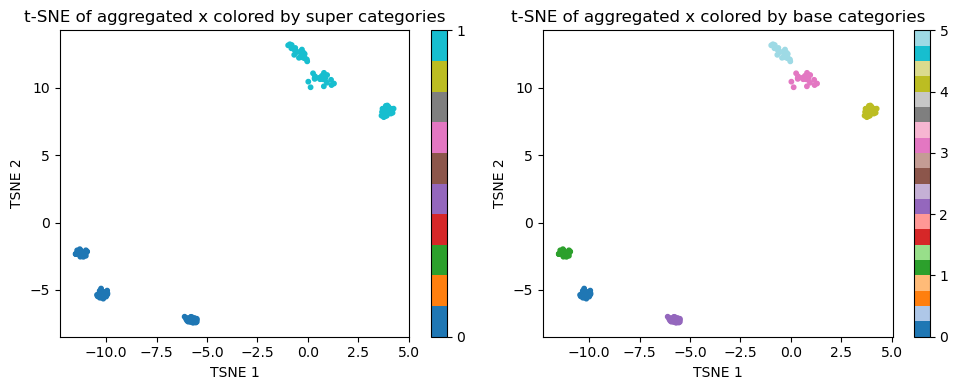

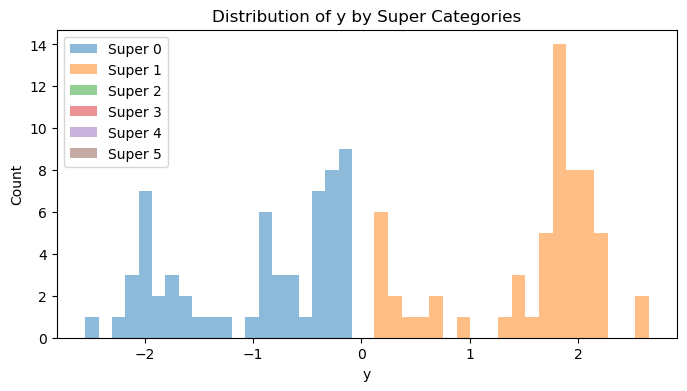

In [ ]:
# Run t-SNE
tsne = TSNE(n_components=2, random_state=0)
x_embedded = tsne.fit_transform(x_agg)

# Plot t-SNE colored by super categories
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.colorbar(scatter, ticks=range(6))
plt.title("t-SNE of aggregated x colored by super categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

# Plot t-SNE colored by base categories
plt.subplot(1, 2, 2)
scatter = plt.scatter(x_embedded[:, 0], x_embedded[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.colorbar(scatter, ticks=range(18))
plt.title("t-SNE of aggregated x colored by base categories")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")

plt.tight_layout()
plt.show()

# Plot distribution of y by super categories
plt.figure(figsize=(8, 4))
for super_id in range(6):
    y_vals = data["y"][data["super_labels"] == super_id]
    plt.hist(y_vals, bins=20, alpha=0.5, label=f"Super {super_id}")

plt.title("Distribution of y by Super Categories")
plt.xlabel("y")
plt.ylabel("Count")
plt.legend()
plt.show()


/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/home/leo/miniforge3/envs/hdp/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


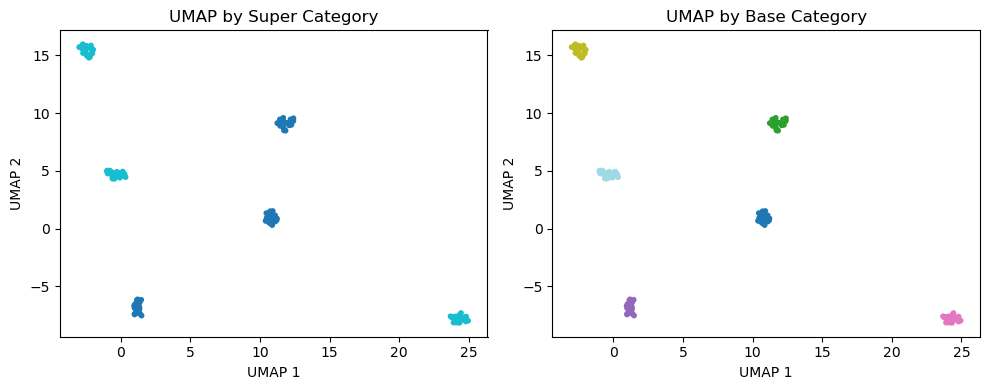

(2, 3, 10)


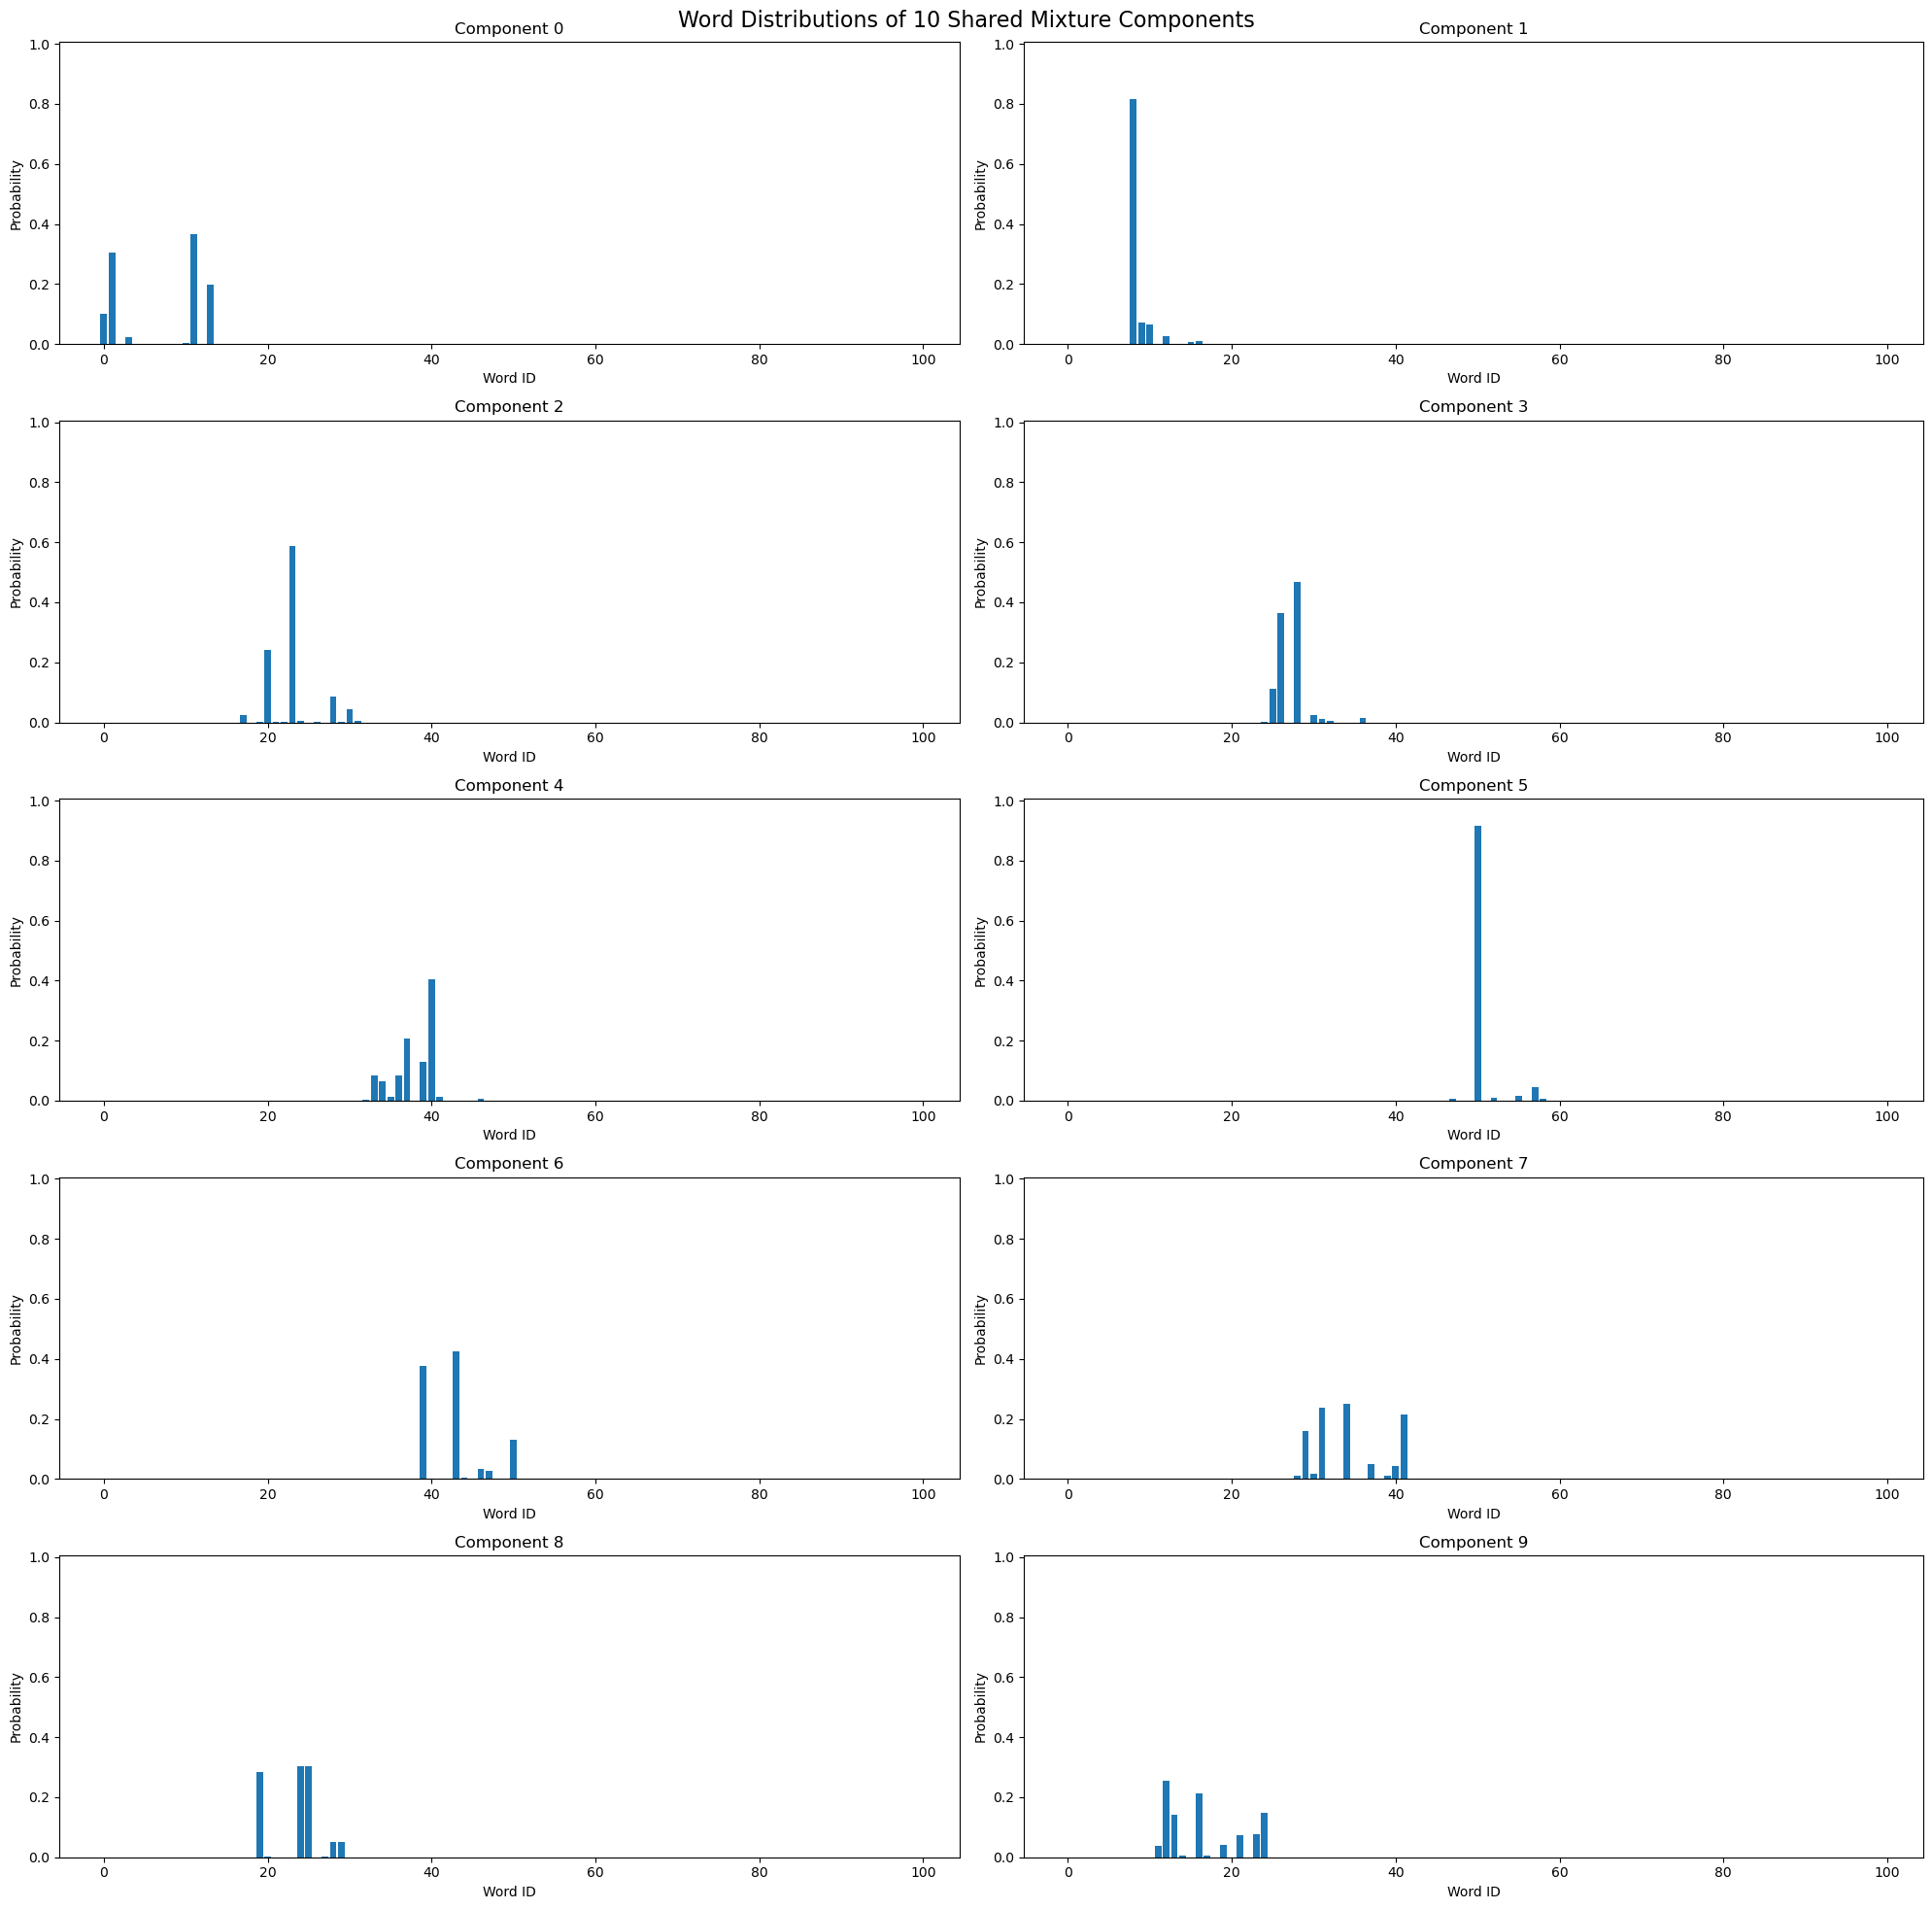

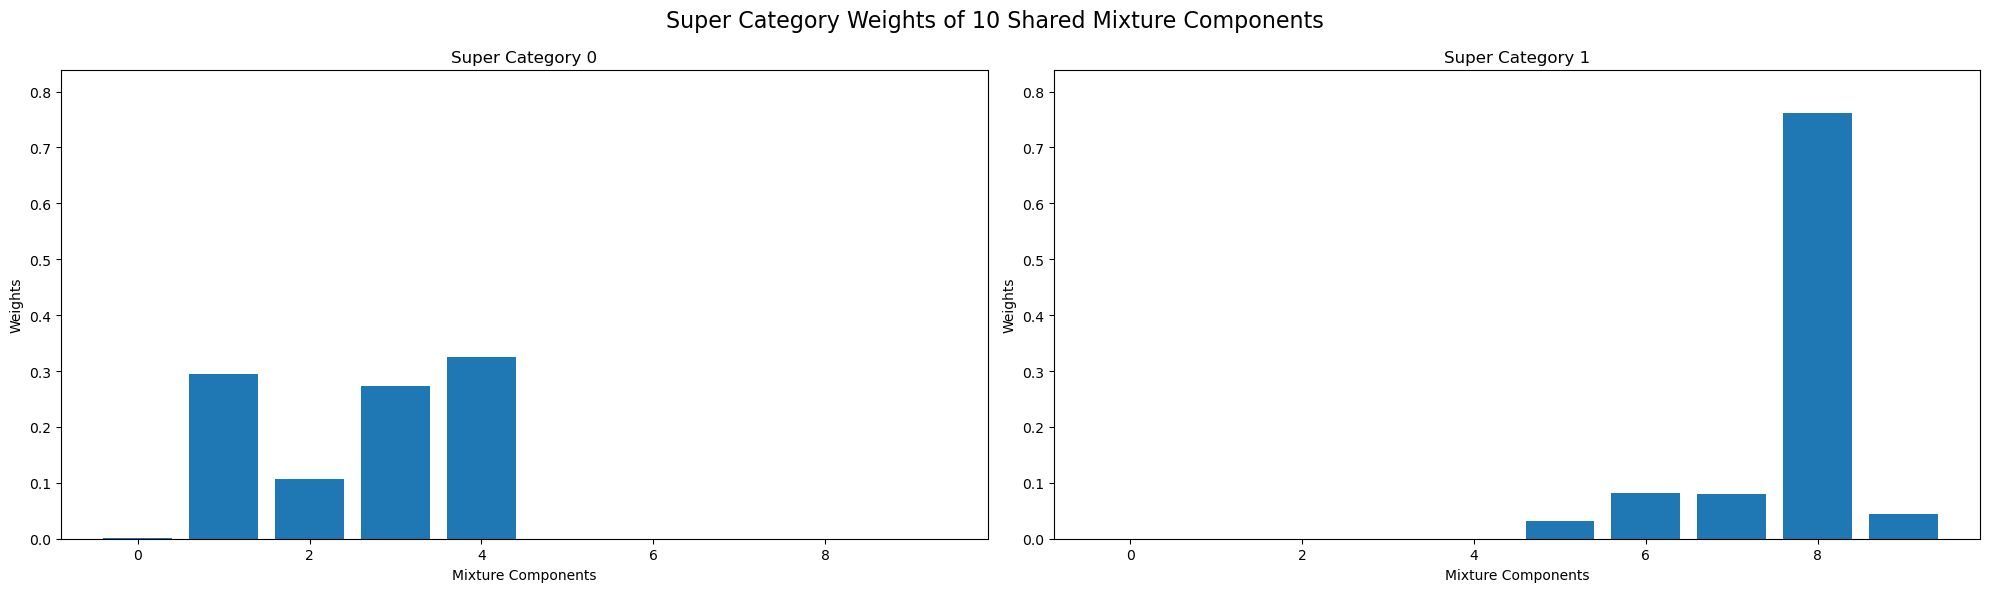

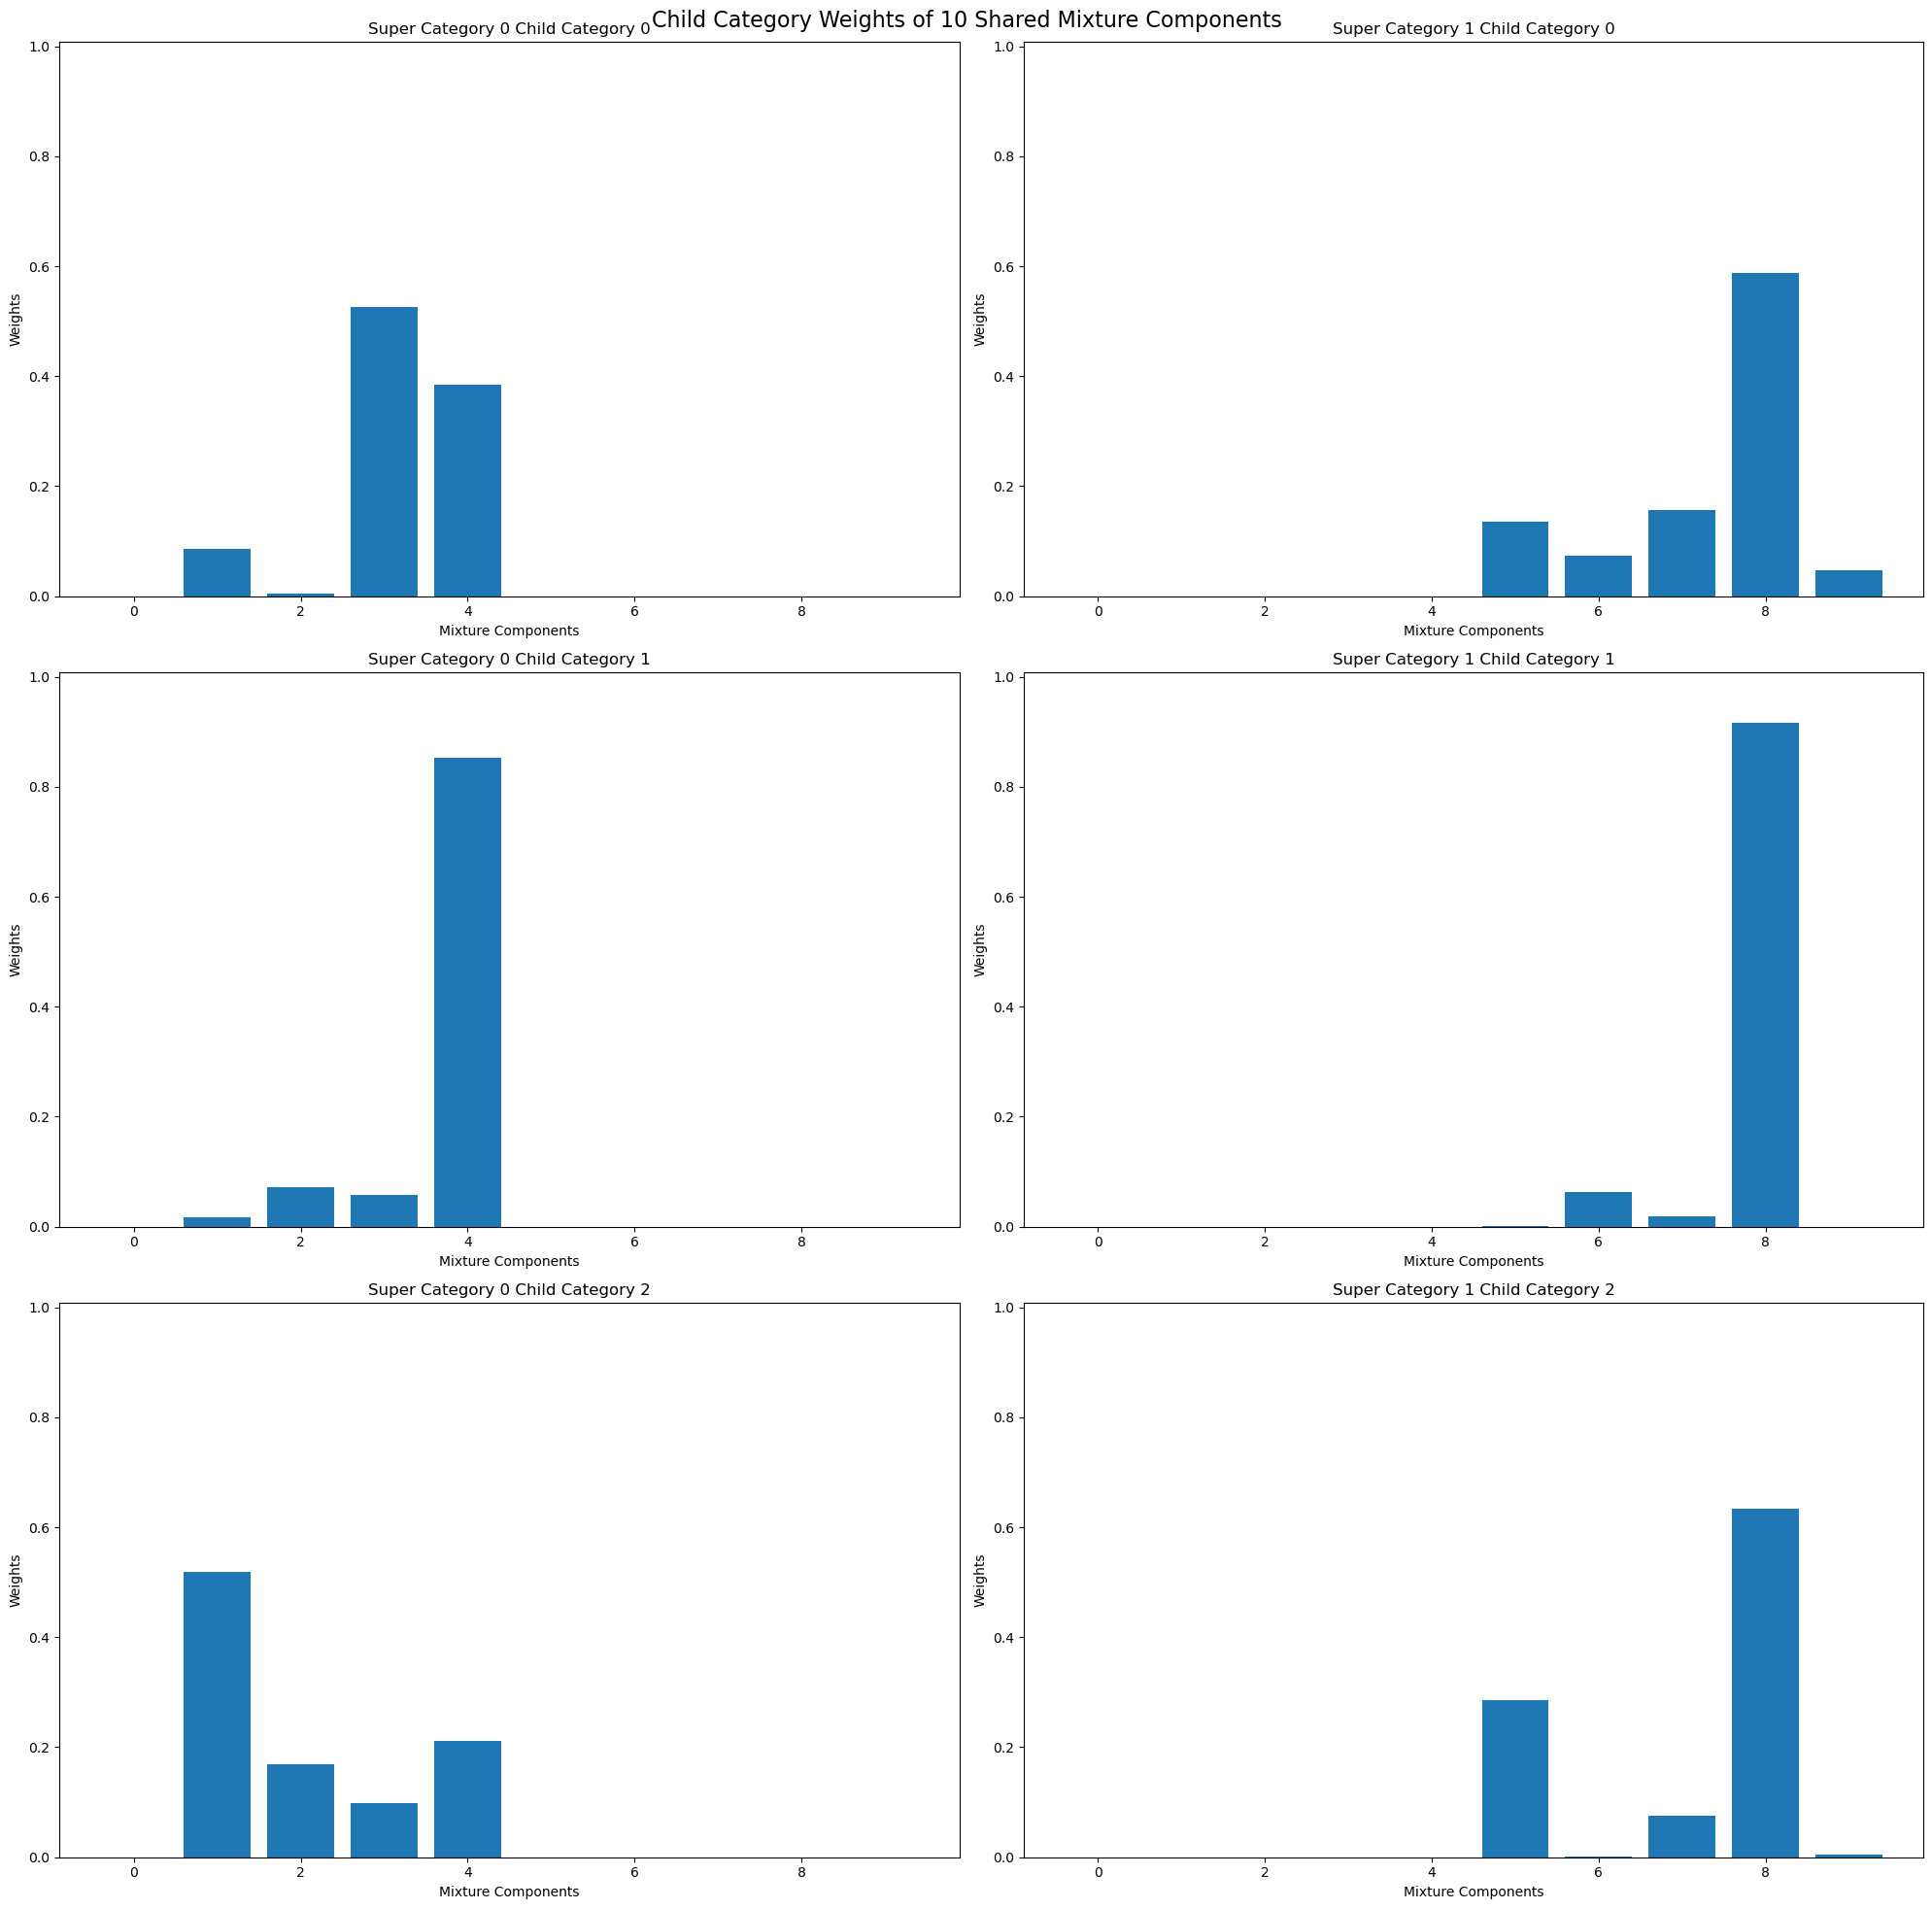

In [ ]:
# === UMAP projection ===
reducer = umap.UMAP(random_state=0)
x_umap = reducer.fit_transform(x_agg)


# === UMAP Plots ===
plt.figure(figsize=(10, 4))

# Super category coloring
plt.subplot(1, 2, 1)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["super_labels"], cmap="tab10", s=10)
plt.title("UMAP by Super Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Base category coloring
plt.subplot(1, 2, 2)
plt.scatter(x_umap[:, 0], x_umap[:, 1], c=data["base_labels"], cmap="tab20", s=10)
plt.title("UMAP by Base Category")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.tight_layout()
plt.show()

# === Mixture Component Word Distributions ===
num_components = 10
V = data["x"].shape[-1]
word_dists = data["word_dists"]
super_mix_weights = data["super_mix_weights"]
child_mix_weights = data["child_mix_weights"]
print(child_mix_weights.shape)

# Bar plots for each component
fig, axs = plt.subplots(5, 2, figsize=(20, 20))
for i in range(num_components):
    ax = axs[i // 2, i % 2]
    ax.bar(range(V), word_dists[i])
    ax.set_title(f"Component {i}")
    ax.set_xlabel("Word ID")
    ax.set_ylabel("Probability")
    ax.set_ylim(0, word_dists.max().item() * 1.1)

fig.suptitle("Word Distributions of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(1, 2, figsize=(20, 6))
for i in range(2):
    ax = axs[i]
    ax.bar(range(10), super_mix_weights[i])
    ax.set_title(f"Super Category {i}")
    ax.set_xlabel("Mixture Components")
    ax.set_ylabel("Weights")
    ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

fig.suptitle("Super Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()

# Bar plots for each component
fig, axs = plt.subplots(3, 2, figsize=(20, 20))
for i in range(3):
    for j in range(2):
        ax = axs[i, j]
        ax.bar(range(10), child_mix_weights[j][i])
        ax.set_title(f"Super Category {j} Child Category {i}")
        ax.set_xlabel("Mixture Components")
        ax.set_ylabel("Weights")
        ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

fig.suptitle("Child Category Weights of 10 Shared Mixture Components", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
@jax.jit
def mix_weights(beta):
    # Compute cumulative product of (1 - beta) along the last dimension
    beta1m_cumprod = jnp.cumprod(1.0 - beta, axis=-1)

    # Pad beta with a 1 at the end of the last dimension
    beta_padded = jnp.pad(beta, ((0, 0),) * (beta.ndim - 1) + ((0, 1),), constant_values=1.0)

    # Pad beta1m_cumprod with a 1 at the start of the last dimension
    beta1m_cumprod_padded = jnp.pad(beta1m_cumprod, ((0, 0),) * (beta.ndim - 1) + ((1, 0),), constant_values=1.0)

    # Element-wise multiplication
    weight = beta_padded * beta1m_cumprod_padded

    # Numerical stability (avoid zero weights)
    weight = jnp.maximum(weight, 1e-6)

    # Normalize across last dimension
    rlt = weight / jnp.sum(weight, axis=-1, keepdims=True)

    return rlt

In [ ]:
def model(data, struct_upbd, vocab_size, seed, gen_mixture=None, device=None):
    """
    Args:
      data: (feature, label), where
            feature: (N, M, vocab_size) one-hot words per position (or None for prior)
            label:   (N,) regression targets (or None for prior)
      struct_upbd: dict like {"G0": K0, "G1": K1, ...} (top level is G0)
      vocab_size: int
      device: unused (kept for API parity)
    """
    key = random.PRNGKey(seed)
    param_dims = list(struct_upbd.values())
    param_dims.reverse()
    cluster_dim = list(struct_upbd.values())[1:]

    feature = data[0]          # expected shape (N, M, vocab_size)
    N = feature.shape[0]
    M = feature.shape[1]
    label = data[1] 

    # ------------------------
    # Global/structural params
    # ------------------------
    struct_params = {}
    struct_params["gamma"]      = numpyro.param("model_gamma",      jnp.asarray([10.]), constraint=constraints.positive)
    struct_params["dir_alpha"]  = numpyro.param("model_dir_alpha",  jnp.asarray([1./vocab_size]), constraint=constraints.positive)
    struct_params["nig_mu"]     = numpyro.param("model_nig_mu",     jnp.asarray([0.0]))
    struct_params["nig_kappa"]  = numpyro.param("model_nig_kappa",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_alpha"]  = numpyro.param("model_nig_alpha",  jnp.asarray([1.0]), constraint=constraints.positive)
    struct_params["nig_beta"]   = numpyro.param("model_nig_beta",   jnp.asarray([1.0]), constraint=constraints.positive)

    # alpha/eta tensors across hierarchy
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  

        base = numpyro.param(
            f"model_alpha{parent_level}",
            10*jnp.ones(tuple(param_dims[-child_level:-1])),
            constraint=constraints.positive,
        )
        struct_params[f"alpha{parent_level}"] = jnp.expand_dims(base, -1) * jnp.ones(tuple(param_dims[-child_level:]))
        assert struct_params[f"alpha{parent_level}"].shape == tuple(param_dims[-child_level:])

        struct_params[f"eta{parent_level}"] = numpyro.param(
            f"model_eta{parent_level}",
            10*jnp.ones(tuple(param_dims[-child_level:-1])),
            constraint=constraints.positive,
        )

    # Last level alpha (no eta)
    last_idx = len(struct_upbd) - 1
    base_last = numpyro.param(
        f"model_alpha{last_idx}",
        10*jnp.ones(tuple(param_dims[:-1])),
        constraint=constraints.positive,
    )
    struct_params[f"alpha{last_idx}"] = jnp.expand_dims(base_last, -1) * jnp.ones(tuple(param_dims))
    assert struct_params[f"alpha{last_idx}"].shape == tuple(param_dims)

    # ---------------
    # Stick-breaking
    # ---------------
    struct_values = {}

    # Top-level Beta sticks B0 -> G0 weights
    K0 = param_dims[-1]
    B0_a = jnp.ones((K0,))  # shape (K0,)
    B0_b = jnp.broadcast_to(struct_params["gamma"], (K0,))
    key, sub = random.split(key)
    beta_0 = dist.Beta(B0_a, B0_b).sample(sub)
    struct_values["P0"] = [B0_a, B0_b]
    struct_values["B0"] = beta_0
    struct_values["G0"] = mix_weights(beta_0)[..., :-1]  # (K0,)
    assert struct_values["G0"].shape == (K0,)

    # Lower levels
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1  # number of dims for this plate

        # shapes like in your code:
        # alpha * G_parent and alpha * (1 - cumsum(G_parent))
        G_parent = struct_values[f"G{parent_level}"]  # shape param_dims[-(parent_level+1):]
        alpha_param = struct_params[f"alpha{parent_level}"]  # shape param_dims[-child_level:]
        param_alpha = alpha_param * G_parent
        param_beta = alpha_param * (1.0 - jnp.cumsum(G_parent, axis=-1))

        shape_needed = tuple(param_dims[-full_dim:])
        a = jnp.broadcast_to(jnp.expand_dims(param_alpha, 0), shape_needed)
        b = jnp.broadcast_to(jnp.expand_dims(param_beta, 0), shape_needed)

        key, sub = random.split(key)
        beta = dist.Beta(a, b).sample(sub)
        struct_values[f"P{child_level}"] = [a, b]
        struct_values[f"B{child_level}"] = beta
        struct_values[f"G{child_level}"] = mix_weights(beta)[..., :-1]
        assert struct_values[f"G{child_level}"].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][0].shape == tuple(param_dims[-full_dim:])
        assert struct_values[f"P{child_level}"][1].shape == tuple(param_dims[-full_dim:])

    # ---------------
    # Cluster weights
    # ---------------
    for parent_level in range(len(struct_upbd) - 1):
        child_level = parent_level + 1
        full_dim = child_level + 1
        eta = struct_params[f"eta{parent_level}"]  # shape param_dims[-full_dim:-1]

        key, sub = random.split(key)
        beta = dist.Beta(jnp.ones_like(eta), eta).sample(sub, sample_shape=(struct_upbd[f"G{child_level}"],))
        beta = jnp.moveaxis(beta, 0, -1)
        assert beta.shape == tuple(cluster_dim[:child_level])
        struct_values[f"L{parent_level}"] = mix_weights(beta)[..., :-1] # categorical probs over next level
        assert struct_values[f"L{parent_level}"].shape == tuple(cluster_dim[:child_level])

    # -----------------------
    # Mixture components
    # -----------------------
    # Topics over vocab
    G0_size = struct_upbd["G0"]
    mixture_components = {}
    if gen_mixture is not None:
        assert gen_mixture.shape == (G0_size, vocab_size)
        mixture_components["generation"] = gen_mixture
    else:
        key, sub = random.split(key)
        mixture_components["generation"] = dist.Dirichlet(
                struct_params["dir_alpha"]
                * jnp.ones((vocab_size))
            ).sample(sub, sample_shape=(G0_size,))
        assert mixture_components["generation"].shape == (G0_size, vocab_size)
    # Regression components via NIG prior
    key, sub = random.split(key)
    sigma = dist.InverseGamma(
            jnp.broadcast_to(struct_params["nig_alpha"], (G0_size,)),
            jnp.broadcast_to(struct_params["nig_beta"],  (G0_size,))
        ).sample(sub)
    assert sigma.shape == (G0_size,)
    key, sub = random.split(key)
    mu = dist.Normal(
            jnp.broadcast_to(struct_params["nig_mu"], (G0_size,)),
            jnp.sqrt(sigma / jnp.broadcast_to(struct_params["nig_kappa"], (G0_size,)))
        ).sample(sub)
    assert mu.shape == (G0_size,)
    mixture_components["regression_sigma"] = sigma
    mixture_components["regression_mu"] = mu

    # ---------------------------------
    # Per-document hierarchical routing
    # ---------------------------------
    assigned_zs = [jnp.zeros((N,), dtype=jnp.int32)]  # seed like your torch.zeros long
    doc_values = {}

    # Walk down the cluster tree
    for level in range(len(struct_upbd) - 1):
        # cluster_weights[L{level}] has dims over the parent categories, last dim = choices at this level
        W = struct_values[f"L{level}"][None, ...]  # shape e.g. (..., K_level)
        # Build advanced indexing tuple from already-sampled parent zs
        # assigned_zs holds arrays of shape (N,), one per parent axis.
        index_tuple = tuple(assigned_zs[:])
        # param -> (N, K_level)
        param = W[index_tuple]
        assert param.shape == (N, struct_values[f"L{level}"].shape[-1])
        key, sub = random.split(key)
        z = dist.Categorical(probs=param).sample(sub)
        assigned_zs.append(z)

    # reverse to align with your later indexing usage
    assigned_zs = assigned_zs[::-1]


    # Document-level stick-breaking at bottom: construct Beta params using G_{L} and alpha_{L}
    bottom_G = struct_values[f"G{len(struct_upbd)-1}"][None, ...]  # shape (K0,) broadcastable with per-doc gather
    bottom_alpha = struct_params[f"alpha{len(struct_upbd)-1}"][None, ...]

    # Gather per-doc parent path for alpha and weights_prior
    # For G_{L} (topic base weights), use parent indices in assigned_zs[:-1]
    idx_tuple_weights = tuple(assigned_zs[:-1])
    batch_idx = jnp.arange(N)
    indices = (batch_idx, *idx_tuple_weights)  

    weights_prior = bottom_G[indices + (slice(None),)]  # (N, G0)
    assert weights_prior.shape == (N, G0_size)
    concentrate = bottom_alpha[indices + (slice(None),)]  # (N, G0)
    assert concentrate.shape == (N, G0_size)

    param_alpha = concentrate * weights_prior
    param_beta = concentrate * (1.0 - jnp.cumsum(weights_prior, axis=-1))

    key, sub = random.split(key)
    beta_doc = dist.Beta(param_alpha, param_beta).sample(sub)  # (N, G0)
    doc_values["P"] = [param_alpha, param_beta]
    doc_values["B"]  = beta_doc

    topic_dist = mix_weights(beta_doc)[..., :-1]   # (N, G0)
    doc_values["G"] = topic_dist
    assert topic_dist.shape == (N, G0_size)

    # ----- Words -----
    # Per-token topic → per-token word dist, then one-hot word obs via Multinomial(1, .)
    topic_over_docs = jnp.broadcast_to(jnp.expand_dims(topic_dist, axis=1), (N, M, G0_size))
    key, sub = random.split(key)
    z_gen = dist.Categorical(probs=topic_over_docs).sample(sub)  # (N, M)
    obs = feature

    # ----- Regression -----
    key, sub = random.split(key)
    z_reg = dist.Categorical(probs=topic_dist).sample(sub)  
    reg = label

    # Recreate category_assignments like your torch.stack(cat_zs, dim=1)
    cat_zs = assigned_zs[:-1][::-1]  # drop the seed, reverse to original order
    category_assignments = jnp.stack(cat_zs, axis=1) if len(cat_zs) > 0 else jnp.zeros((N, 0), dtype=jnp.int32)

    return {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": mixture_components,
        "category_assignments": category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }


In [ ]:
@jax.jit
def suffix_sum(x: jnp.ndarray) -> jnp.ndarray:
    """
    Compute suffix sums along the last dimension of a tensor.
    Each entry is the sum of all elements to its right.
    The last element along that dimension is always 0.
    
    Example:
        x = jnp.array([1,2,3])
        suffix_sum(x) -> [5,3,0]
        
        x = jnp.array([[1,2,3],[4,5,6]])
        suffix_sum(x) -> [[5,3,0],
                           [11,6,0]]
    """
    # Flip along the last dimension
    rev = jnp.flip(x, axis=-1)
    # Cumulative sum on the flipped tensor
    rev_cumsum = jnp.cumsum(rev, axis=-1)
    # Flip back
    suffix = jnp.flip(rev_cumsum, axis=-1)
    # Subtract original to exclude current element
    suffix = suffix - x
    return suffix

In [ ]:
@jax.jit
def word_category_conditional(key, word, weight, components):
    gen_dist = dist.Multinomial(total_count=1, probs=components)
    log_probs = gen_dist.log_prob(word)
    un_normalized = log_probs + jnp.log(weight + 1e-12)
    cat_prob = jax.nn.softmax(un_normalized, axis=-1)

    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key


In [ ]:
@jax.jit
def reg_category_conditional(key, score, weight, components):
    reg_dist = dist.Normal(loc=components[0], scale=jnp.sqrt(components[1]))
    log_probs = reg_dist.log_prob(score)
    un_normalized = log_probs + jnp.log(weight + 1e-12)

    cat_prob = jax.nn.softmax(un_normalized, axis=-1)
    key, sub = random.split(key)
    sample = dist.Categorical(probs=cat_prob).sample(sub)
    return sample, key

In [ ]:
@jax.jit
def doc_categories_conditional(key, nu_doc, nu1, nu2, params1, params2, doc_prior, doc_concentrate, cluster_prob0, cluster_prob1, S, C):
    K = 10
    nu_doc = nu_doc[None, None, :]  # (1, 1, K)
    nu_1_log_prob = dist.Beta(params1[0], params1[1]).log_prob(nu1)
    nu_1_log_prob = jnp.sum(nu_1_log_prob, axis=-1)  # (S,)
    nu_1_log_prob = nu_1_log_prob[None, :] # (1, S)
    
    nu_2_log_prob = dist.Beta(params2[0], params2[1]).log_prob(nu2)
    nu_2_log_prob = jnp.sum(nu_2_log_prob, axis=-1)  # (C, S)

    param_alpha = doc_concentrate * doc_prior
    param_beta = doc_concentrate * (1.0 - jnp.cumsum(doc_prior, axis=-1))

    mu_doc_log_prob = dist.Beta(param_alpha, param_beta).log_prob(nu_doc)
    mu_doc_log_prob = jnp.sum(mu_doc_log_prob, axis=-1)  # (C, S)

    level1_prob =  jnp.log(cluster_prob0[None, :])  # (1, S)
    level2_prob =  jnp.log(jnp.transpose(cluster_prob1))  # (C, S)

    un_normalized = nu_1_log_prob + nu_2_log_prob + mu_doc_log_prob + level1_prob + level2_prob  # (C, S)
    prob = jax.nn.softmax(un_normalized.reshape(-1))

    key, sub = random.split(key)
    sample = dist.Categorical(probs=prob).sample(sub)
    new_cat0 = sample // C
    new_cat1 = sample % C
    new_cat = jnp.array([new_cat0, new_cat1])
    return new_cat, key

In [ ]:
@jax.jit
def doc_weight_conditional(key, nu_doc, params, word_cats, reg_cats):
    K = 10
    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu_doc, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]
    return new_params, key


In [ ]:
@jax.jit
def cat_weight_conditional(key, nu, params, word_cats, reg_cats):
    K = 10

    cat_count = jnp.bincount(word_cats.ravel(), length=K)
    cat_idx = jnp.arange(K)
    reg_count = jnp.bincount(reg_cats.ravel(), length=K)
    cat_count = cat_count + reg_count

    alpha_bias = jnp.zeros_like(nu, dtype=jnp.int32).at[cat_idx].set(cat_count)
    beta_bias = suffix_sum(alpha_bias)

    new_params = [params[0] + alpha_bias, params[1] + beta_bias]

    assert new_params[0].shape == (K,)
    assert new_params[1].shape == (K,)
    return new_params, key

In [ ]:
@jax.jit
def reg_component_conditional(key, obs, params):
    count = float(obs.size)
    mean = jnp.mean(obs)
    sum_var = jnp.sum((obs - mean) ** 2, keepdims=True)
    kappa = params[1] + count
    mu = (params[1] * params[0] + count * mean) / kappa
    alpha = params[2] + count / 2
    beta = params[3] + 0.5 * sum_var + (params[1] * count * (mean - params[0]) ** 2) / (2 * kappa)

    key, sub = random.split(key)
    new_sigma = dist.InverseGamma(alpha, beta).sample(sub)
    key, sub = random.split(key)
    new_mu = dist.Normal(mu, jnp.sqrt(new_sigma / kappa)).sample(sub)
    return [jnp.squeeze(new_mu), jnp.squeeze(new_sigma)], key

In [ ]:
@jax.jit
def gen_component_conditional(key, obs, params):
    value = jnp.sum(obs, axis=0)

    new_params = params + value

    key, sub = random.split(key)
    sample = dist.Dirichlet(new_params).sample(sub)
    return sample, key

In [ ]:
def gibbs_sampler(key, state, struct_upbd, vocab_size, num_iters, markov_chain=None, gen_ground_truth=False):
    """
    Gibbs sampler for HDMM with proper JAX key handling.
    """
    # Unpack state
    K = int(struct_upbd["G0"])
    S = int(struct_upbd["G1"])
    C = int(struct_upbd["G2"])
    struct_params = state["struct_params"]
    struct_values = state["struct_values"]
    generation_components = state["mixture_components"]["generation"]
    regression_mu = state["mixture_components"]["regression_mu"]
    regression_sigma = state["mixture_components"]["regression_sigma"]
    category_assignments = state["category_assignments"]
    doc_values = state["doc_values"]
    words = state["words"]
    z_gen = words["z_gen"]
    z_reg = words["z_reg"]
    obs = words["obs"]
    reg = words["reg"]
    if (markov_chain is None):
        markov_chain = {}
        markov_chain["generation_components"] = []
        markov_chain["regression_mu"] = []
        markov_chain["regression_sigma"] = []
        markov_chain["G1"] = []
        markov_chain["G2"] = []
        markov_chain["B1"] = []
        markov_chain["B2"] = []

    param_dims = list(struct_upbd.values())
    param_dims.reverse()

    N, M, _ = obs.shape
    key, sub = random.split(key)

    for it in trange(num_iters+1, desc="Gibbs Sampling"):
        # ------------------------
        # Sample structural weights
        # ------------------------
        # Top-level
        key, sub = random.split(key)
        new_params, key = cat_weight_conditional(sub, struct_values["B0"], struct_values["P0"], z_gen, z_reg)
        struct_values["P0"] = [new_params[0], new_params[1]]
        key, sub = random.split(key)
        struct_values["B0"] = dist.Beta(struct_values["P0"][0], struct_values["P0"][1]).sample(sub)
        struct_values["G0"] = mix_weights(struct_values["B0"])[..., :-1]

        for s in range(S):
            row_idx = jnp.where(category_assignments[:, 0] == s)[0]
            key, sub = random.split(key)
            new_params, key = cat_weight_conditional(sub, struct_values["B1"][s], [struct_values["P1"][0][s], struct_values["P1"][1][s]], z_gen[row_idx], z_reg[row_idx])
            struct_values["P1"][0] = struct_values["P1"][0].at[s].set(new_params[0])
            struct_values["P1"][1] = struct_values["P1"][1].at[s].set(new_params[1])
            key, sub = random.split(key)
            struct_values["B1"] = struct_values["B1"].at[s].set(dist.Beta(struct_values["P1"][0][s], struct_values["P1"][1][s]).sample(sub))
            struct_values["G1"] = struct_values["G1"].at[s].set(mix_weights(struct_values["B1"][s])[..., :-1])

            for c in range(struct_upbd["G2"]):
                mask = (category_assignments[:, 1] == c) & (category_assignments[:, 0] == s)
                row_idx = jnp.where(mask)[0]
                key, sub = random.split(key)
                new_params, key = cat_weight_conditional(sub, struct_values["B2"][c, s], [struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]], z_gen[row_idx], z_reg[row_idx])
                struct_values["P2"][0] = struct_values["P2"][0].at[(c, s)].set(new_params[0])
                struct_values["P2"][1] = struct_values["P2"][1].at[(c, s)].set(new_params[1])
                key, sub = random.split(key)
                struct_values["B2"] = struct_values["B2"].at[(c, s)].set(dist.Beta(struct_values["P2"][0][c, s], struct_values["P2"][1][c, s]).sample(sub))
                struct_values["G2"] = struct_values["G2"].at[(c, s)].set(mix_weights(struct_values["B2"][c, s])[..., :-1])

        # ------------------------
        # Sample generation components
        # ------------------------
        if (not gen_ground_truth):
            for k in range(K):
                word_idx = jnp.where(z_gen == k)
                if word_idx[0].size > 0:
                    key, sub = random.split(key)
                    obs_k = obs[word_idx]
                    generation_components_k, key = gen_component_conditional(sub, obs_k, struct_params["dir_alpha"] * jnp.ones((vocab_size,)))
                    generation_components = generation_components.at[k].set(generation_components_k)

        # ------------------------
        # Sample regression components
        # ------------------------
        for k in range(K):
            reg_idx = jnp.where(z_reg == k)
            if reg_idx[0].size > 0:
                key, sub = random.split(key)
                reg_k = reg[reg_idx]
                (new_mu, new_sigma), key = reg_component_conditional(
                    sub, reg_k, (
                        struct_params["nig_mu"],
                        struct_params["nig_kappa"],
                        struct_params["nig_alpha"],
                        struct_params["nig_beta"]
                    )
                )
                regression_mu = regression_mu.at[k].set(new_mu)
                regression_sigma = regression_sigma.at[k].set(new_sigma)

        # ------------------------
        # Sample document category assignments
        # ------------------------
        for n in range(N):
            key, sub = random.split(key)
            new_cat, key = doc_categories_conditional(
                sub,
                doc_values["G"][n],
                struct_values["B1"],
                struct_values["B2"],
                struct_values["P1"],
                struct_values["P2"],
                struct_values["G2"],
                struct_params["alpha2"],
                struct_values["L0"],
                struct_values["L1"],
                S,
                C
            )

            category_assignments = category_assignments.at[n].set(new_cat)

            # Sample doc-level weights
            key, sub = random.split(key)
            new_params, key = doc_weight_conditional(
                sub,
                doc_values["B"][n],
                [struct_values[f"P{len(struct_upbd)-1}"][0][category_assignments[n][1], category_assignments[n][0]],
                 struct_values[f"P{len(struct_upbd)-1}"][1][category_assignments[n][1], category_assignments[n][0]]],
                z_gen[n], 
                z_reg[n]
            )
            doc_values["P"][0] = doc_values["P"][0].at[n].set(new_params[0])
            doc_values["P"][1] = doc_values["P"][1].at[n].set(new_params[1])

            key, sub = random.split(key)
            doc_values["B"] = doc_values["B"].at[n].set(dist.Beta(doc_values["P"][0][n], doc_values["P"][1][n]).sample(sub))
            assert doc_values["B"].shape == (N, K)
            doc_values["G"] = doc_values["G"].at[n].set(mix_weights(doc_values["B"][n])[:-1])

            # Sample word-level categories
            for m in range(M):
                key, sub = random.split(key)
                sample, key = word_category_conditional(sub, obs[n, m], doc_values["G"][n], generation_components)
                z_gen = z_gen.at[n, m].set(sample)

            # Sample regression category
            key, sub = random.split(key)
            sample, key = reg_category_conditional(sub, reg[n], doc_values["G"][n], (regression_mu, regression_sigma))
            z_reg = z_reg.at[n].set(sample)
        
        if (it % 50 == 0):
            markov_chain["generation_components"].append(generation_components)
            markov_chain["regression_mu"].append(regression_mu)
            markov_chain["regression_sigma"].append(regression_sigma)
            markov_chain["G1"].append(struct_values["G1"])
            markov_chain["G2"].append(struct_values["G2"])
            markov_chain["B1"].append(struct_values["B1"])
            markov_chain["B2"].append(struct_values["B2"])

            if (len(markov_chain["generation_components"]) > 10):
                markov_chain["generation_components"].pop(0)
                markov_chain["regression_mu"].pop(0)
                markov_chain["regression_sigma"].pop(0)
                markov_chain["G1"].pop(0)
                markov_chain["G2"].pop(0)
                markov_chain["B1"].pop(0)
                markov_chain["B2"].pop(0)

            word_dists = jnp.mean(jnp.stack(markov_chain["generation_components"]), axis=0)
            # Bar plots for each component
            fig, axs = plt.subplots(5, 2, figsize=(20, 20))
            for i in range(struct_upbd["G0"]):
                ax = axs[i // 2, i % 2]
                ax.bar(range(vocab_size), word_dists[i])
                ax.set_title(f"Component {i}")
                ax.set_xlabel("Word ID")
                ax.set_ylabel("Probability")
                ax.set_ylim(0, word_dists.max().item() * 1.1)

            fig.suptitle(f"Word Distributions of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()

            super_mix_weights = jnp.mean(jnp.stack(markov_chain["G1"]), axis=0)
            # Bar plots for each component
            fig, axs = plt.subplots(1, 2, figsize=(20, 6))
            for i in range(S):
                ax = axs[i]
                ax.bar(range(K), super_mix_weights[i])
                ax.set_title(f"Super Category {i}")
                ax.set_xlabel("Mixture Components")
                ax.set_ylabel("Weights")
                ax.set_ylim(0, super_mix_weights.max().item() * 1.1)

            fig.suptitle(f"Super Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()

            child_mix_weights = jnp.mean(jnp.stack(markov_chain["G2"]), axis=0)
            # Bar plots for each component
            fig, axs = plt.subplots(3, 2, figsize=(20, 20))
            for i in range(struct_upbd["G2"]):
                for j in range(S):
                    ax = axs[i, j]
                    ax.bar(range(K), child_mix_weights[i][j])
                    ax.set_title(f"Super Category {j} Child Category {i}")
                    ax.set_xlabel("Mixture Components")
                    ax.set_ylabel("Weights")
                    ax.set_ylim(0, child_mix_weights.max().item() * 1.1)

            fig.suptitle(f"Child Category Weights of 10 Shared Mixture Components of iteration {it}", fontsize=16)
            plt.tight_layout()
            plt.show()
            
    post_state = {
        "struct_params": struct_params,
        "struct_values": struct_values,
        "mixture_components": {
            "generation": generation_components,
            "regression_mu": regression_mu,
            "regression_sigma": regression_sigma,
        },
        "category_assignments": category_assignments,
        "doc_values": doc_values,
        "words": {
            "z_gen": z_gen,
            "z_reg": z_reg,
            "obs": obs,
            "reg": reg,
        },
    }
    return post_state, markov_chain

Gibbs Sampling:   0%|          | 0/500 [00:00<?, ?it/s]

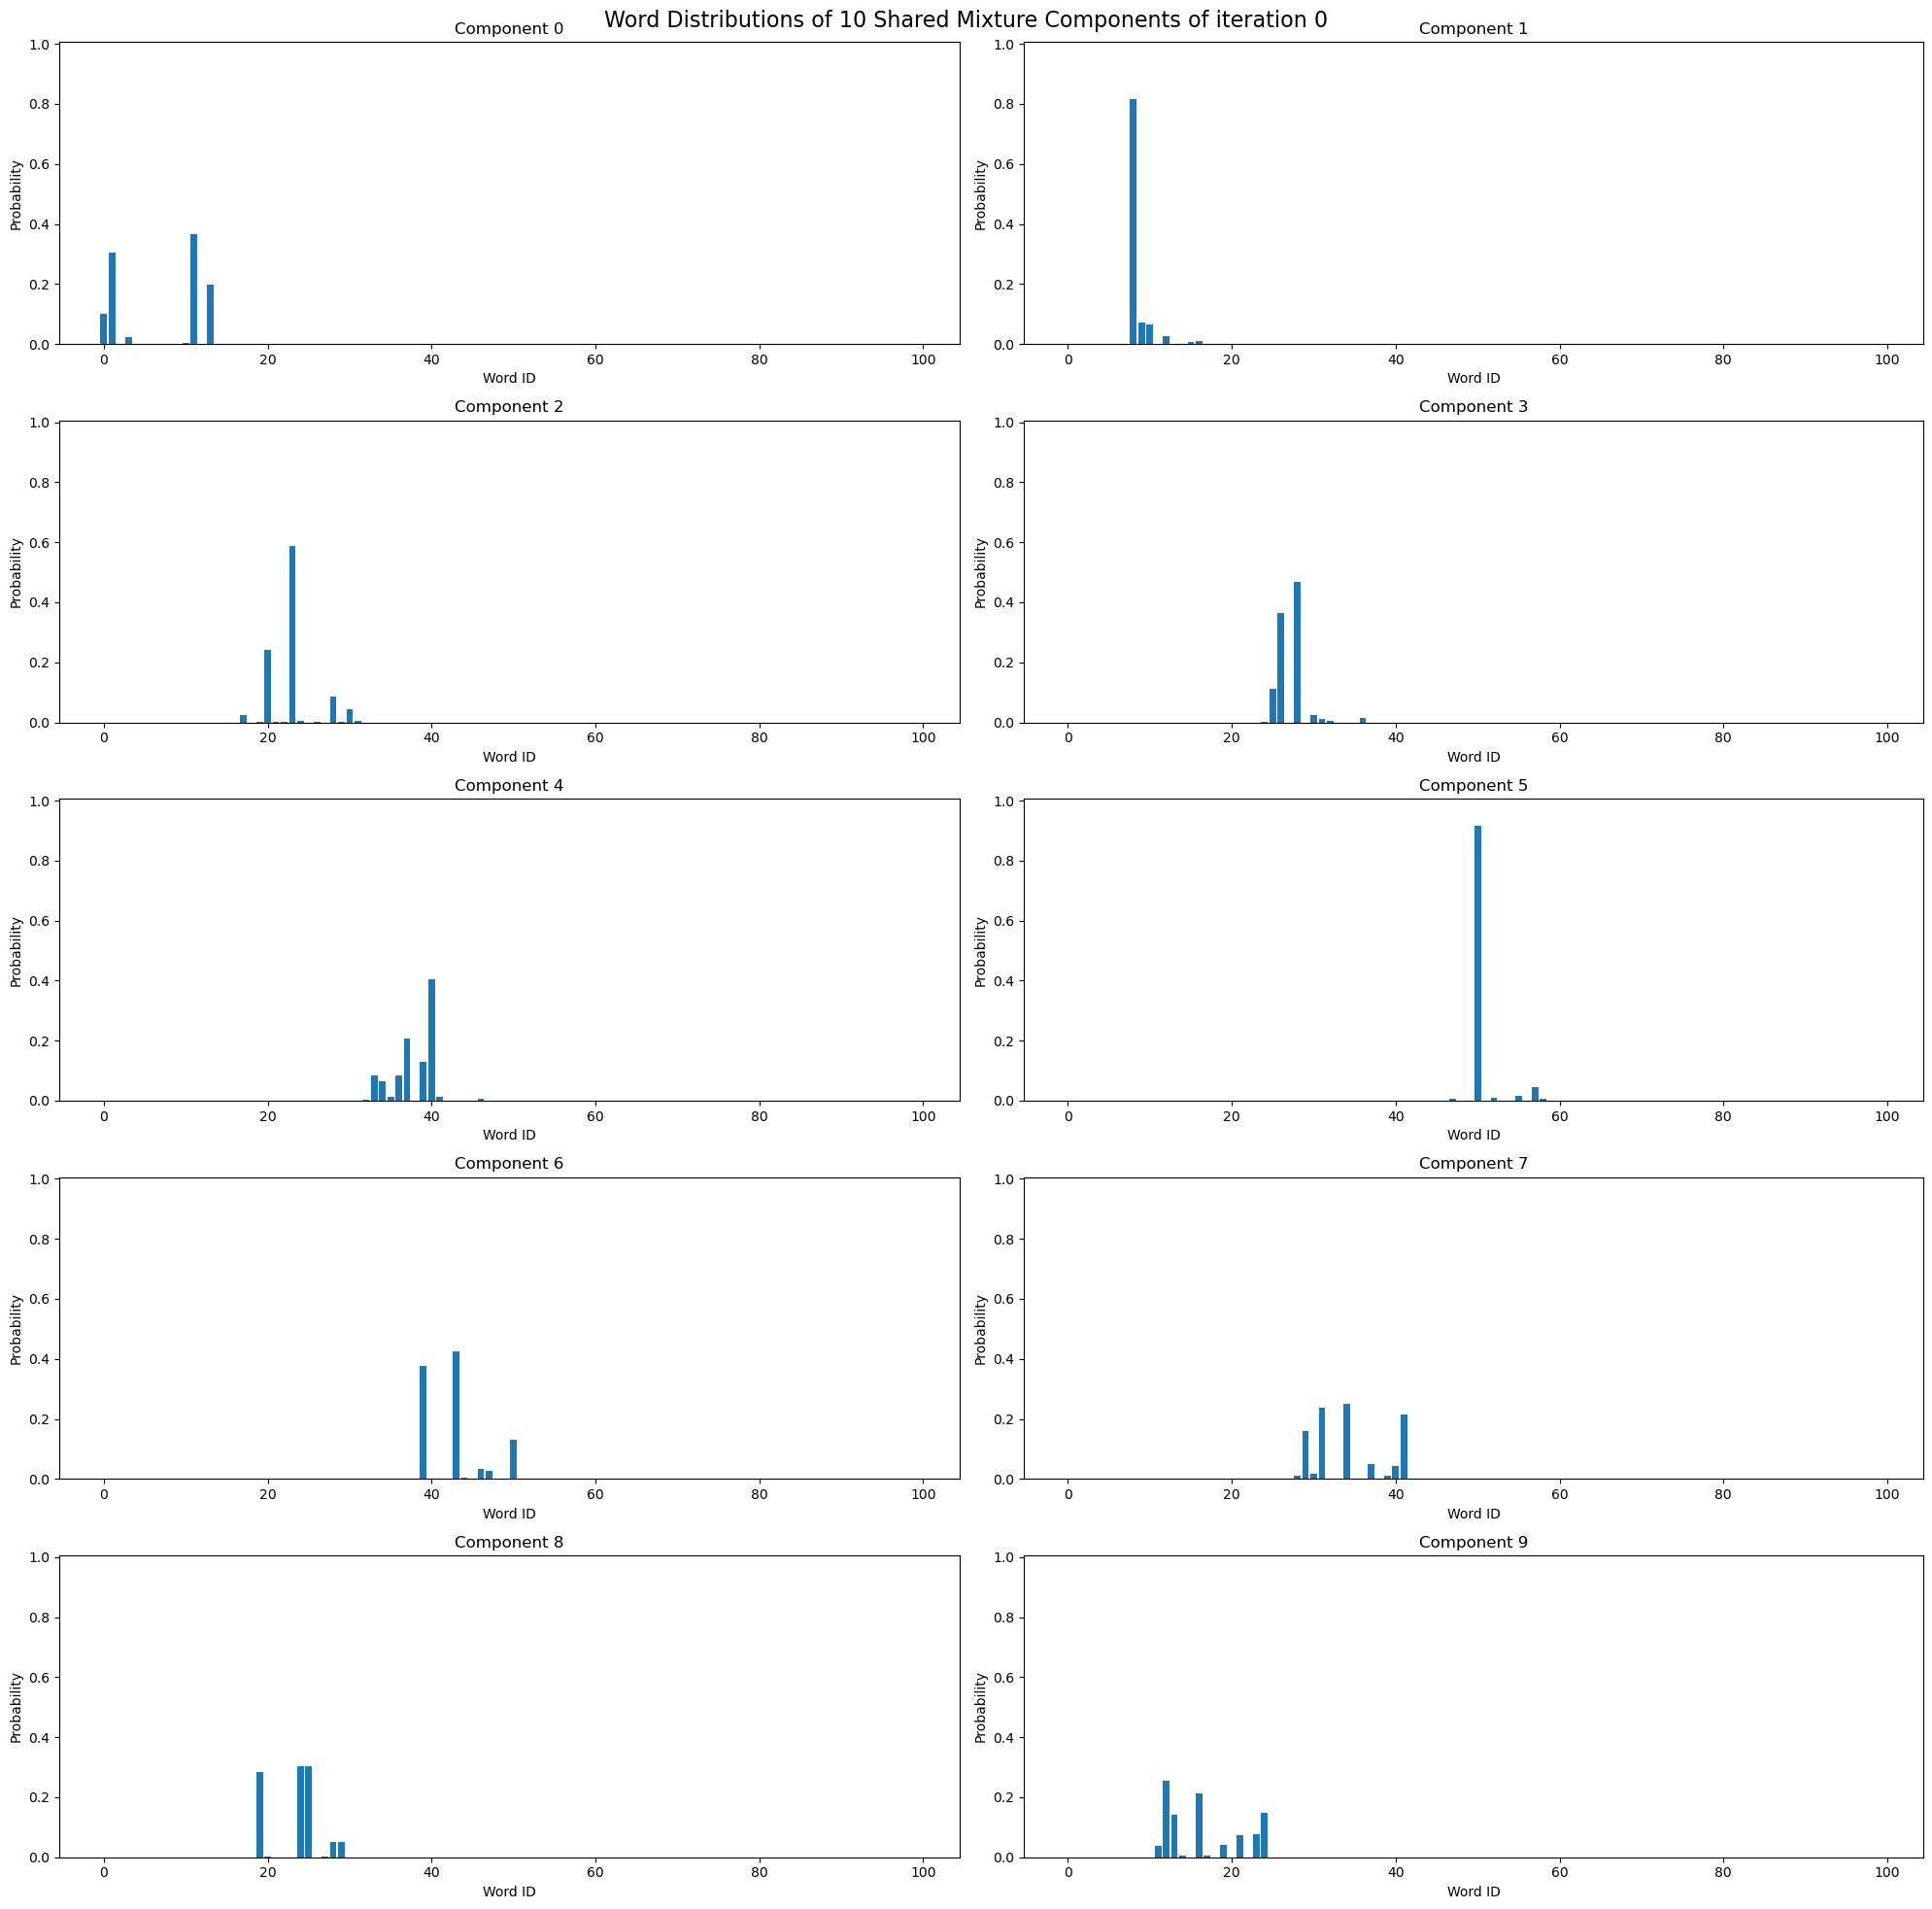

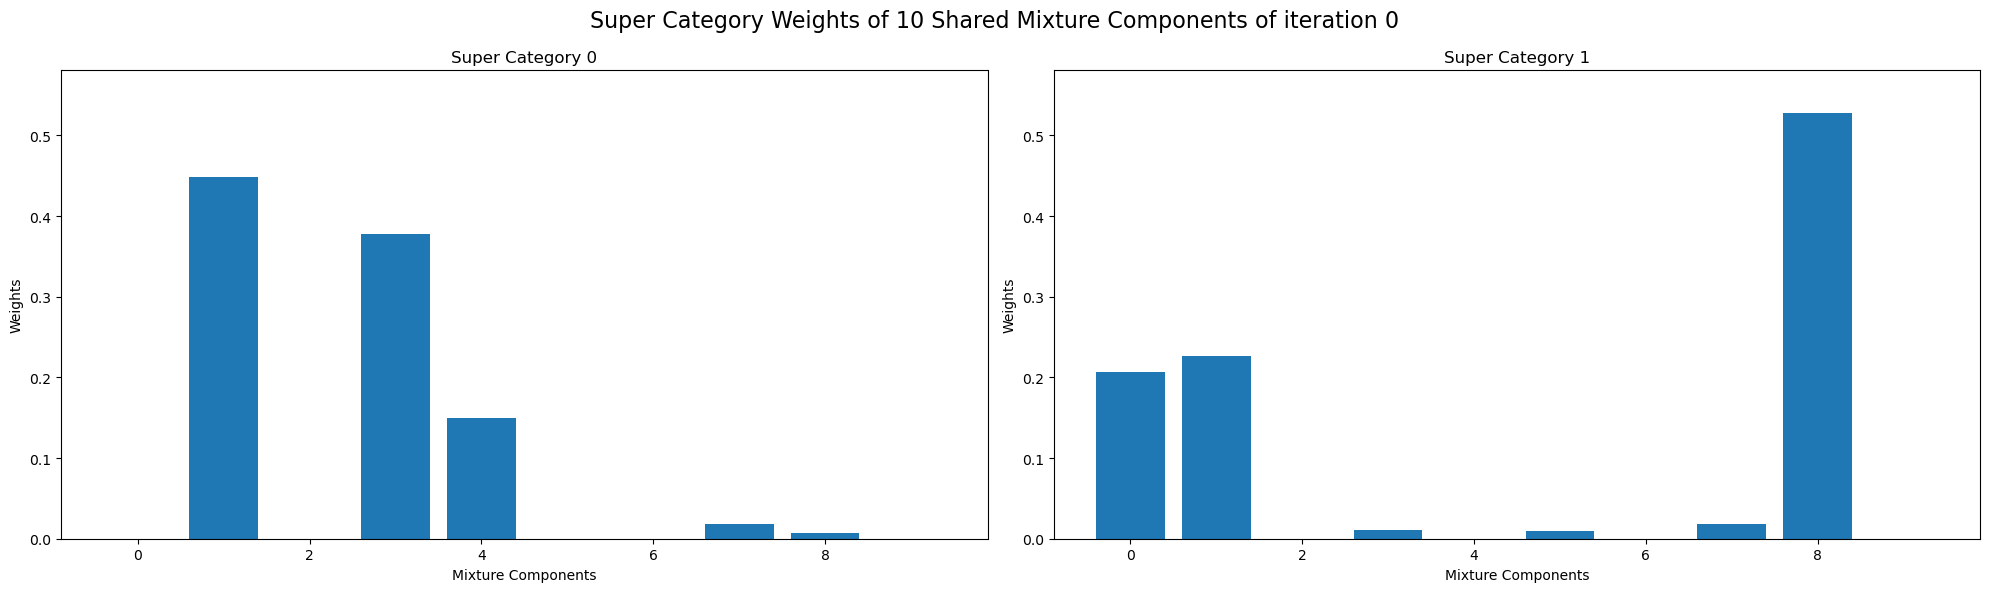

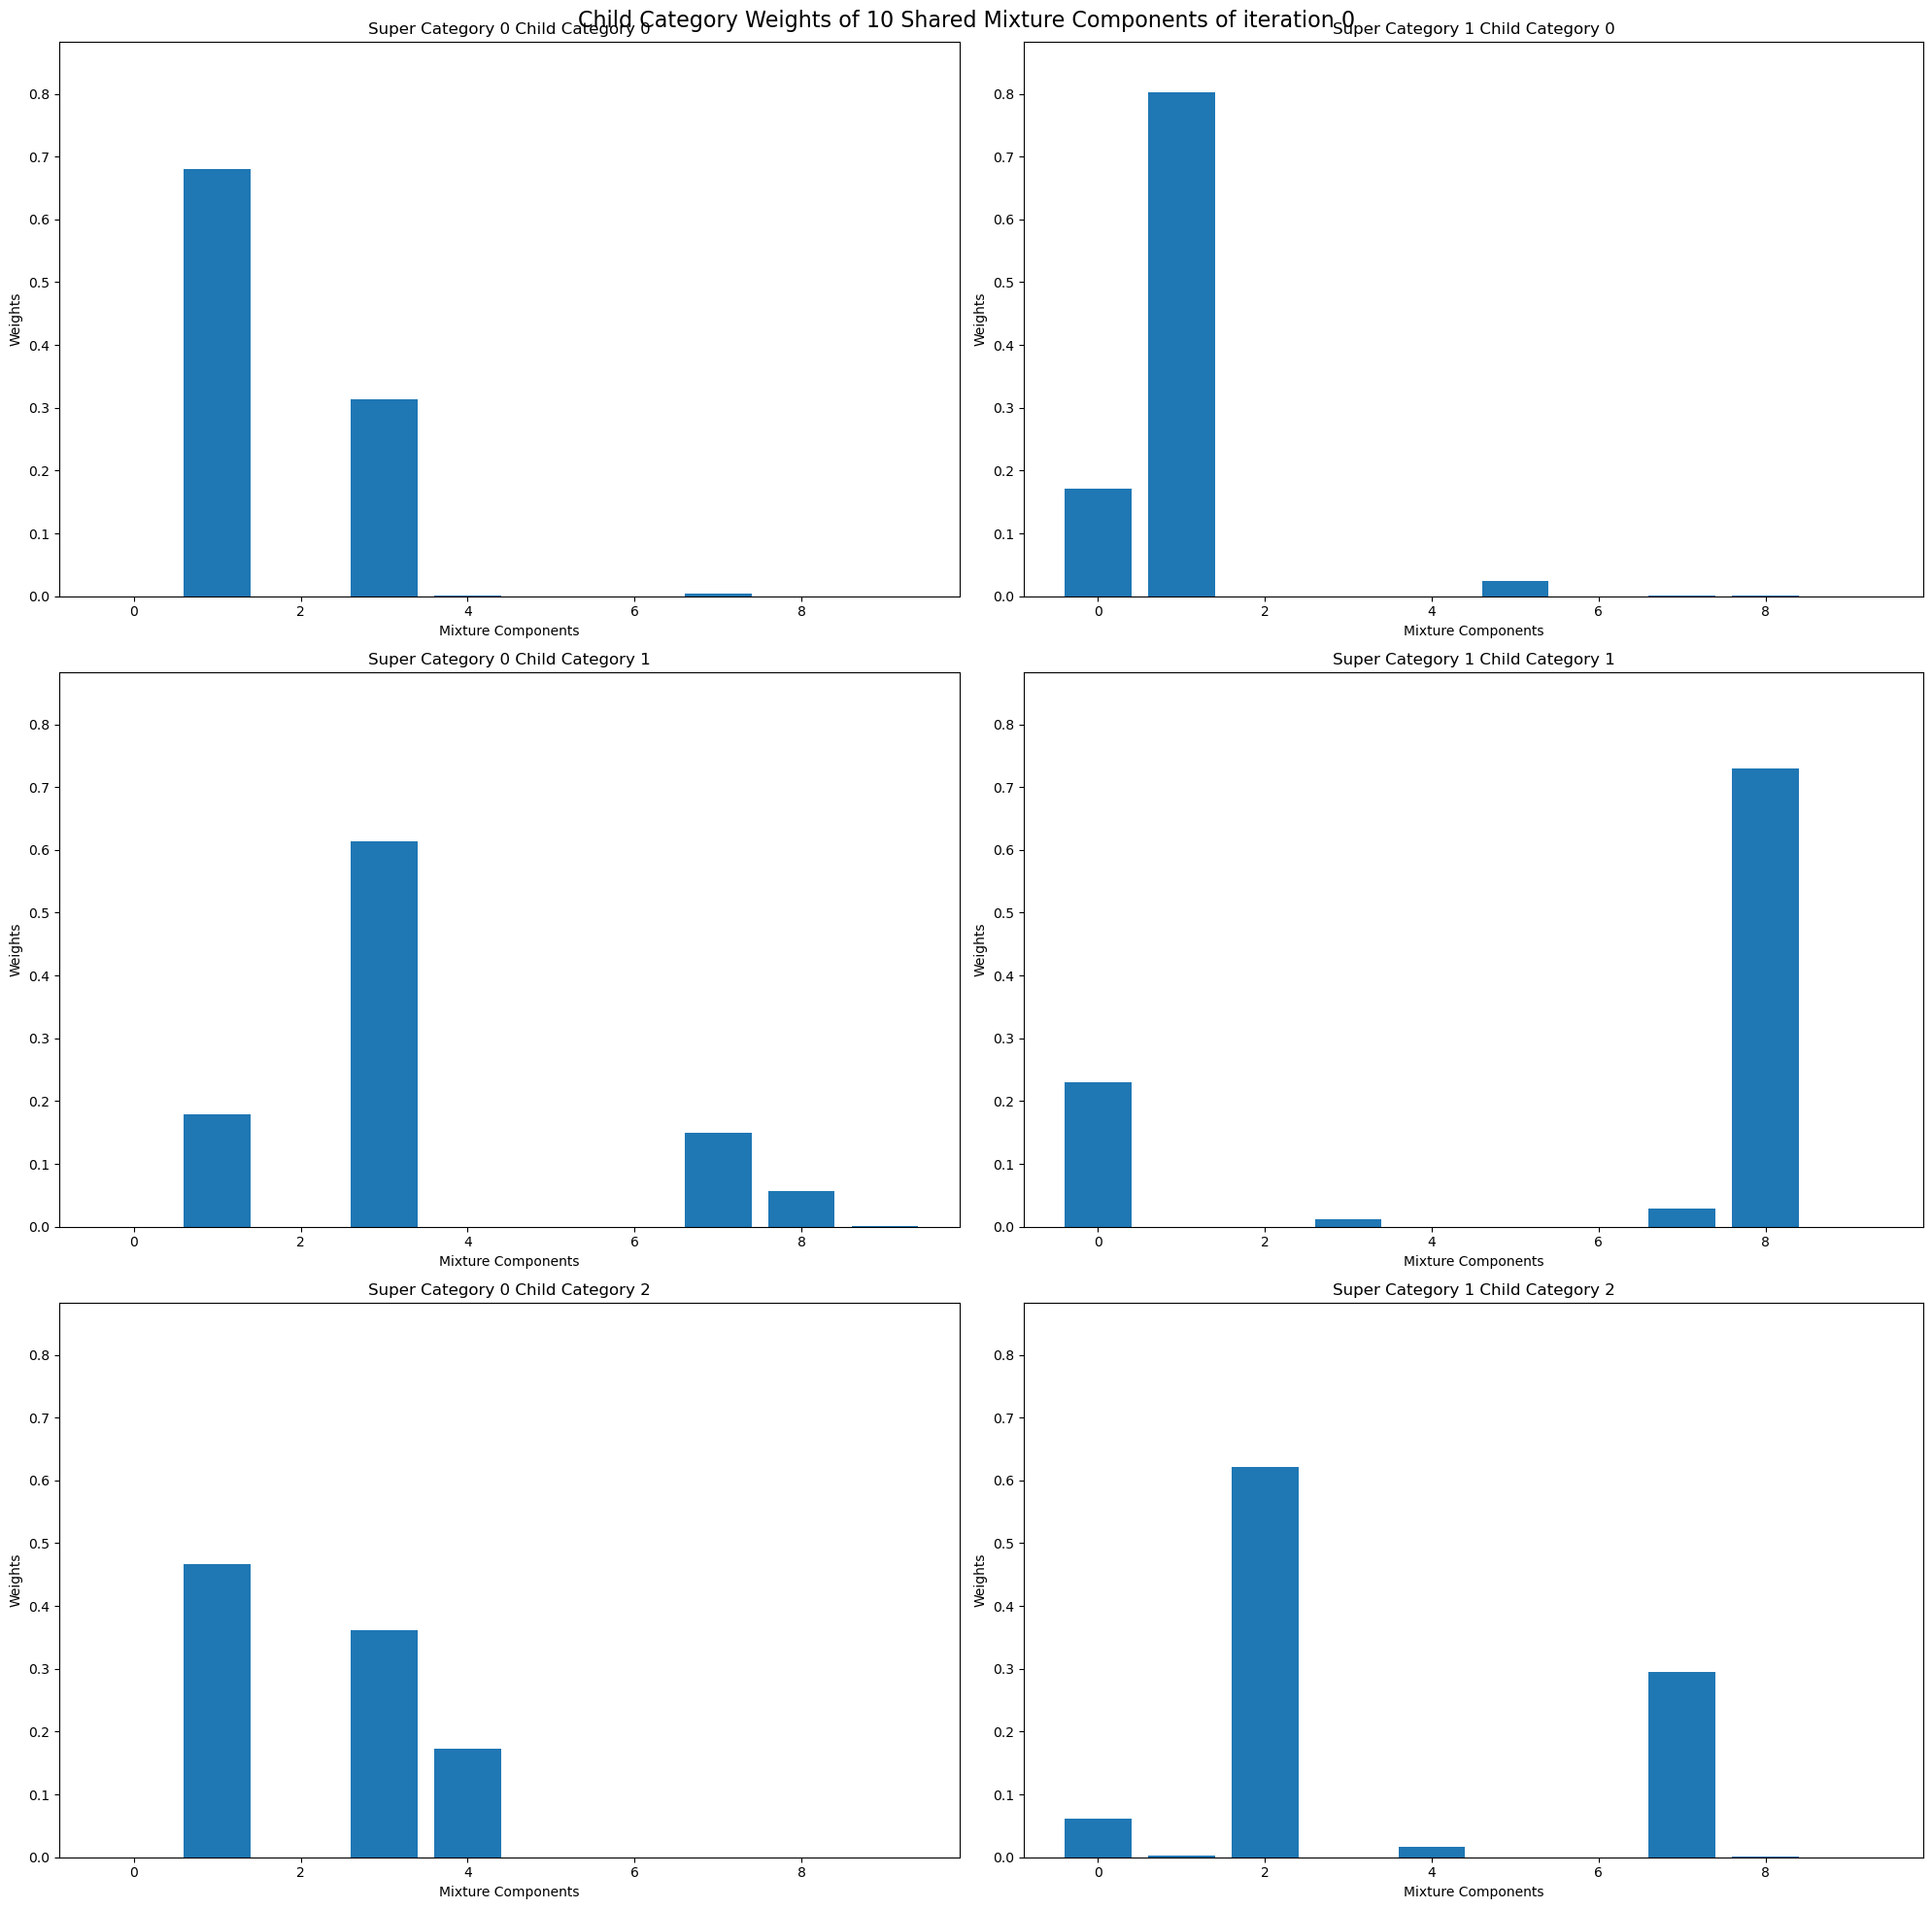

Gibbs Sampling:  10%|█         | 50/500 [53:23<7:28:40, 59.82s/it]

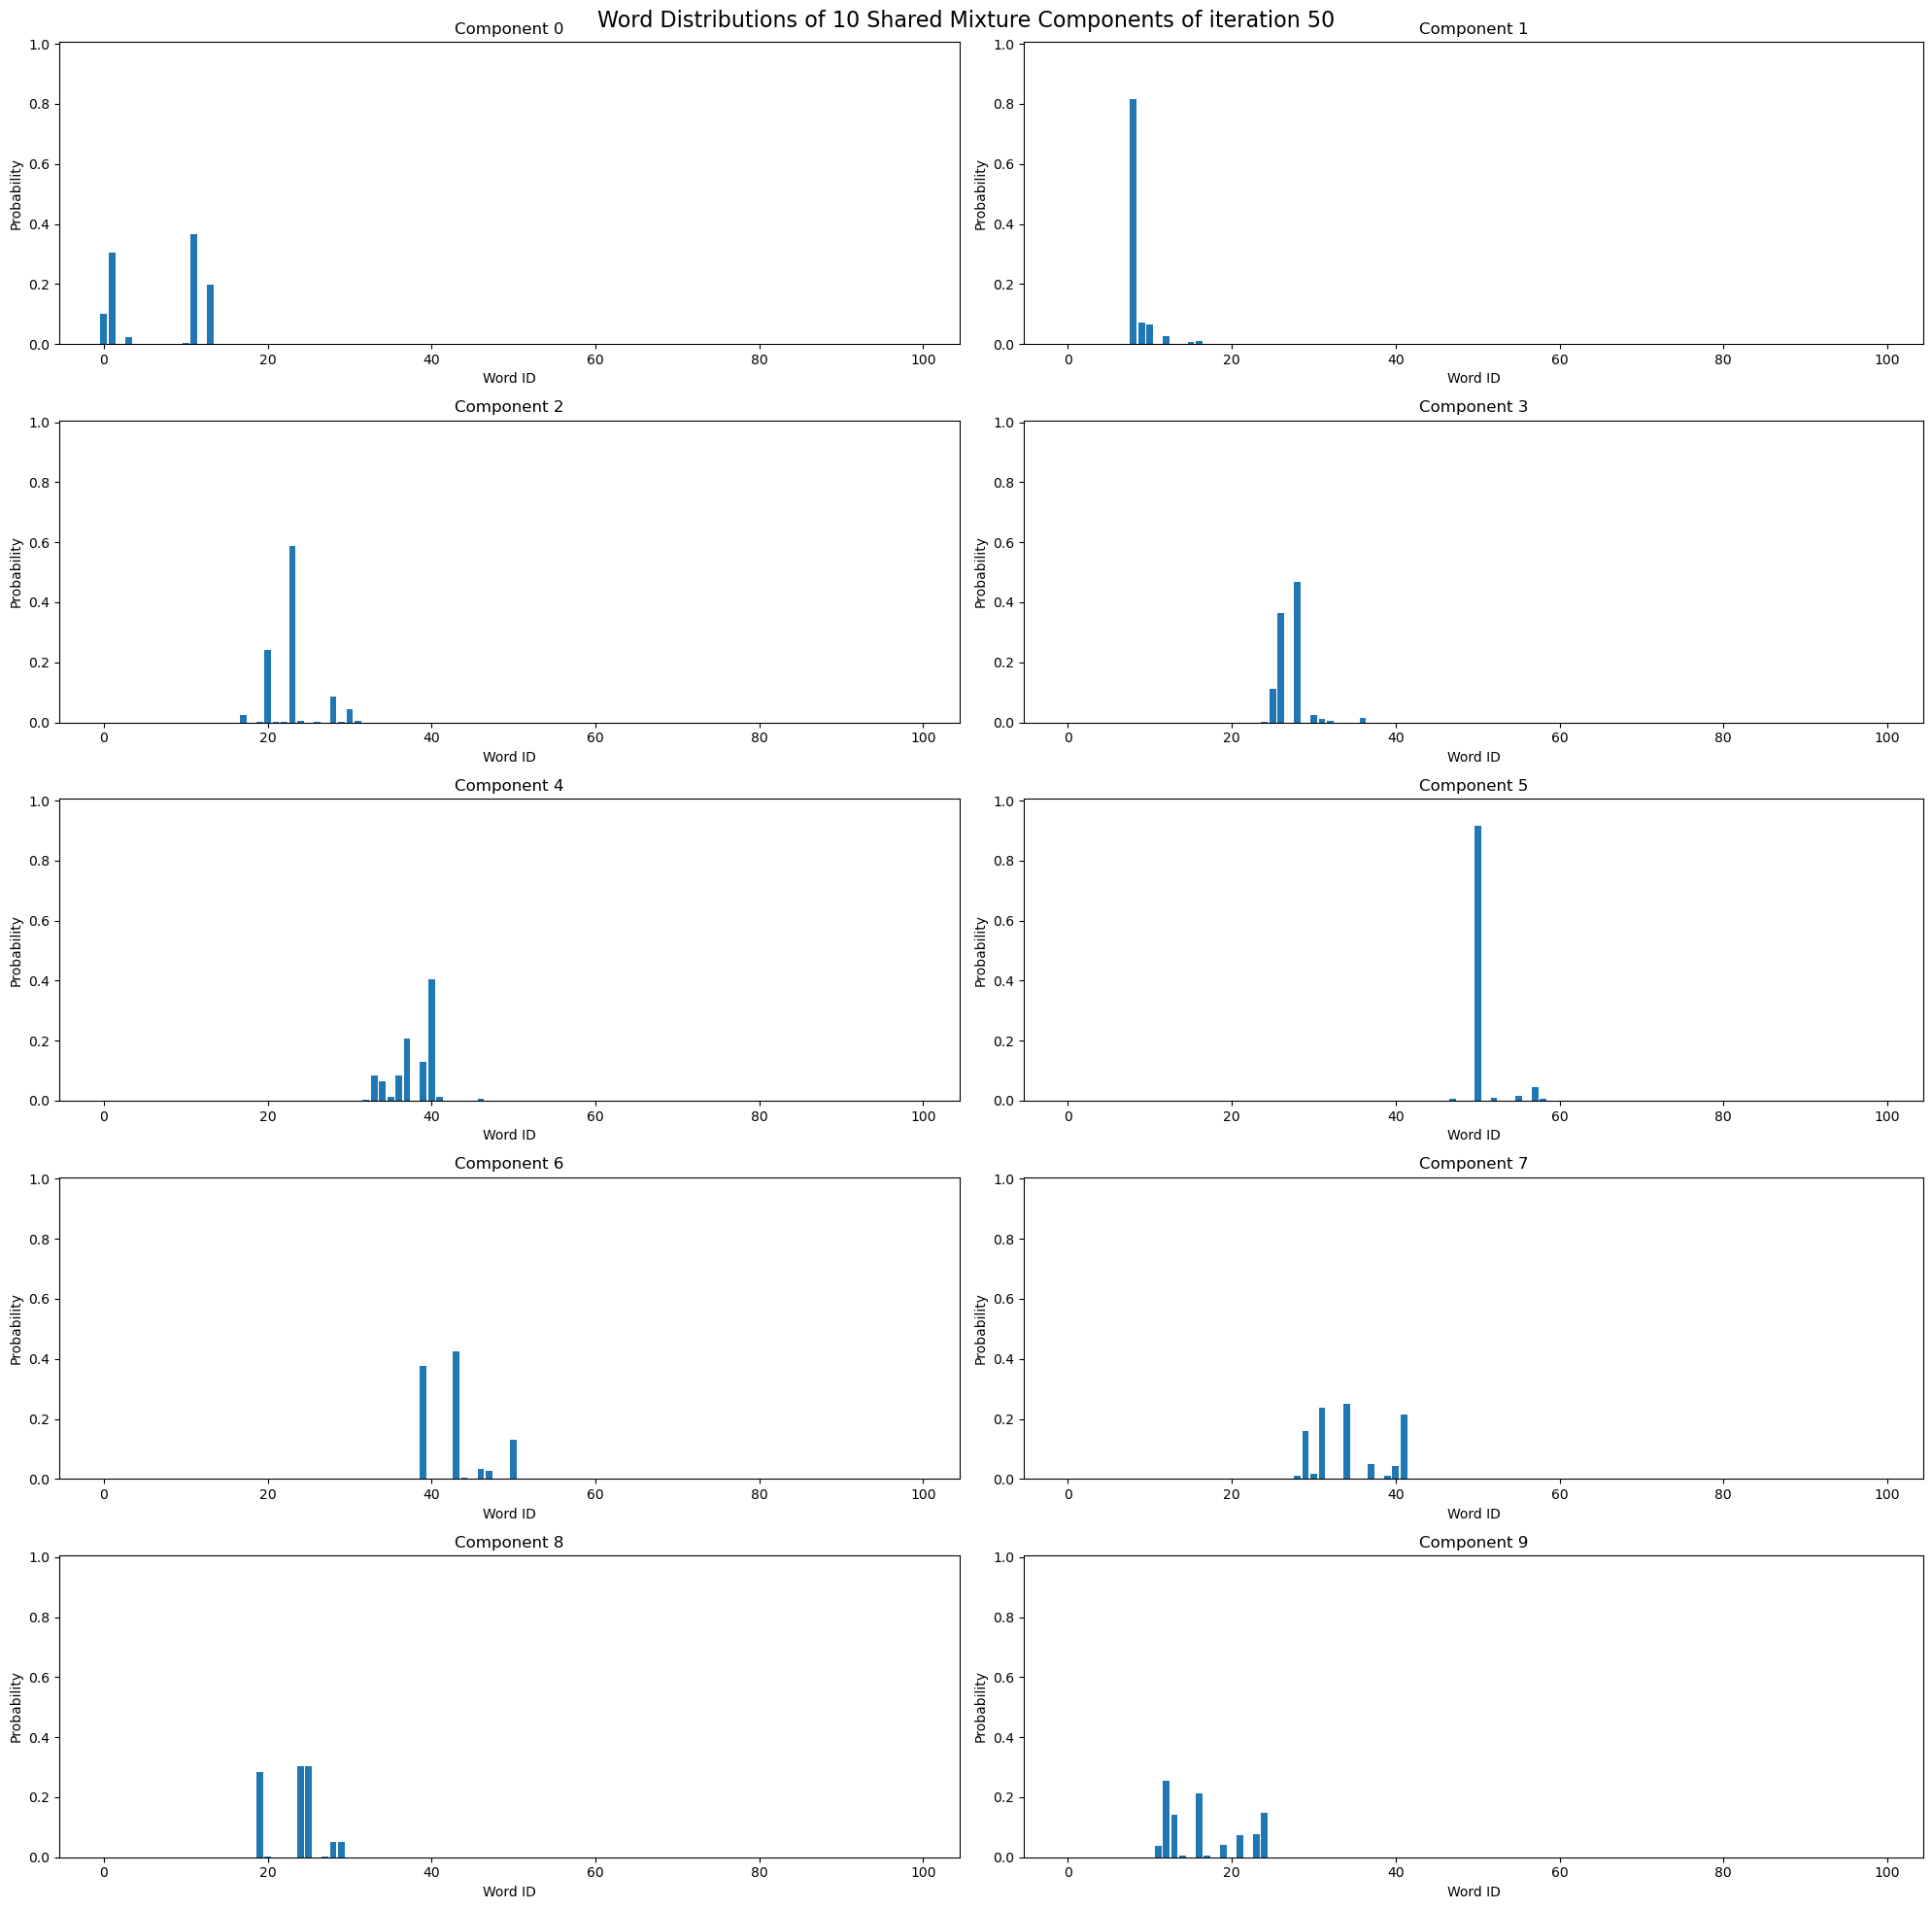

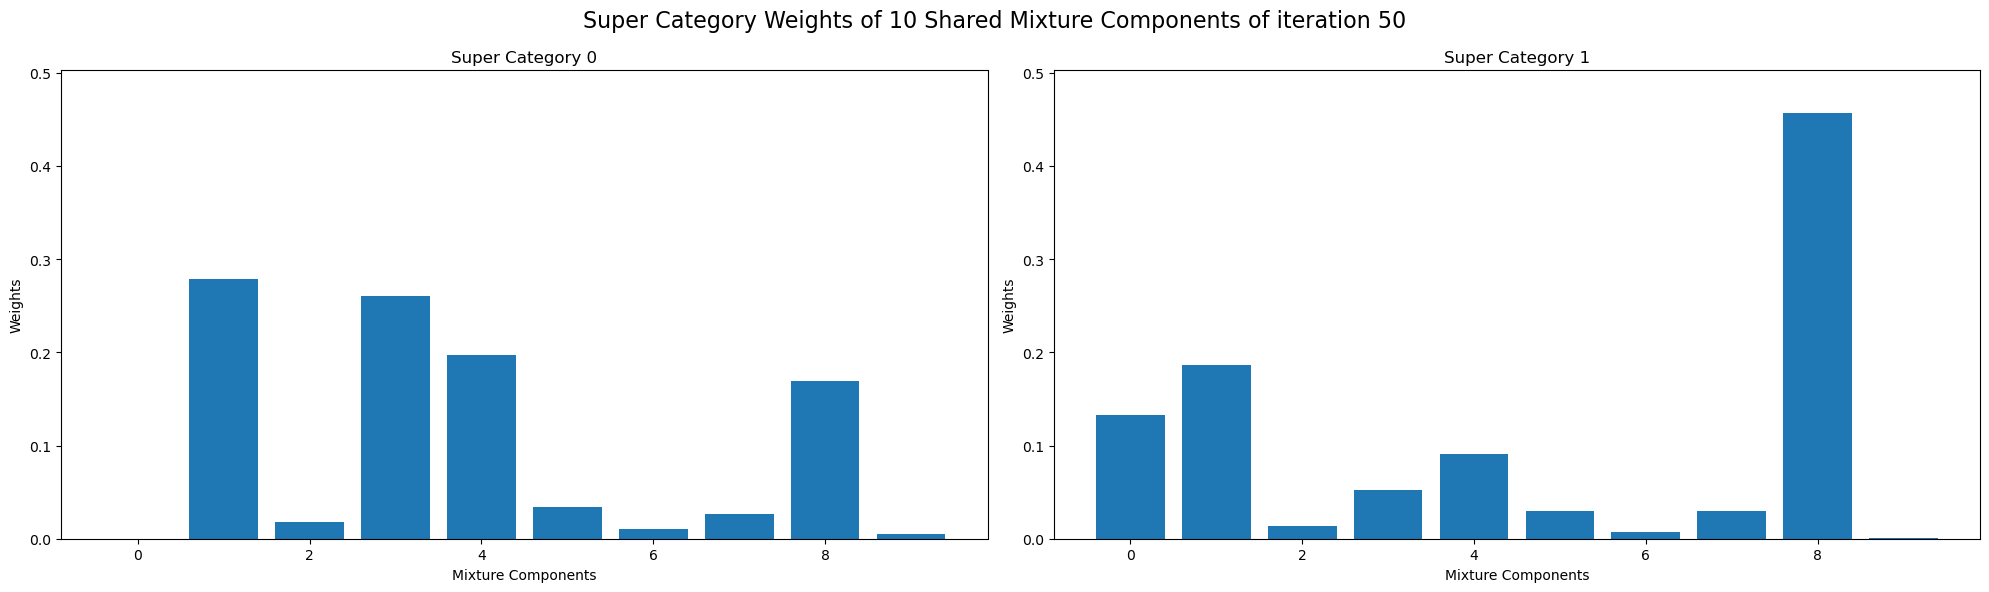

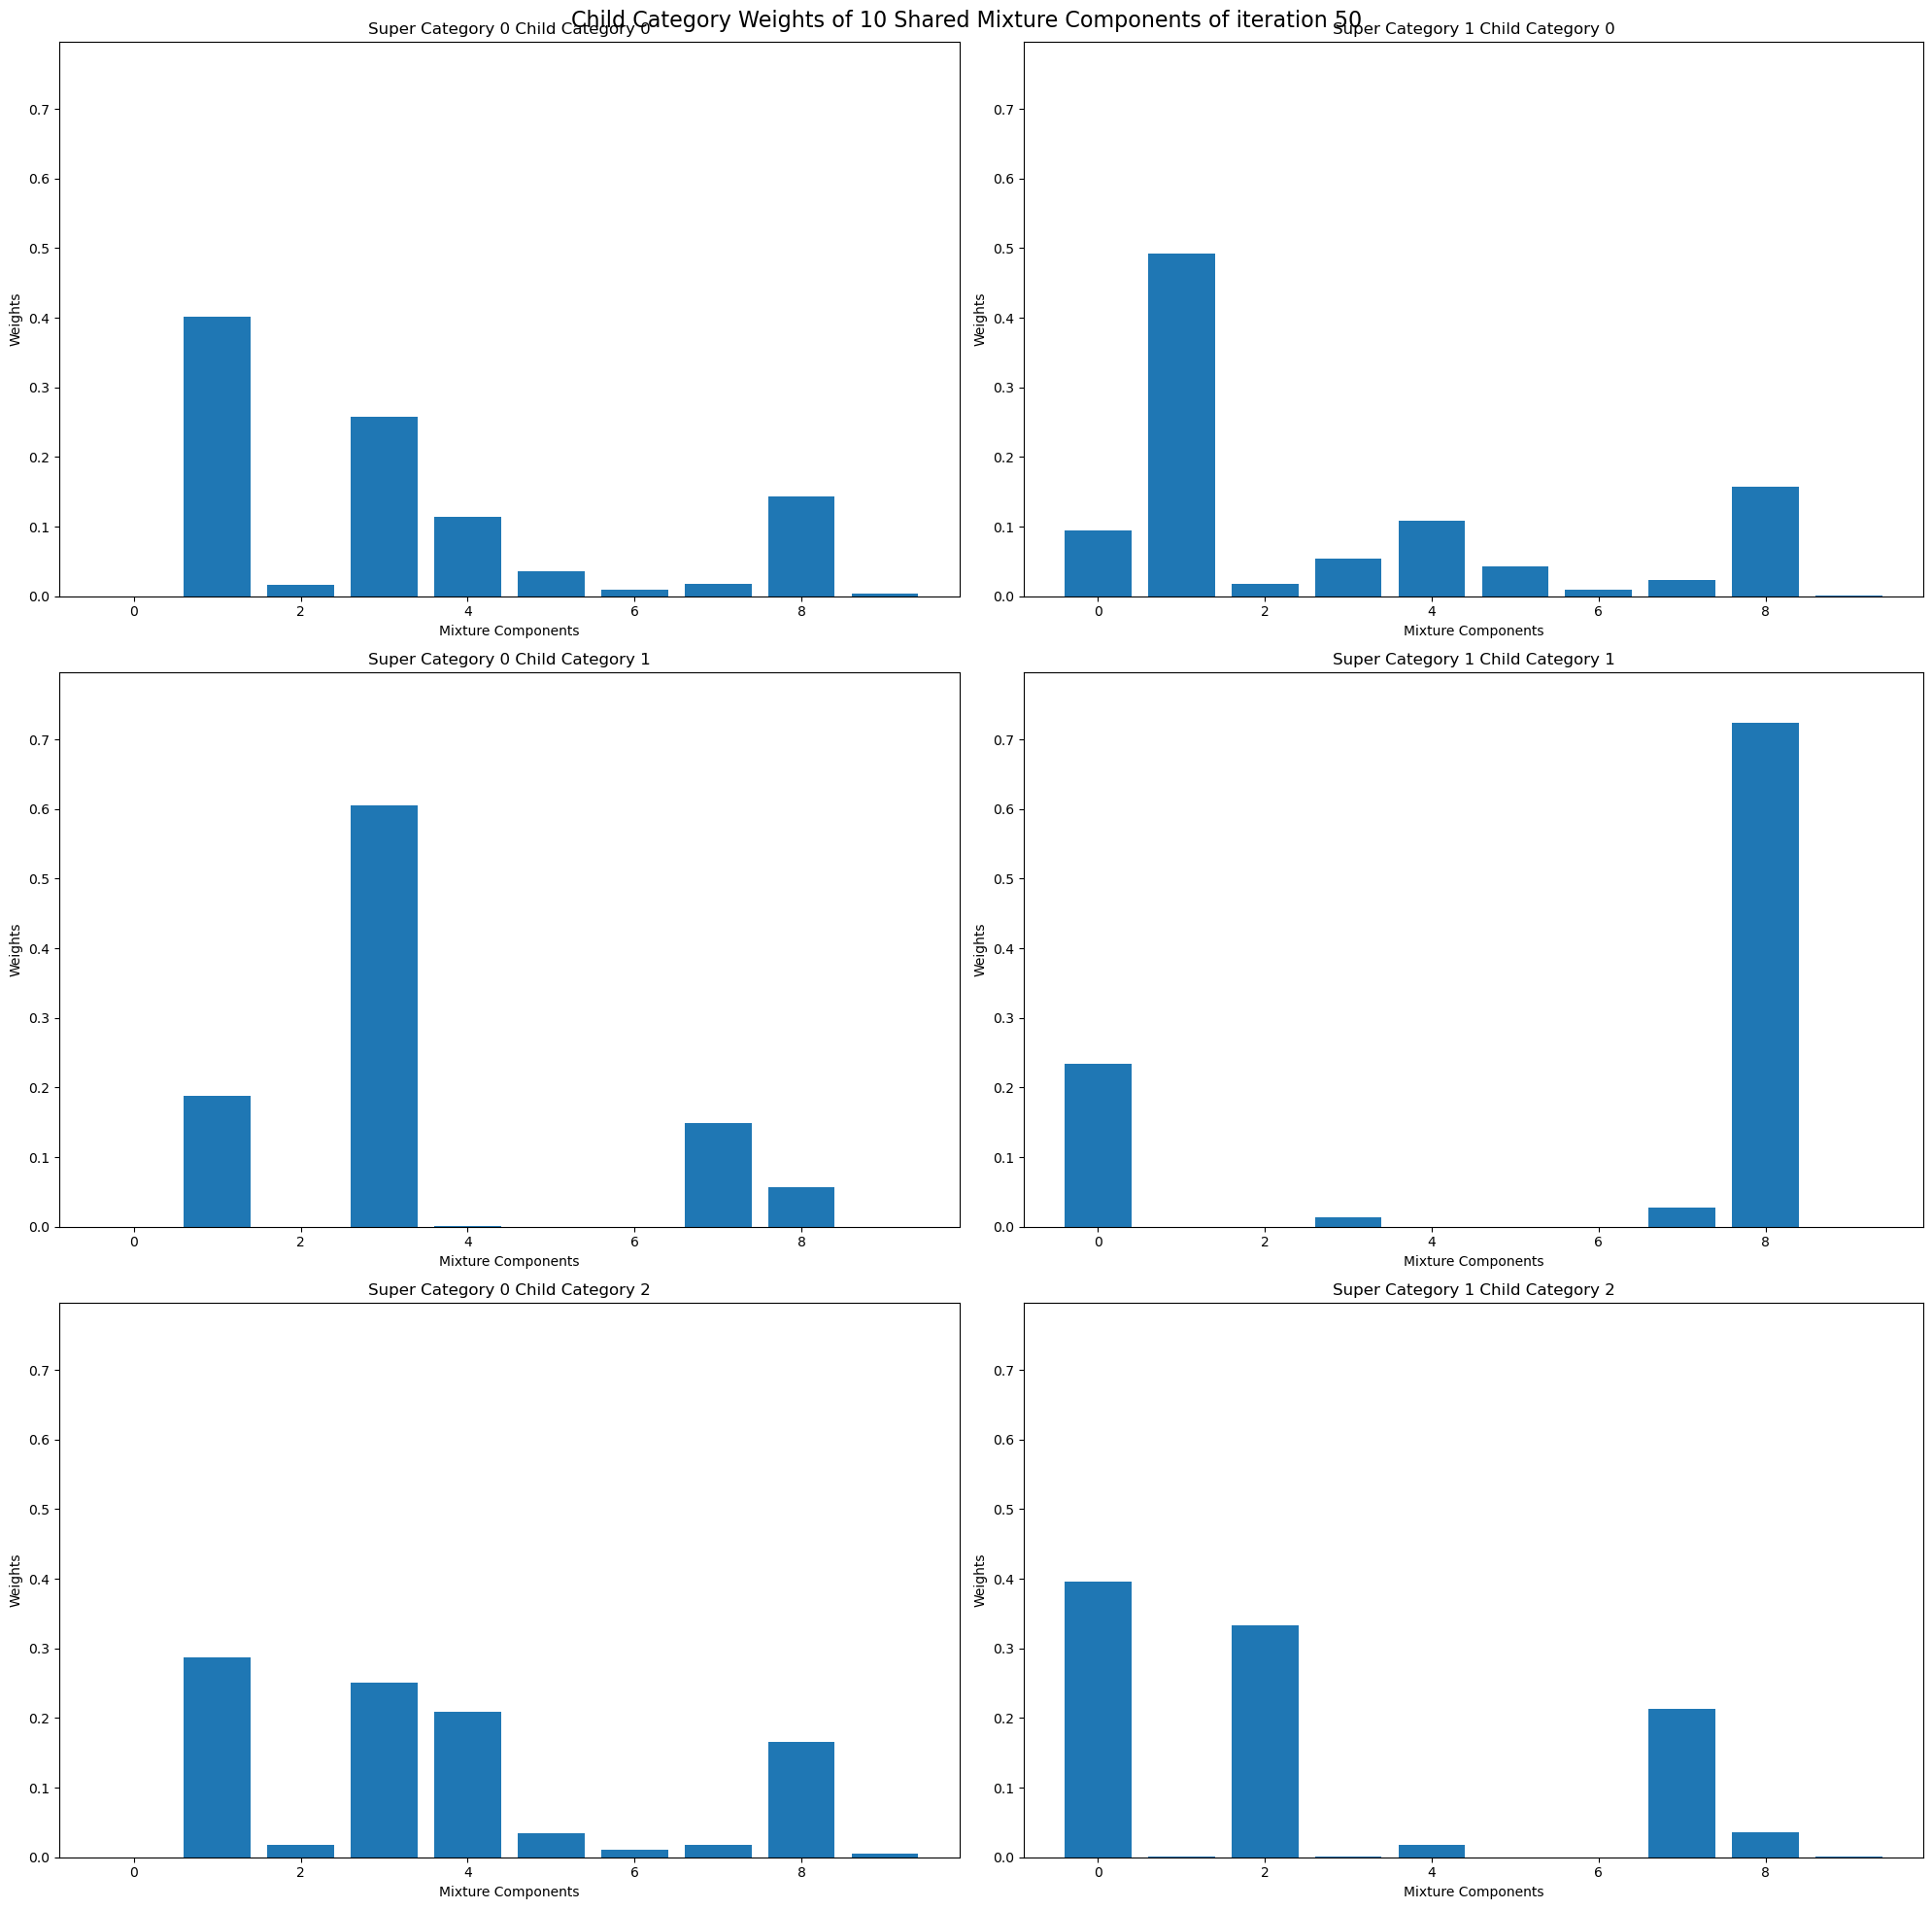

Gibbs Sampling:  20%|██        | 100/500 [1:43:44<6:36:53, 59.53s/it]

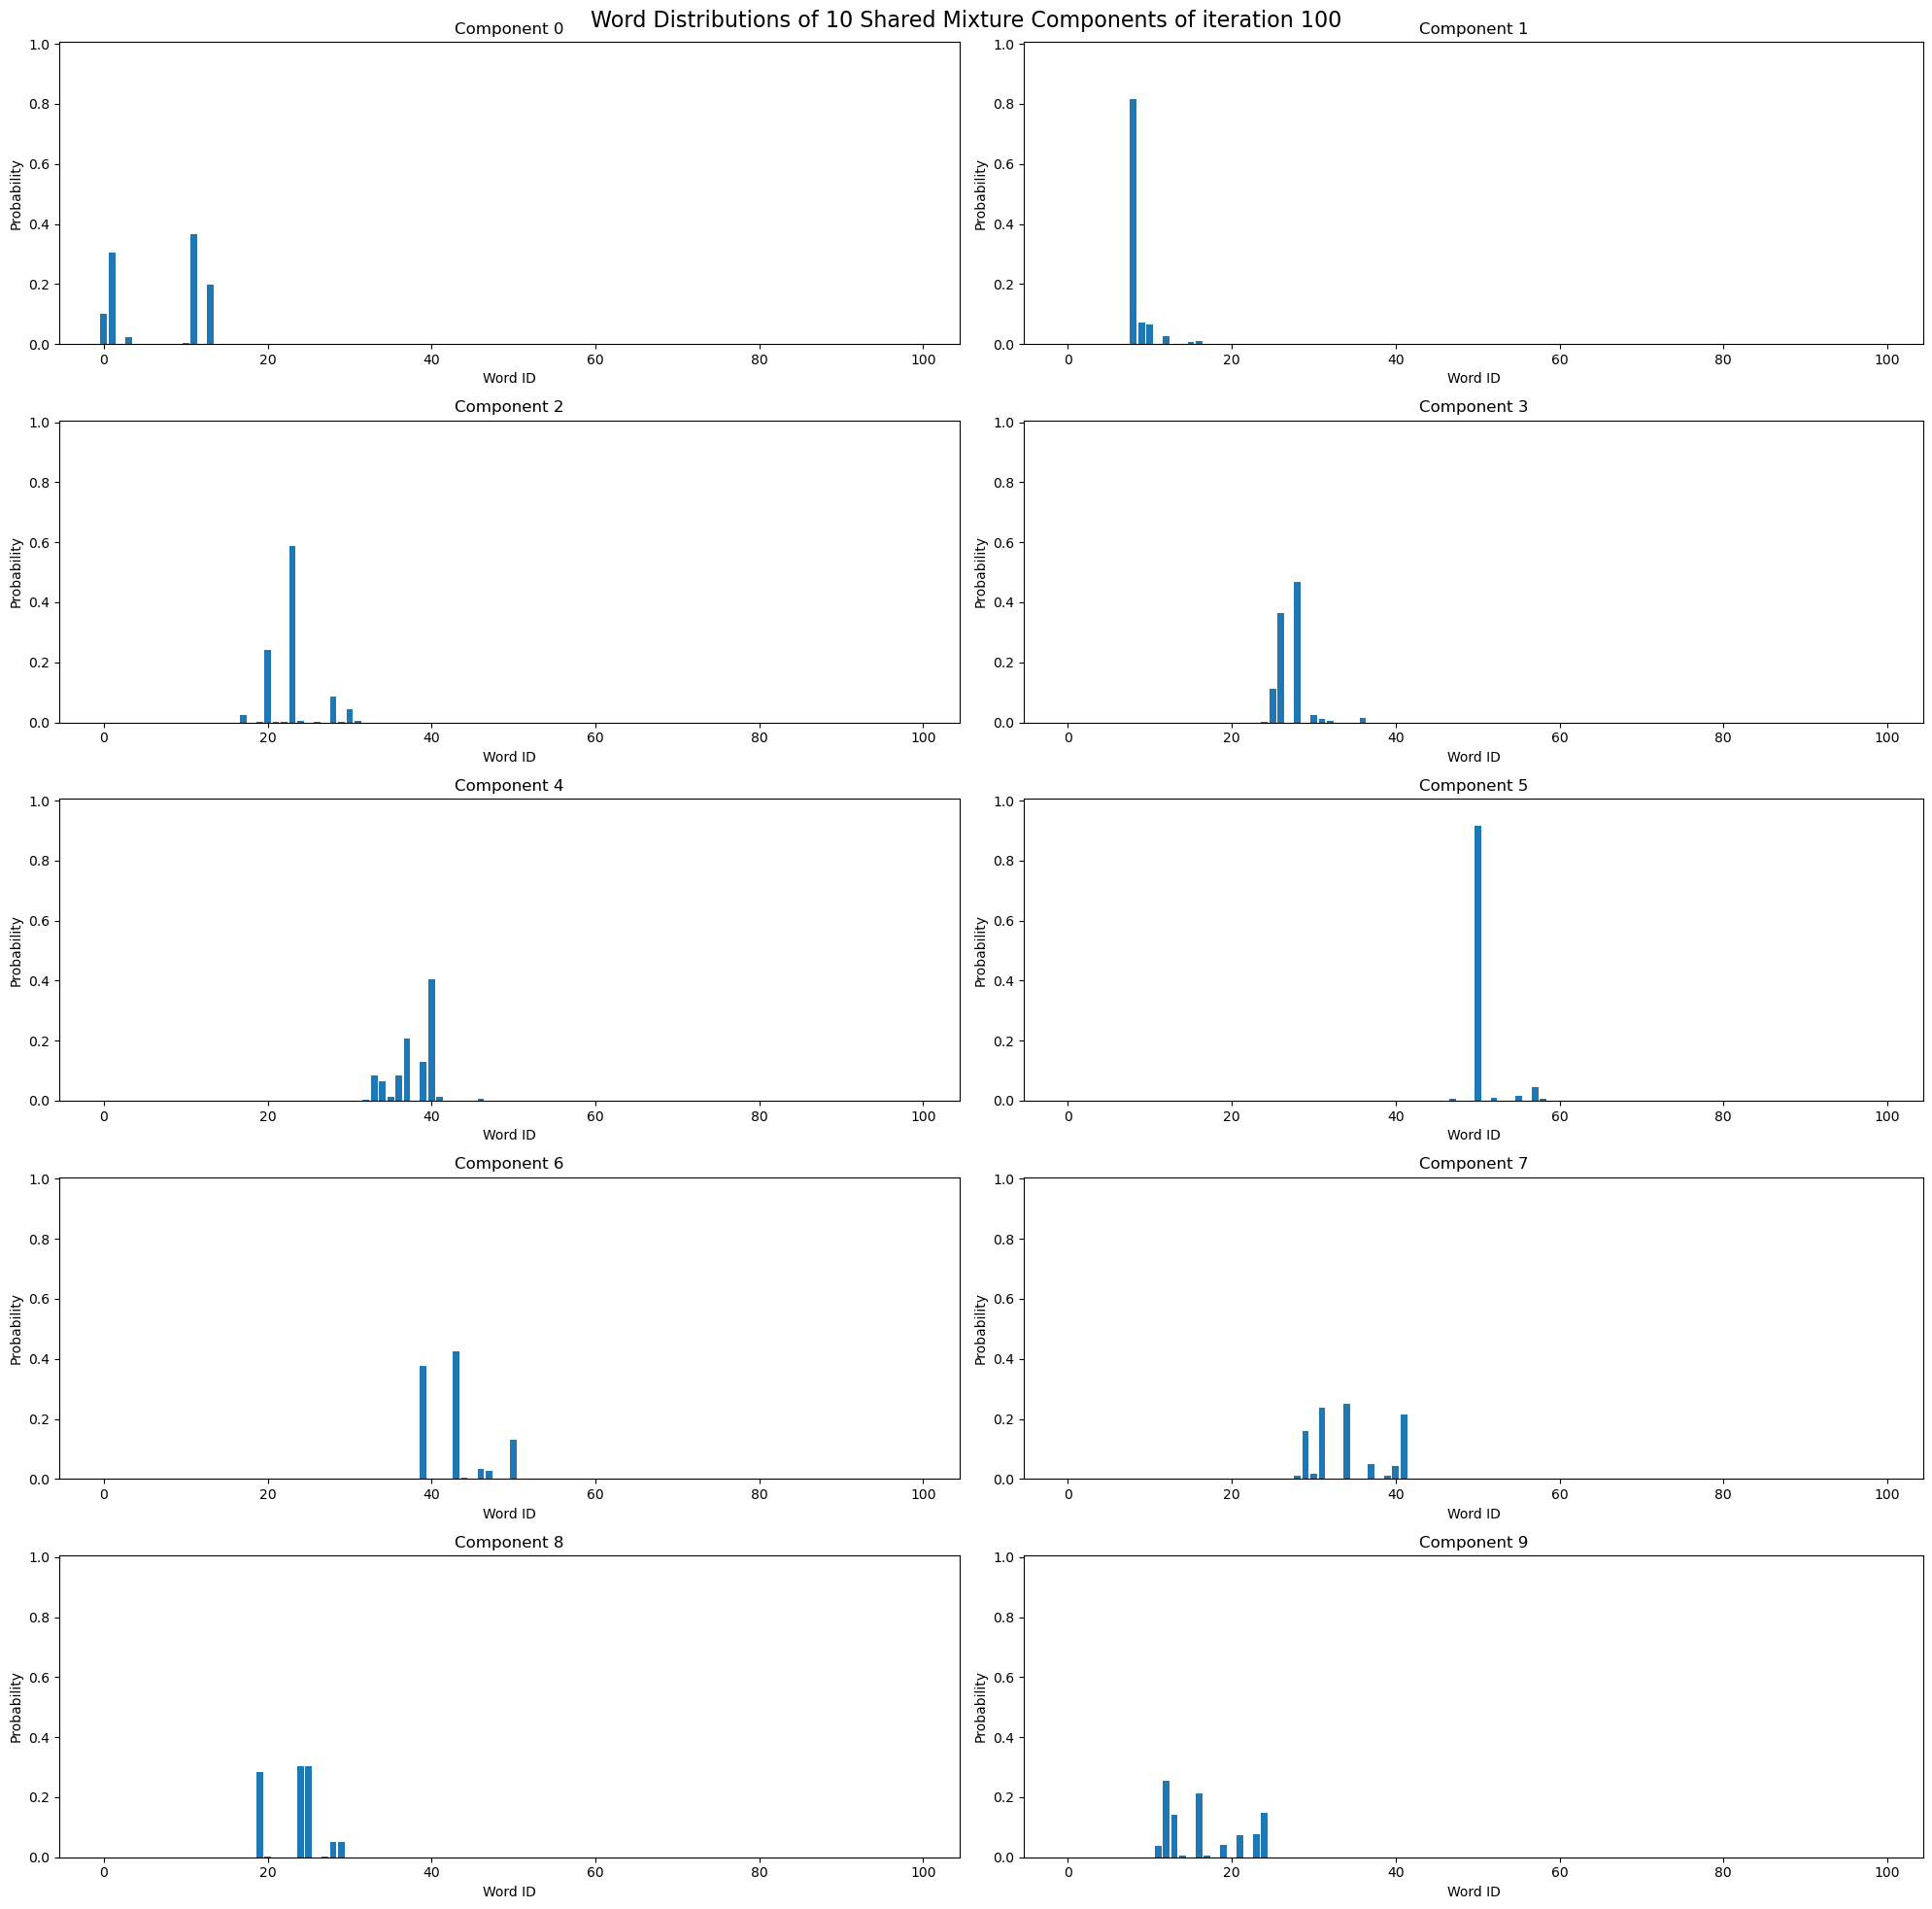

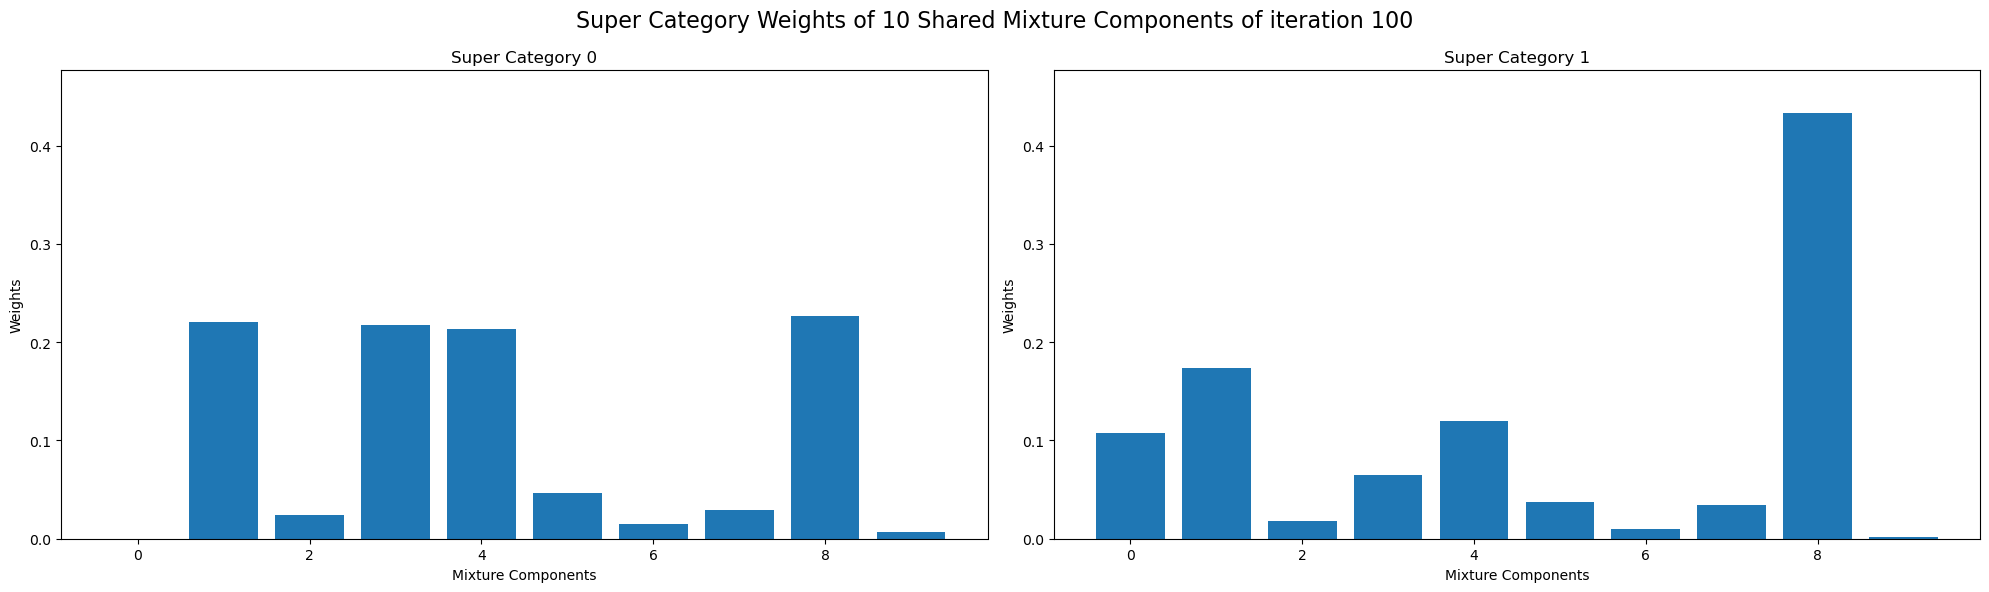

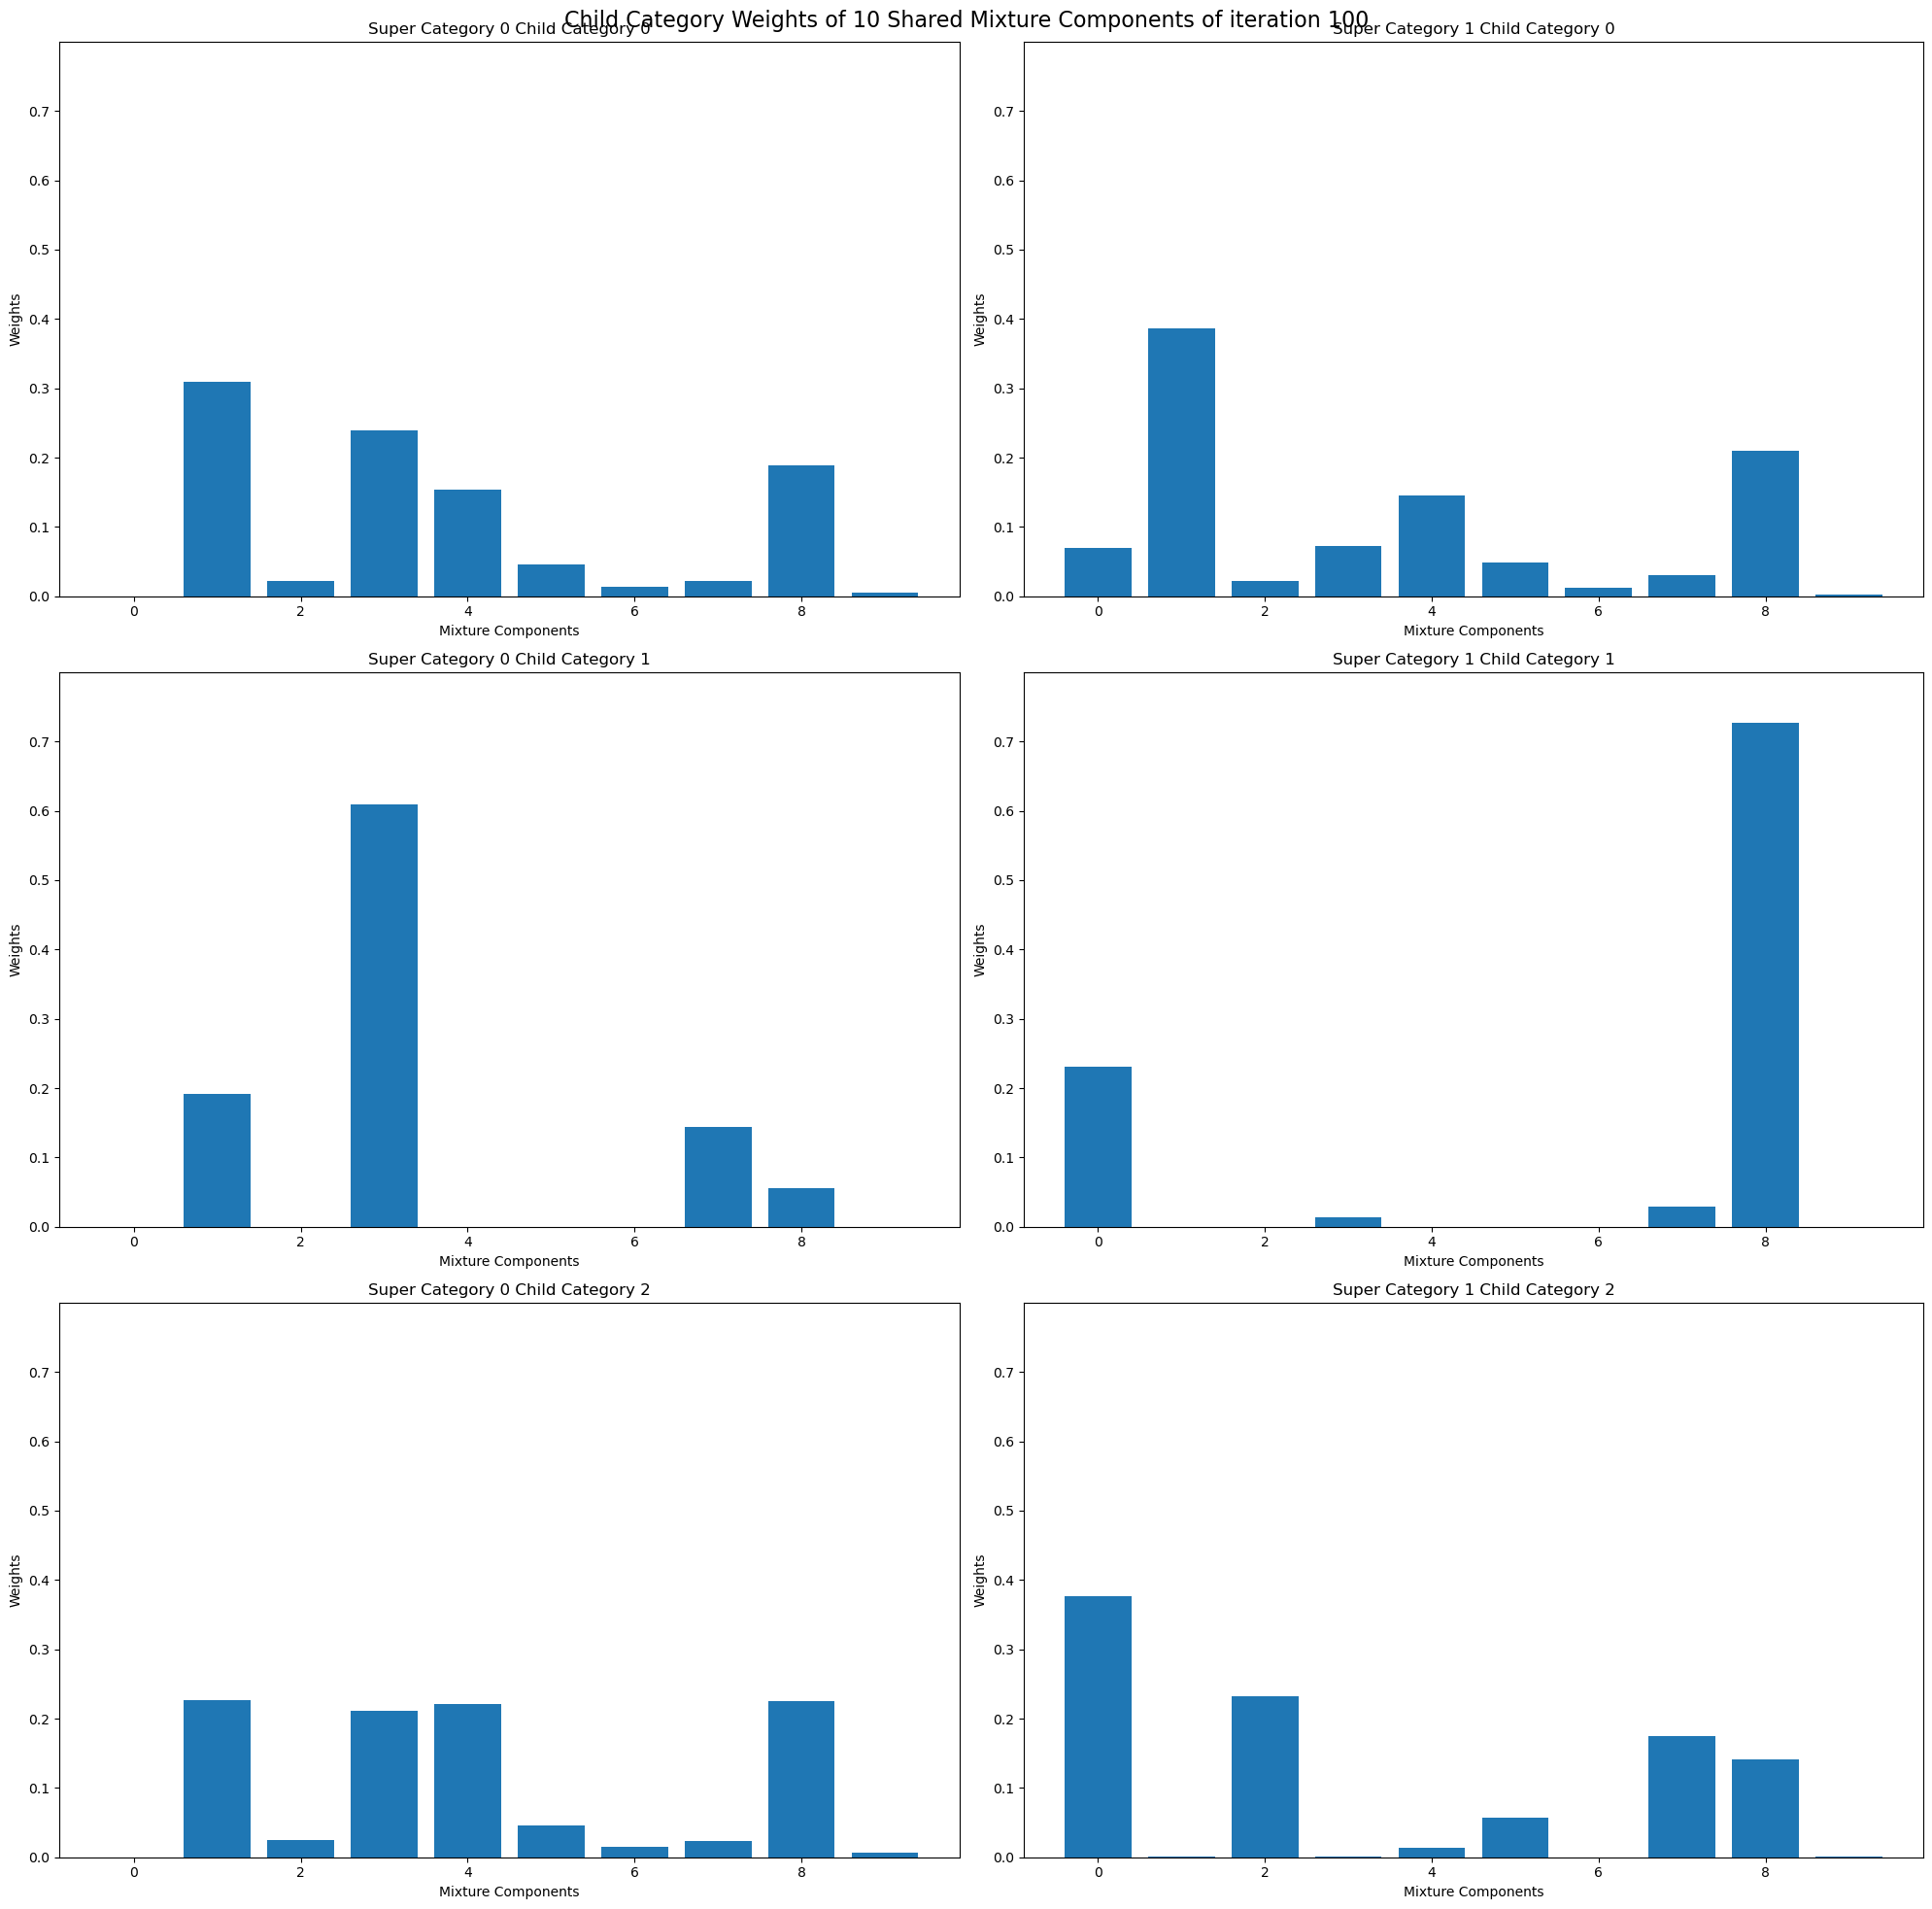

Gibbs Sampling:  30%|███       | 150/500 [2:29:29<5:17:56, 54.51s/it]

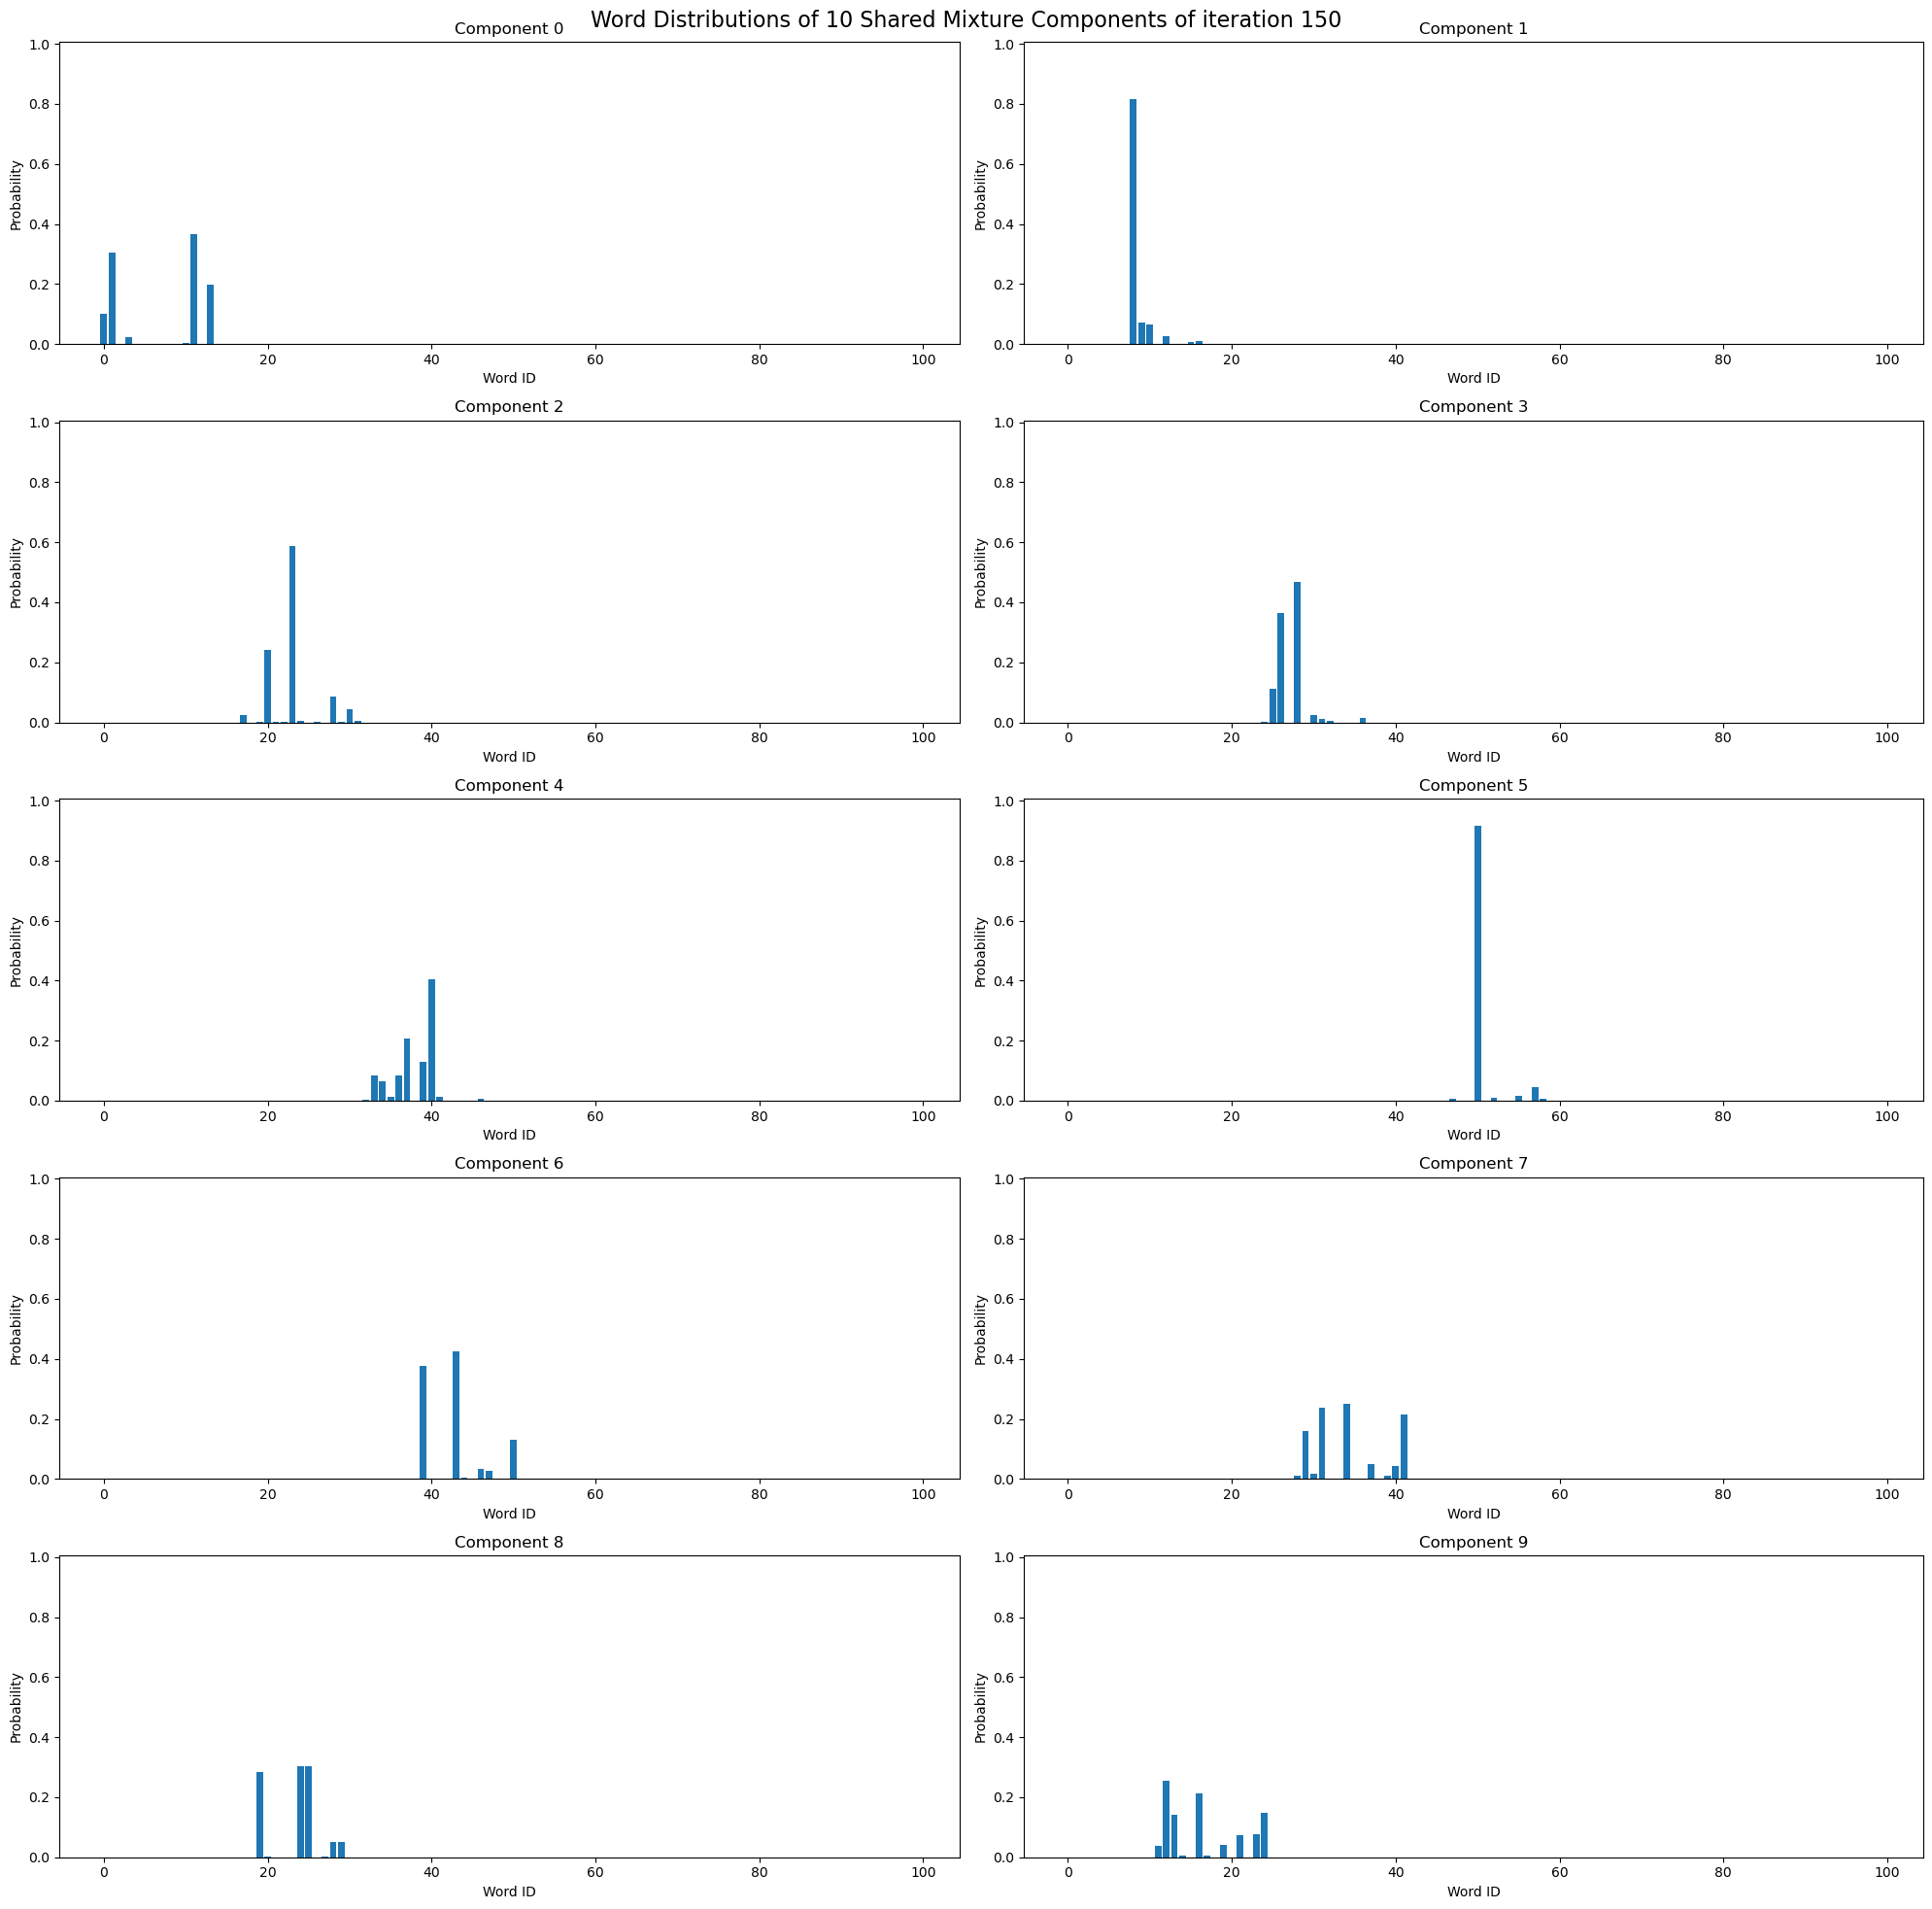

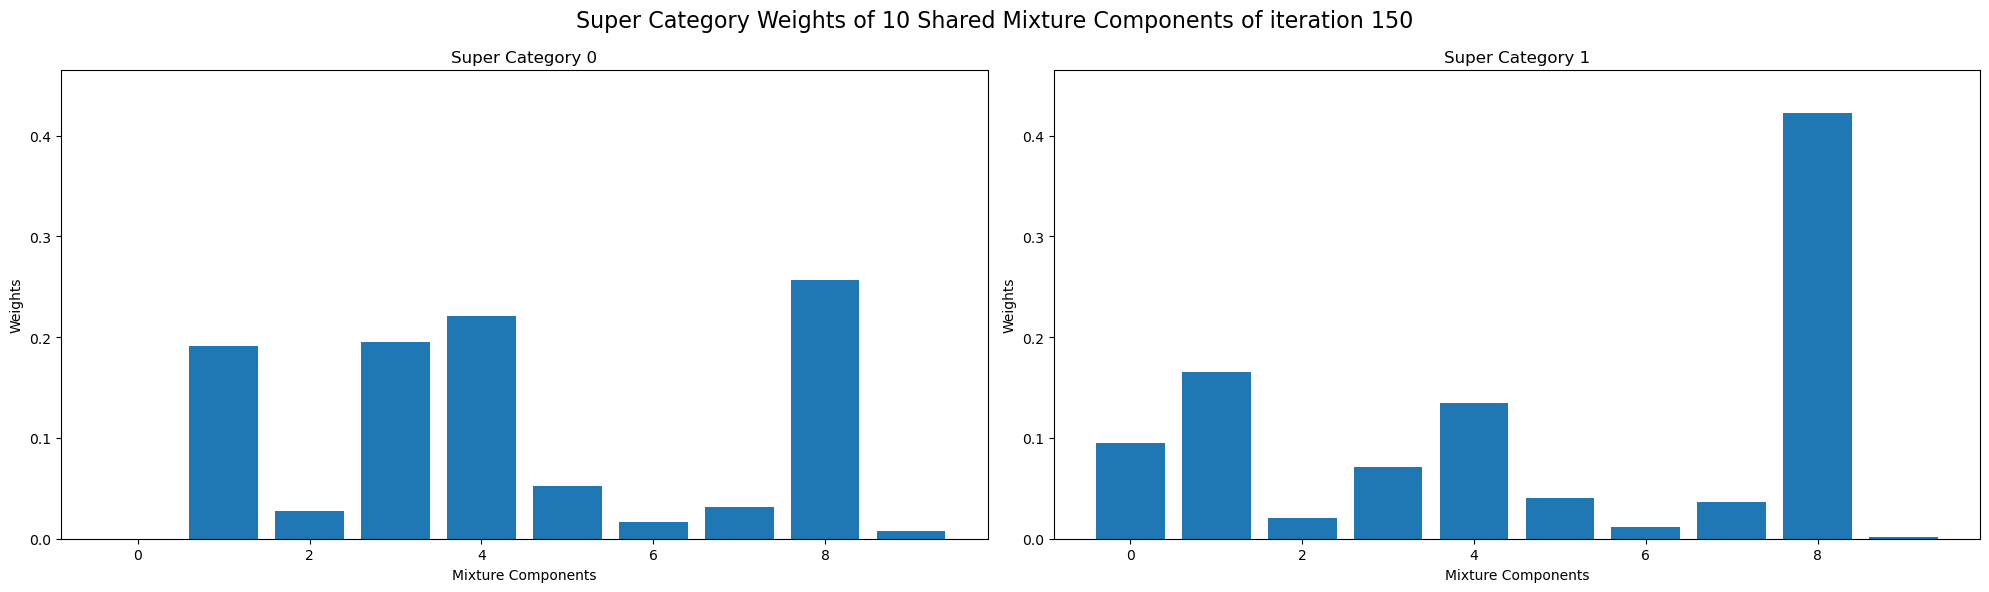

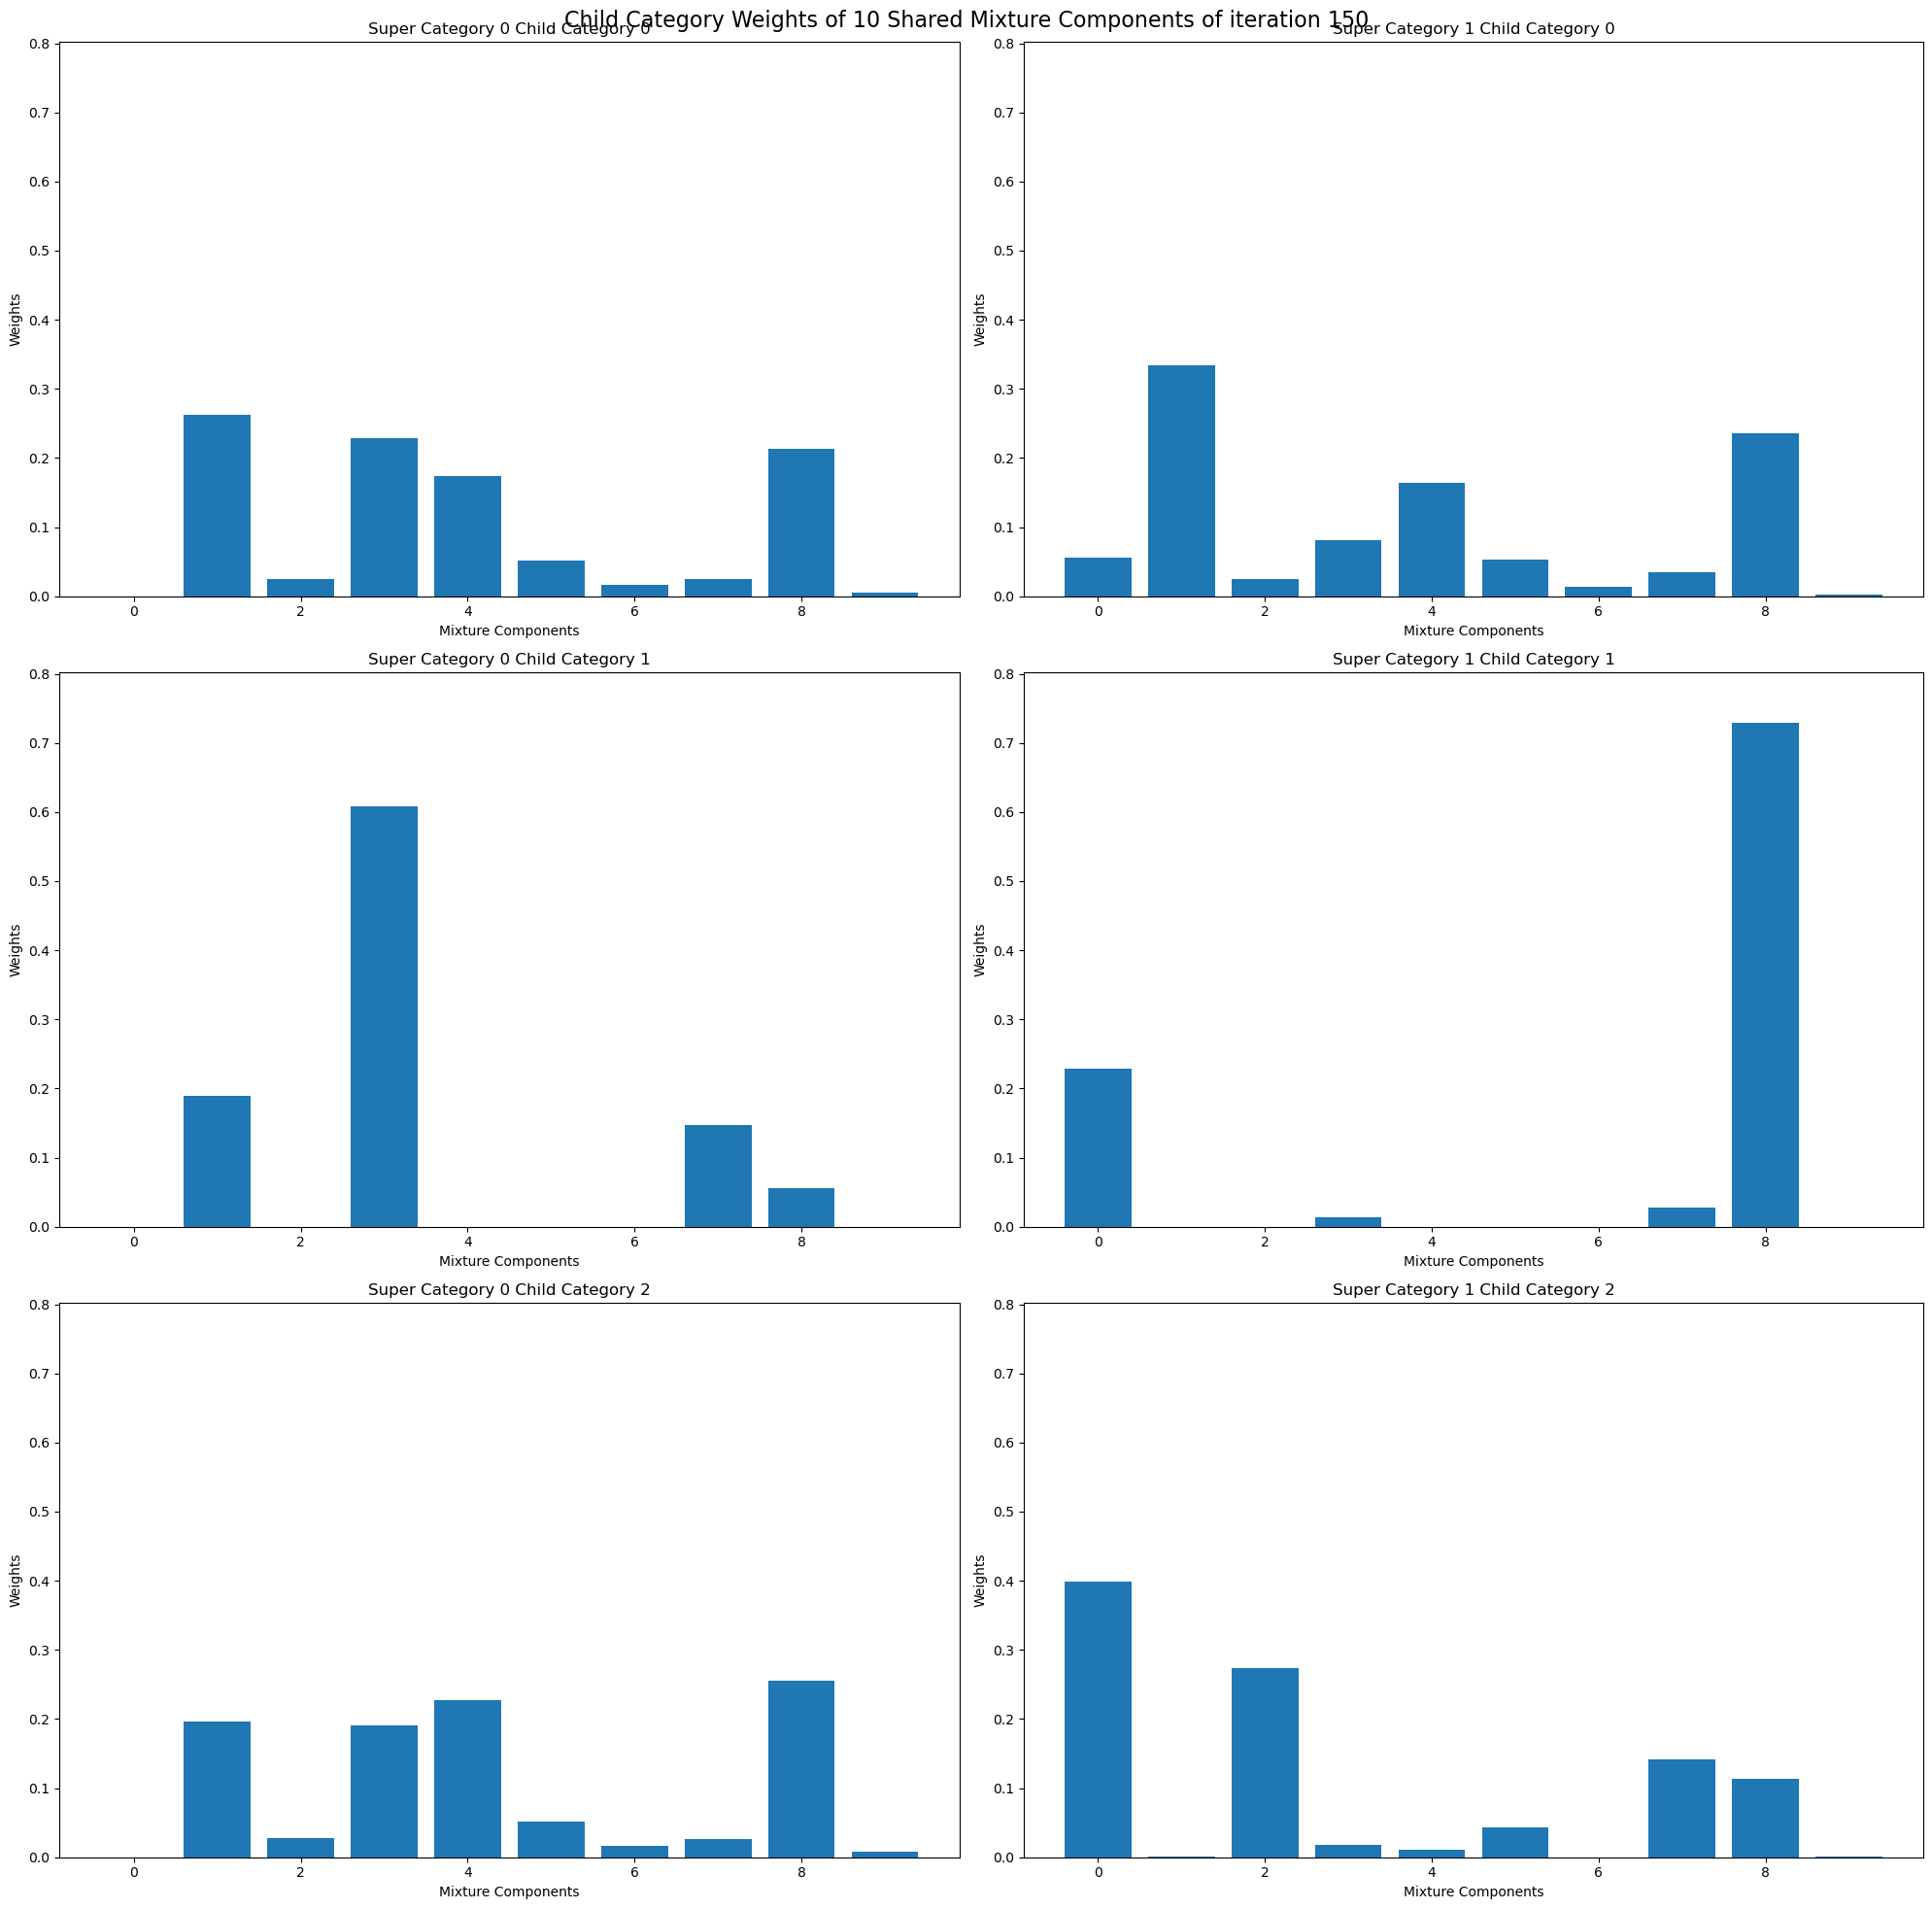

Gibbs Sampling:  40%|████      | 200/500 [3:15:00<4:32:52, 54.57s/it]

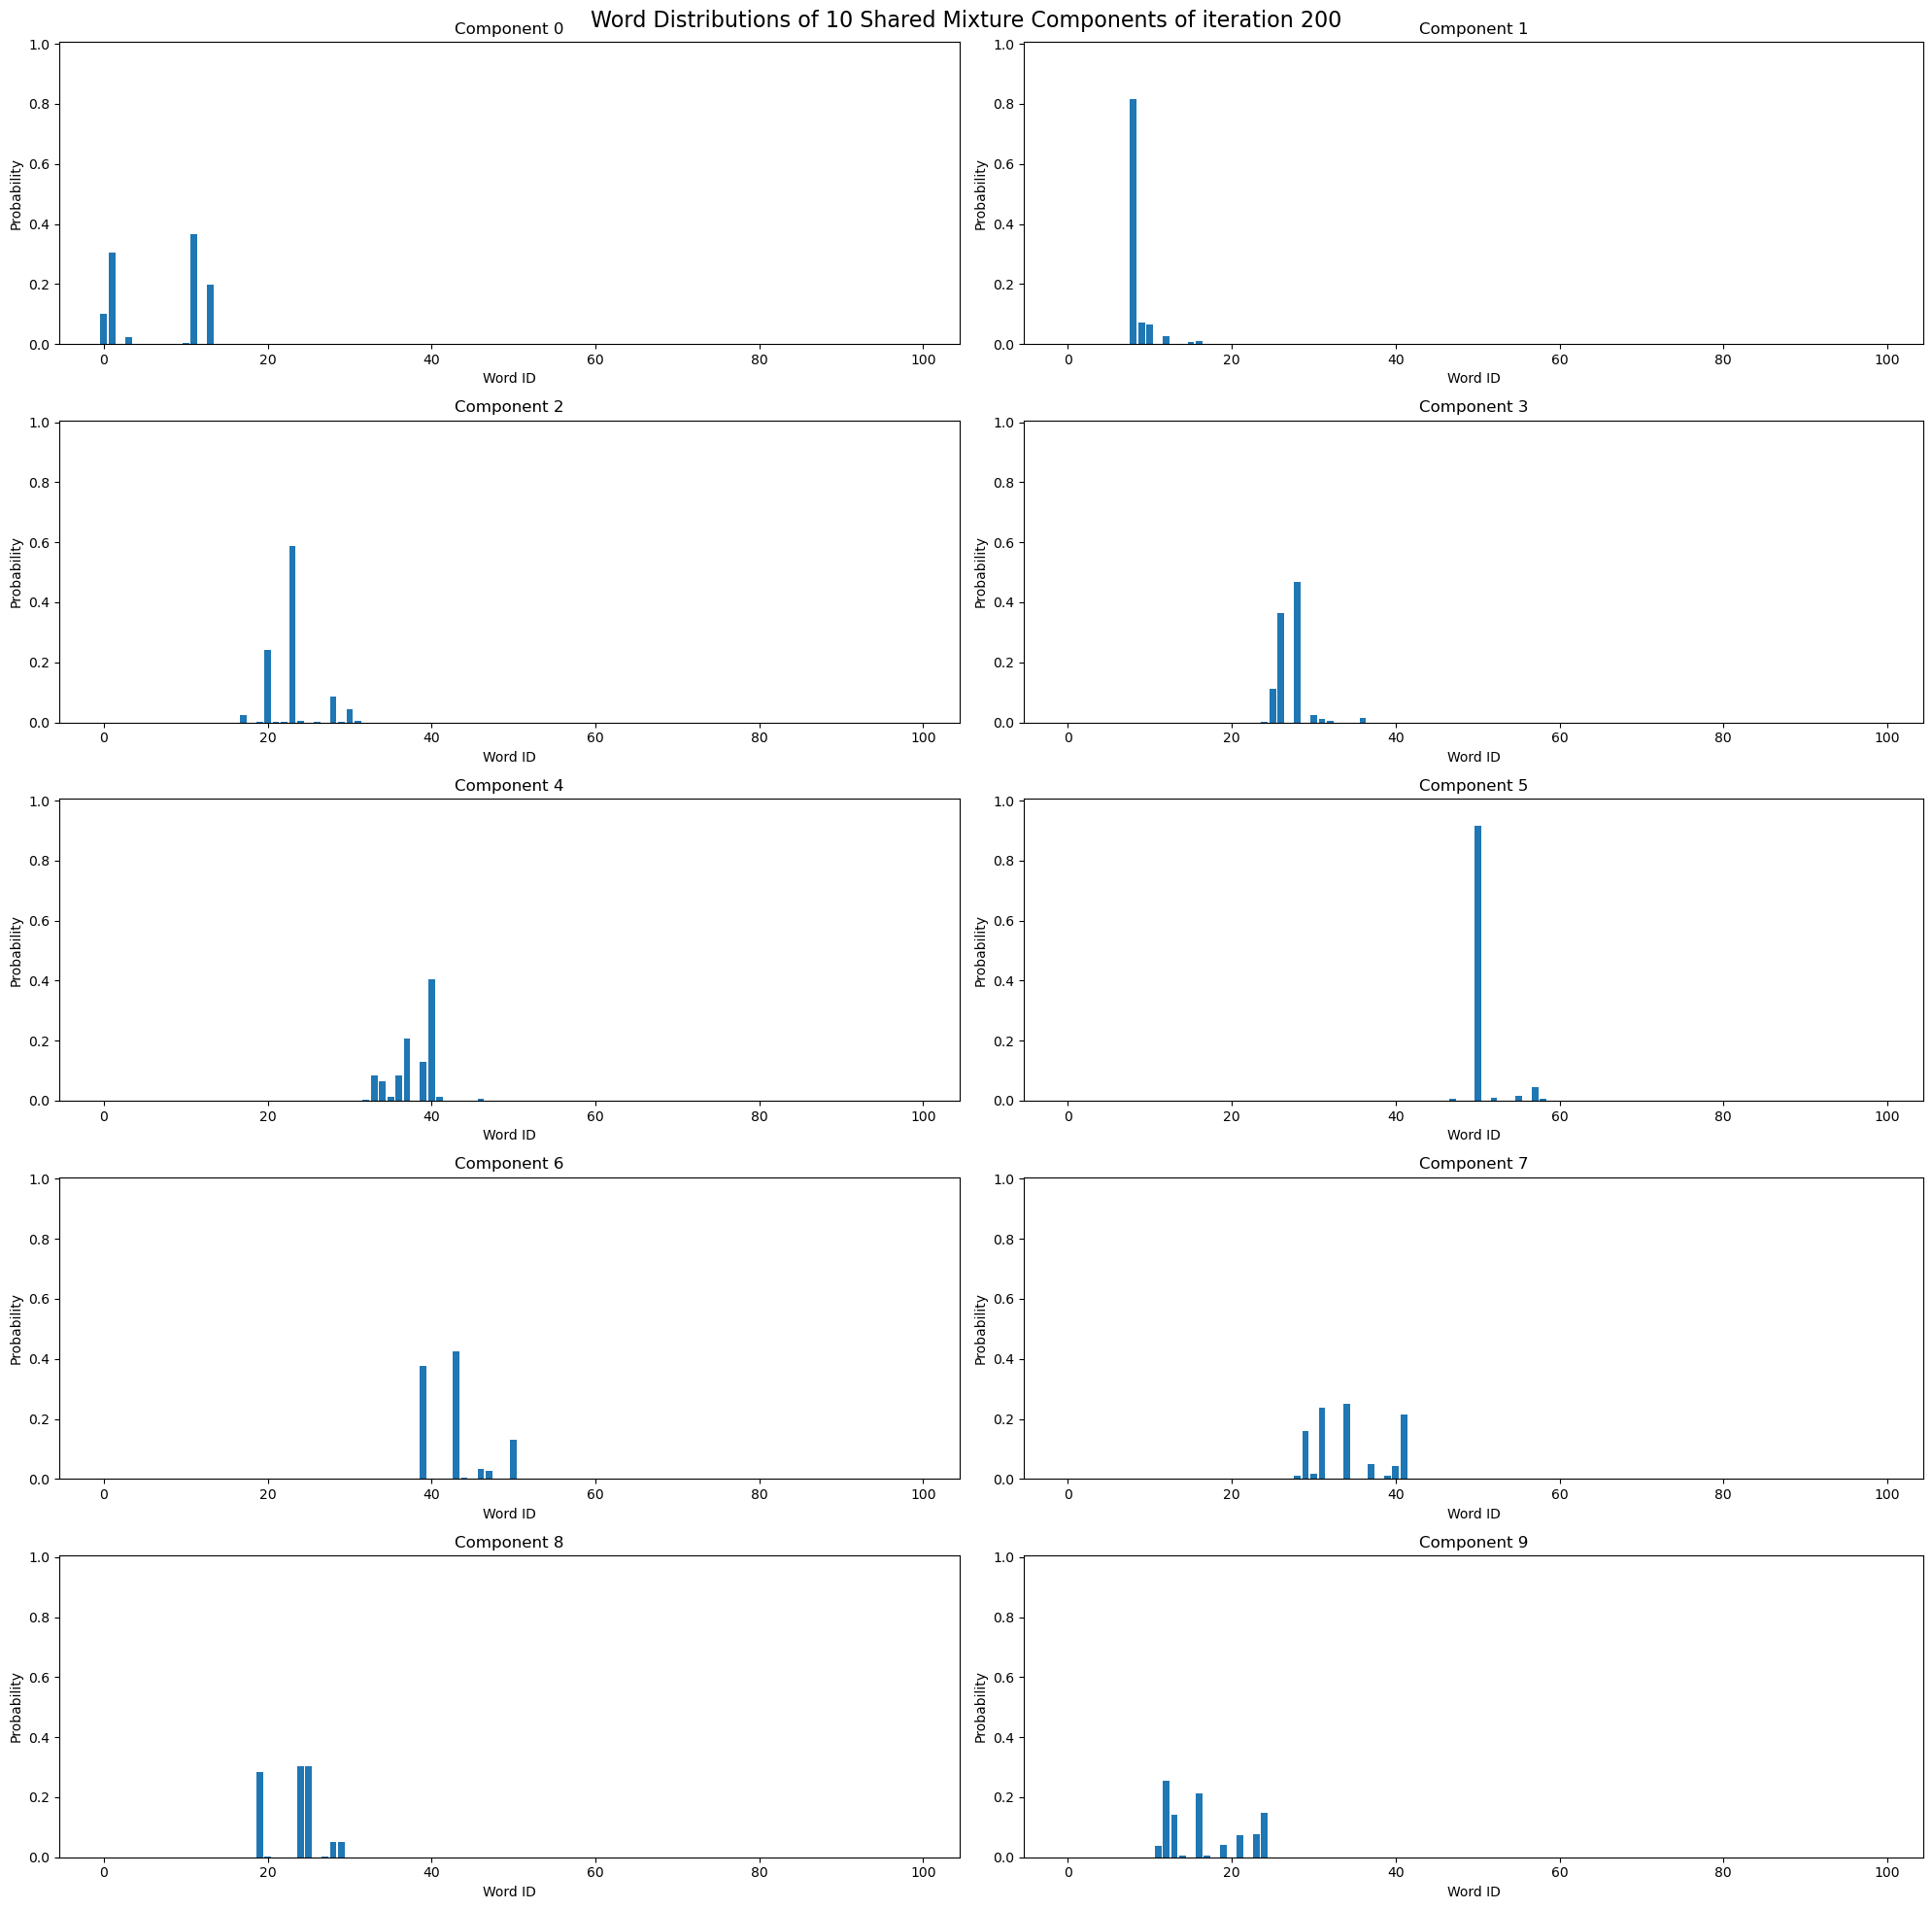

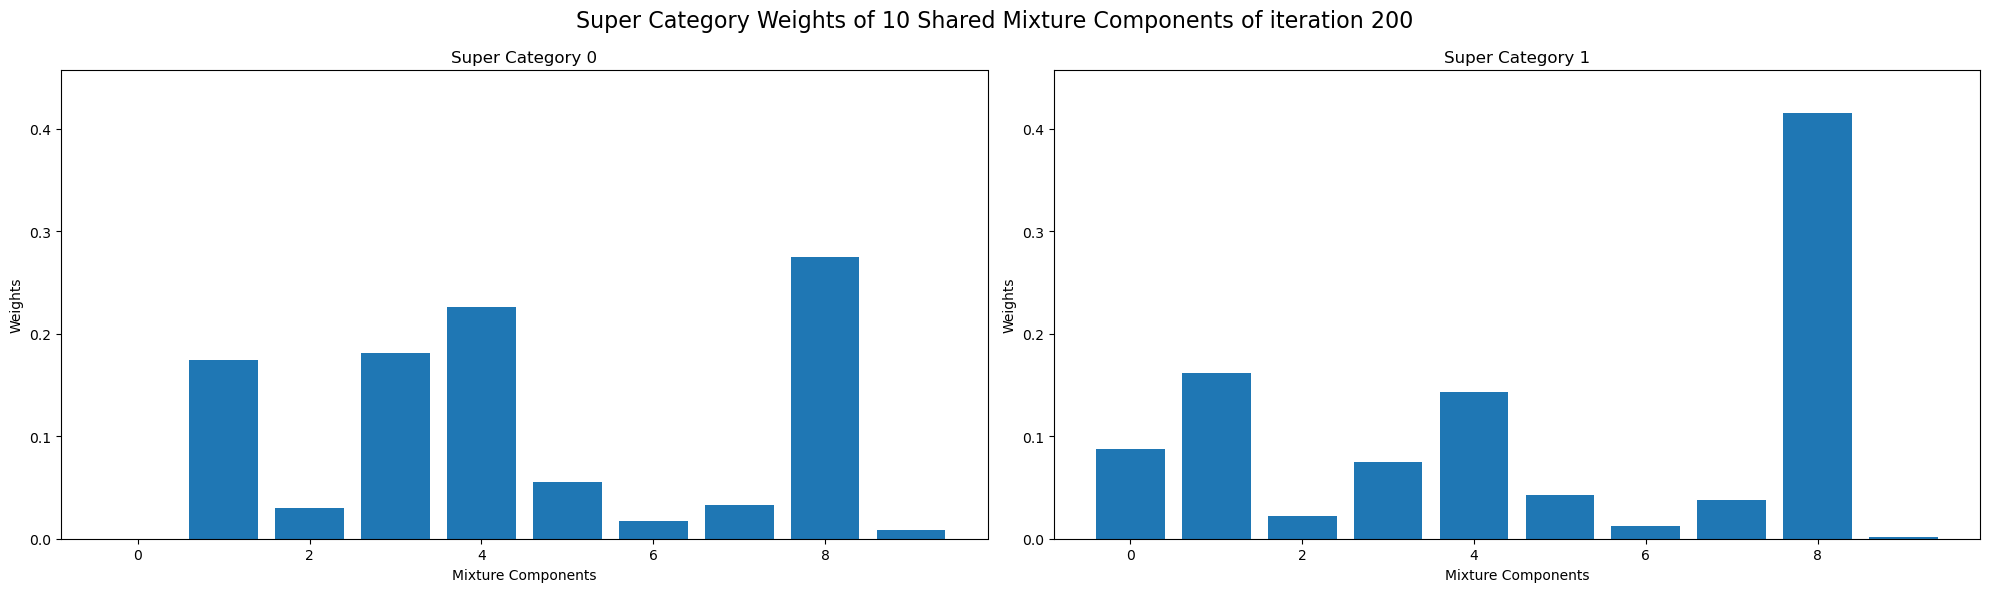

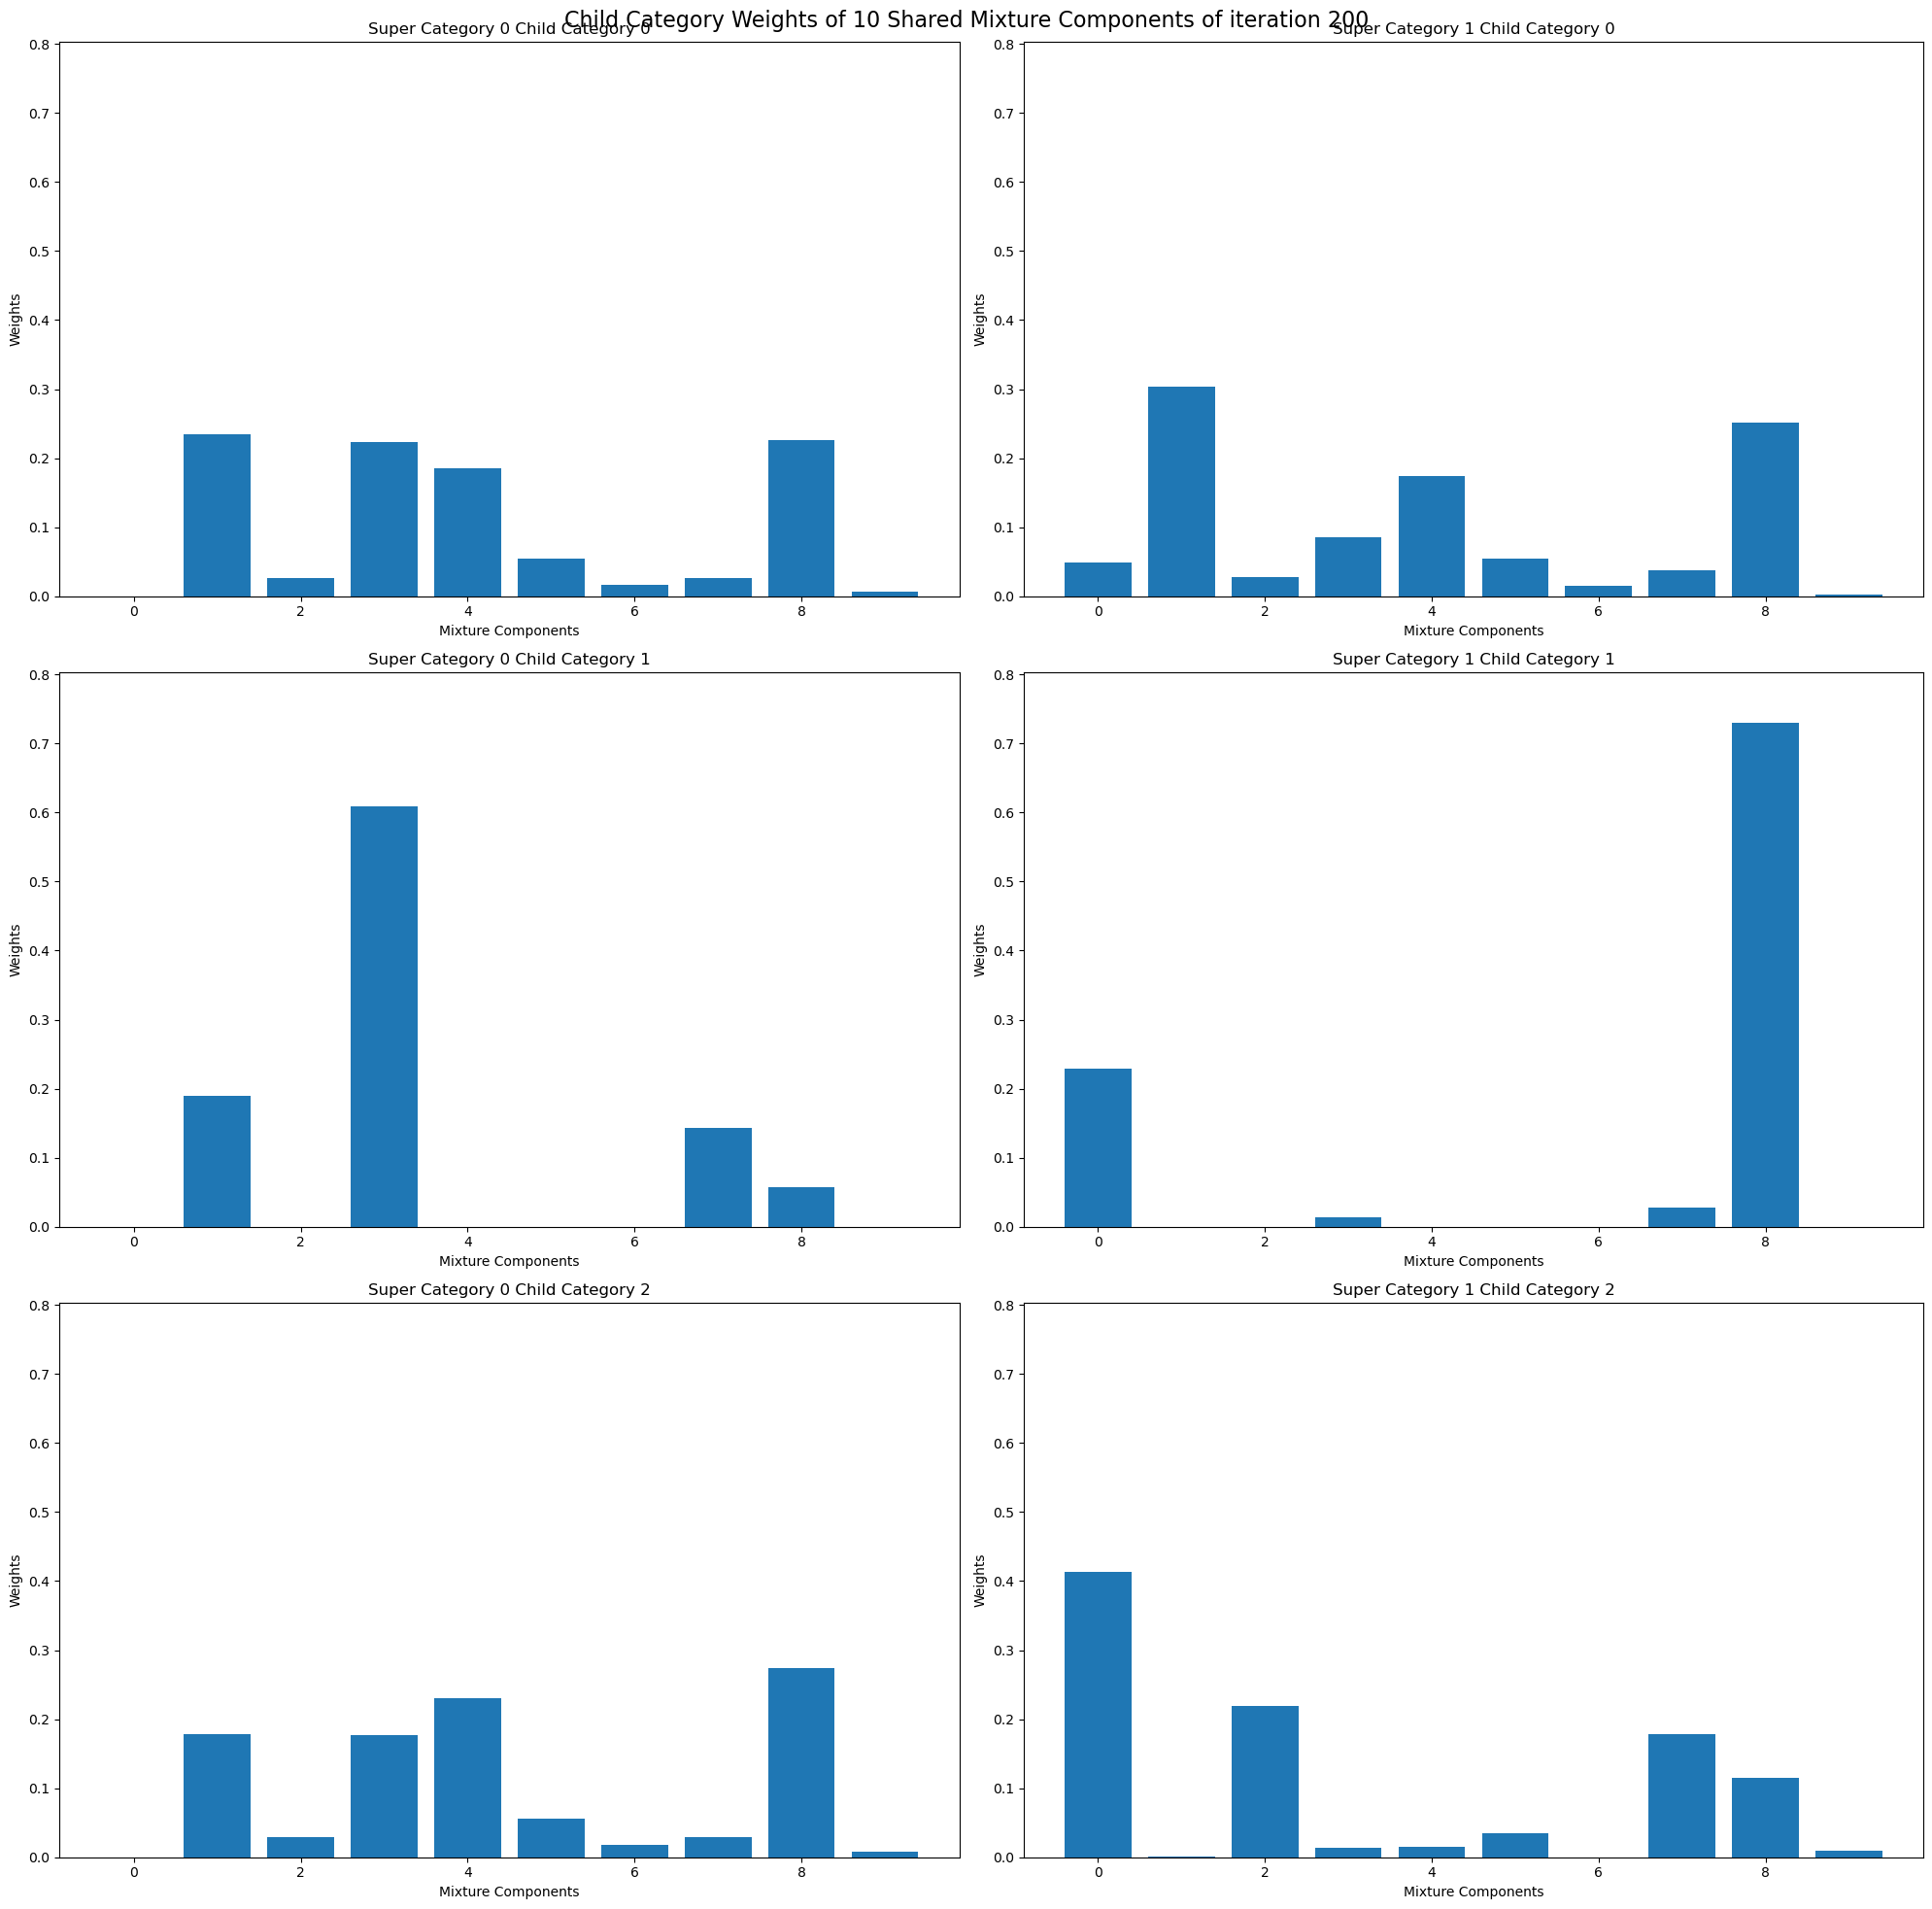

Gibbs Sampling:  50%|█████     | 250/500 [4:00:51<3:48:34, 54.86s/it]

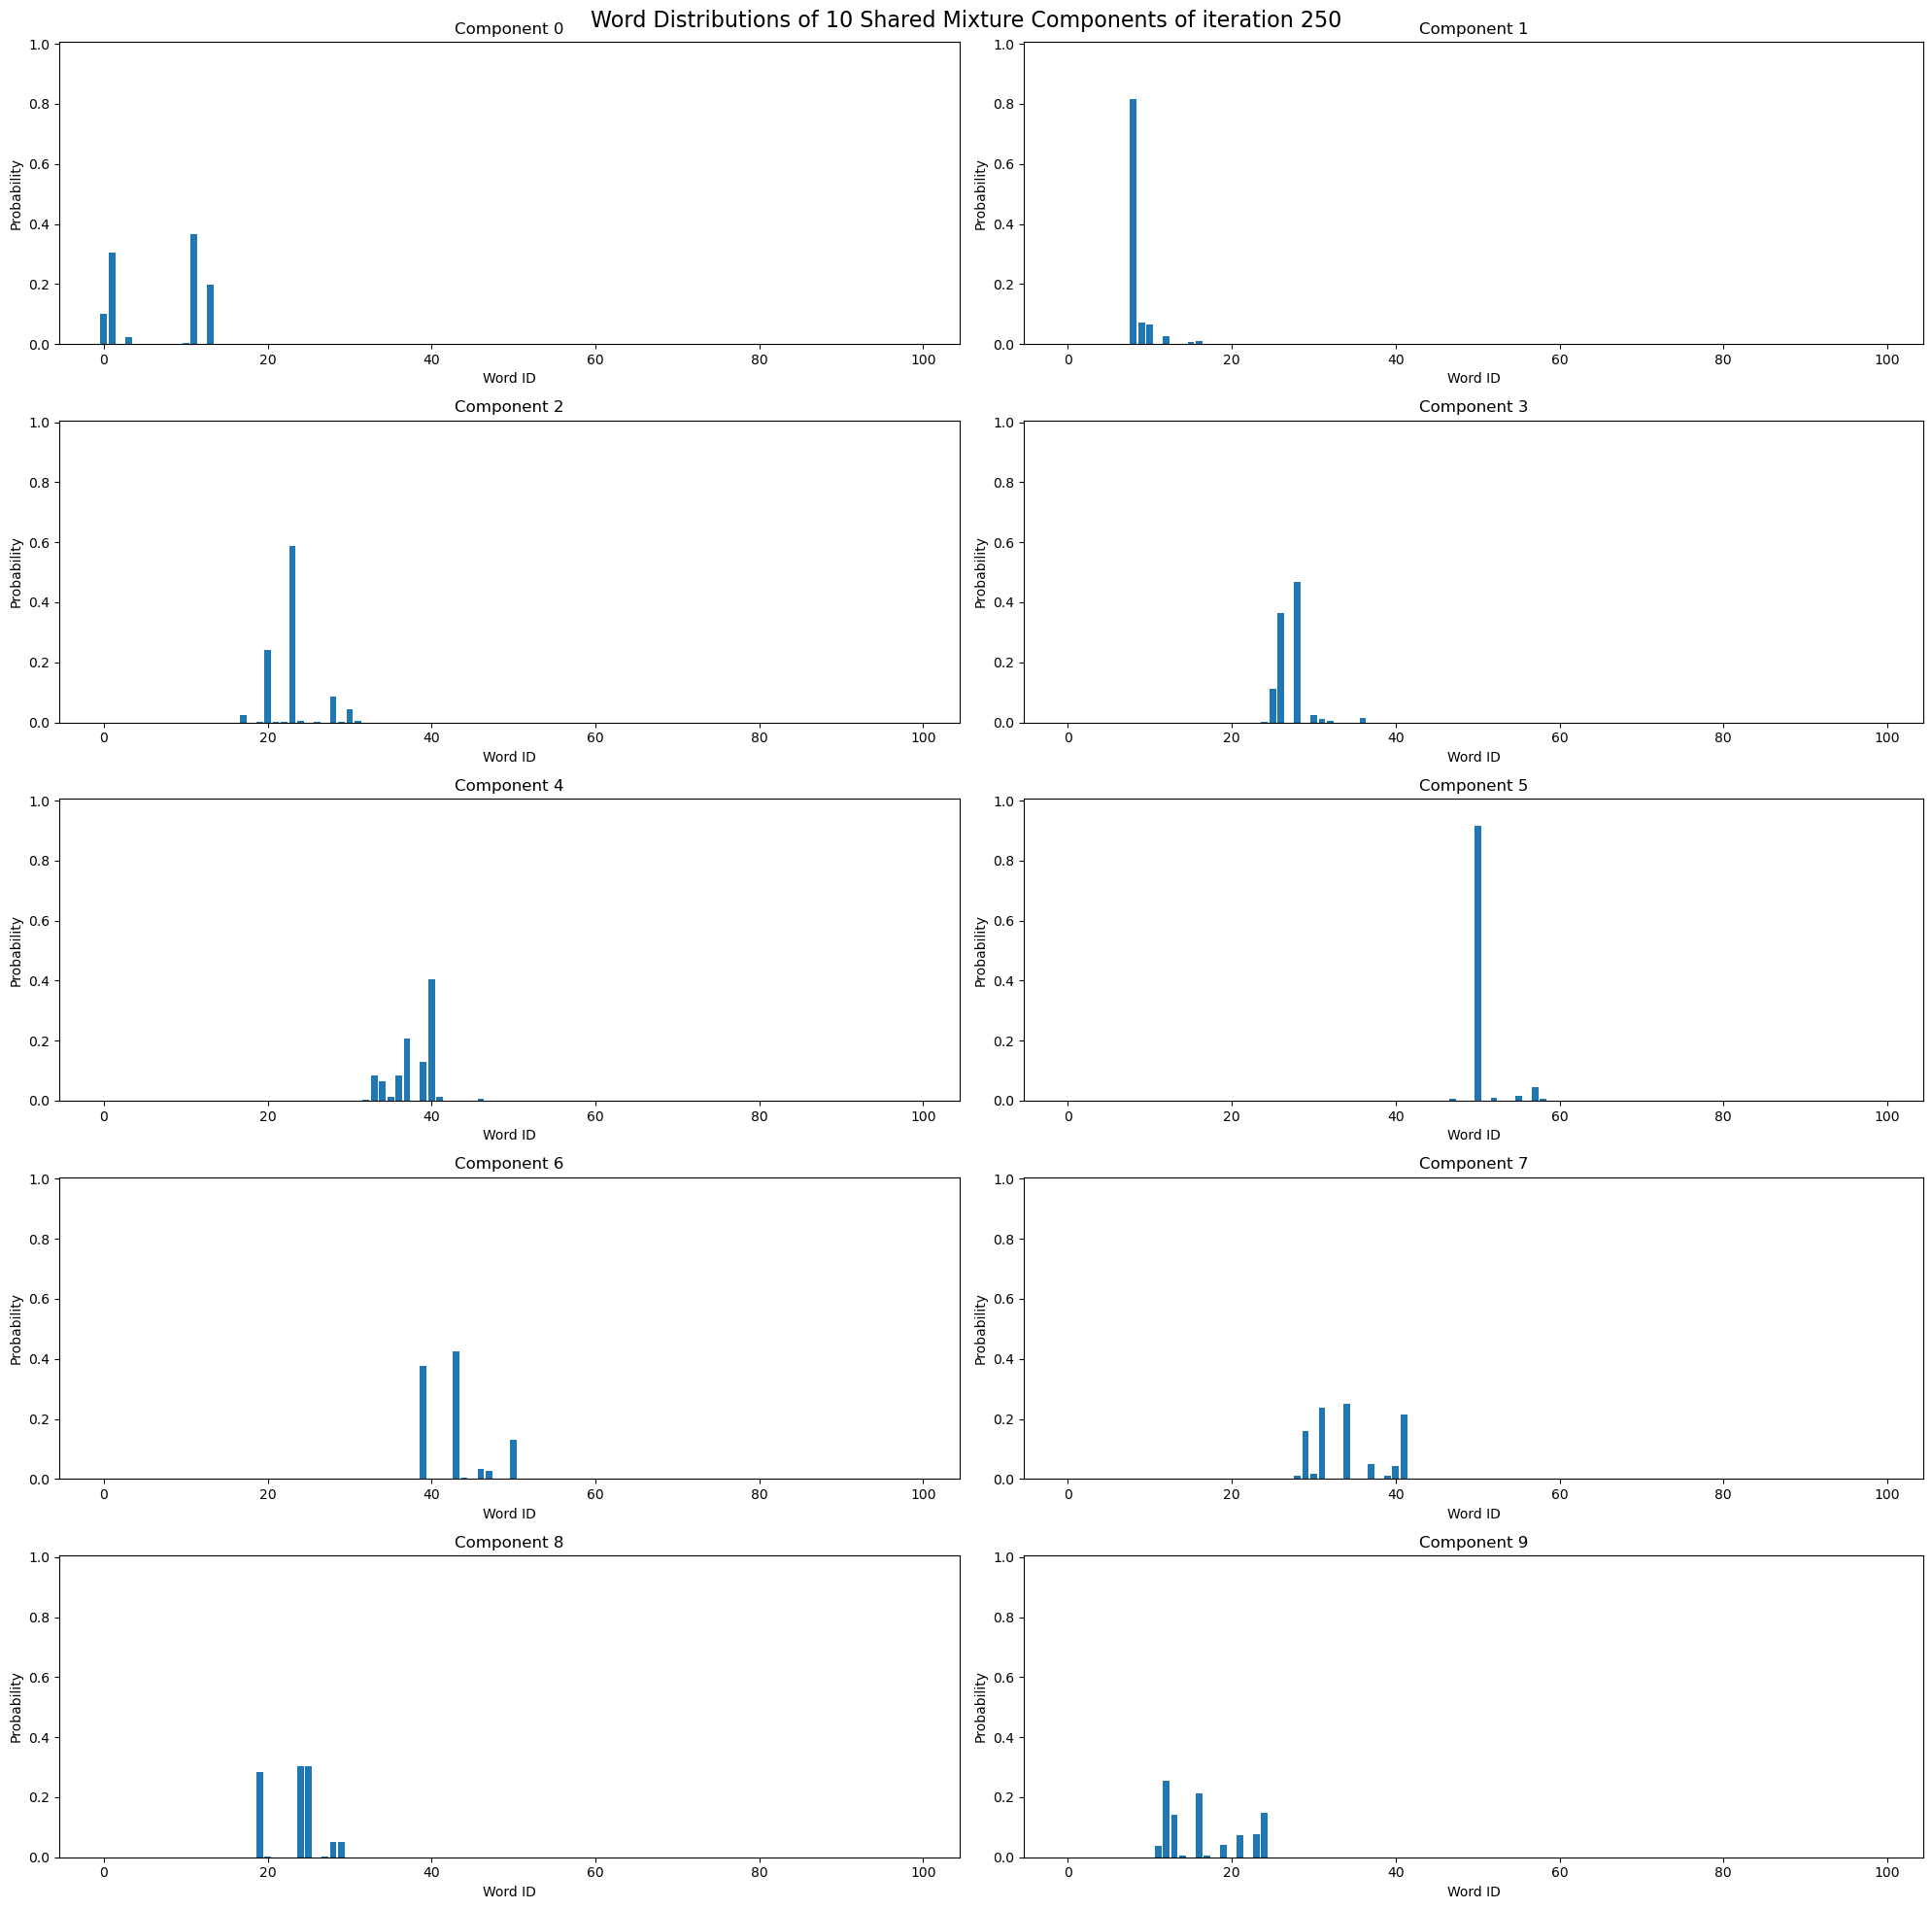

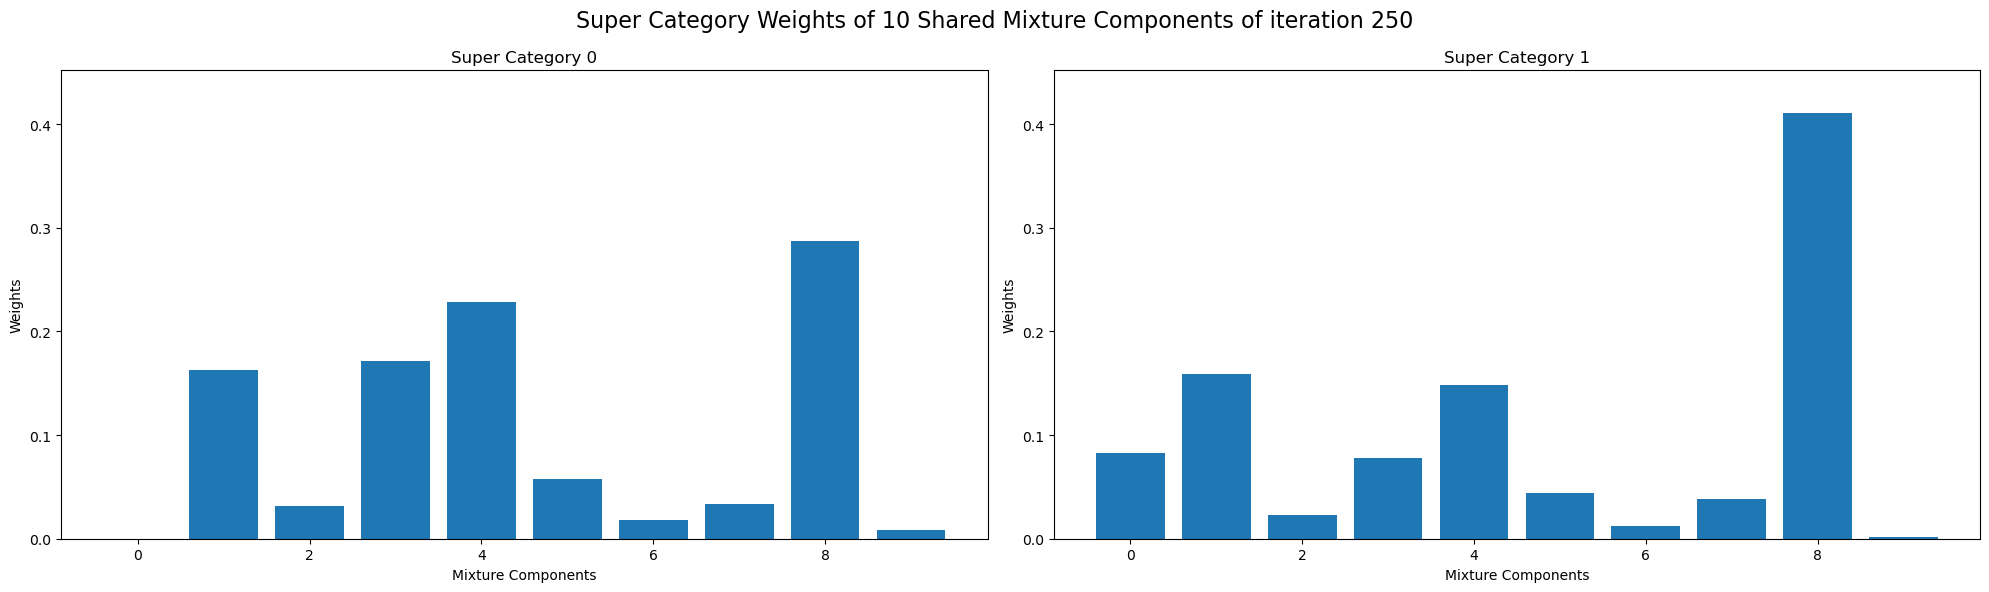

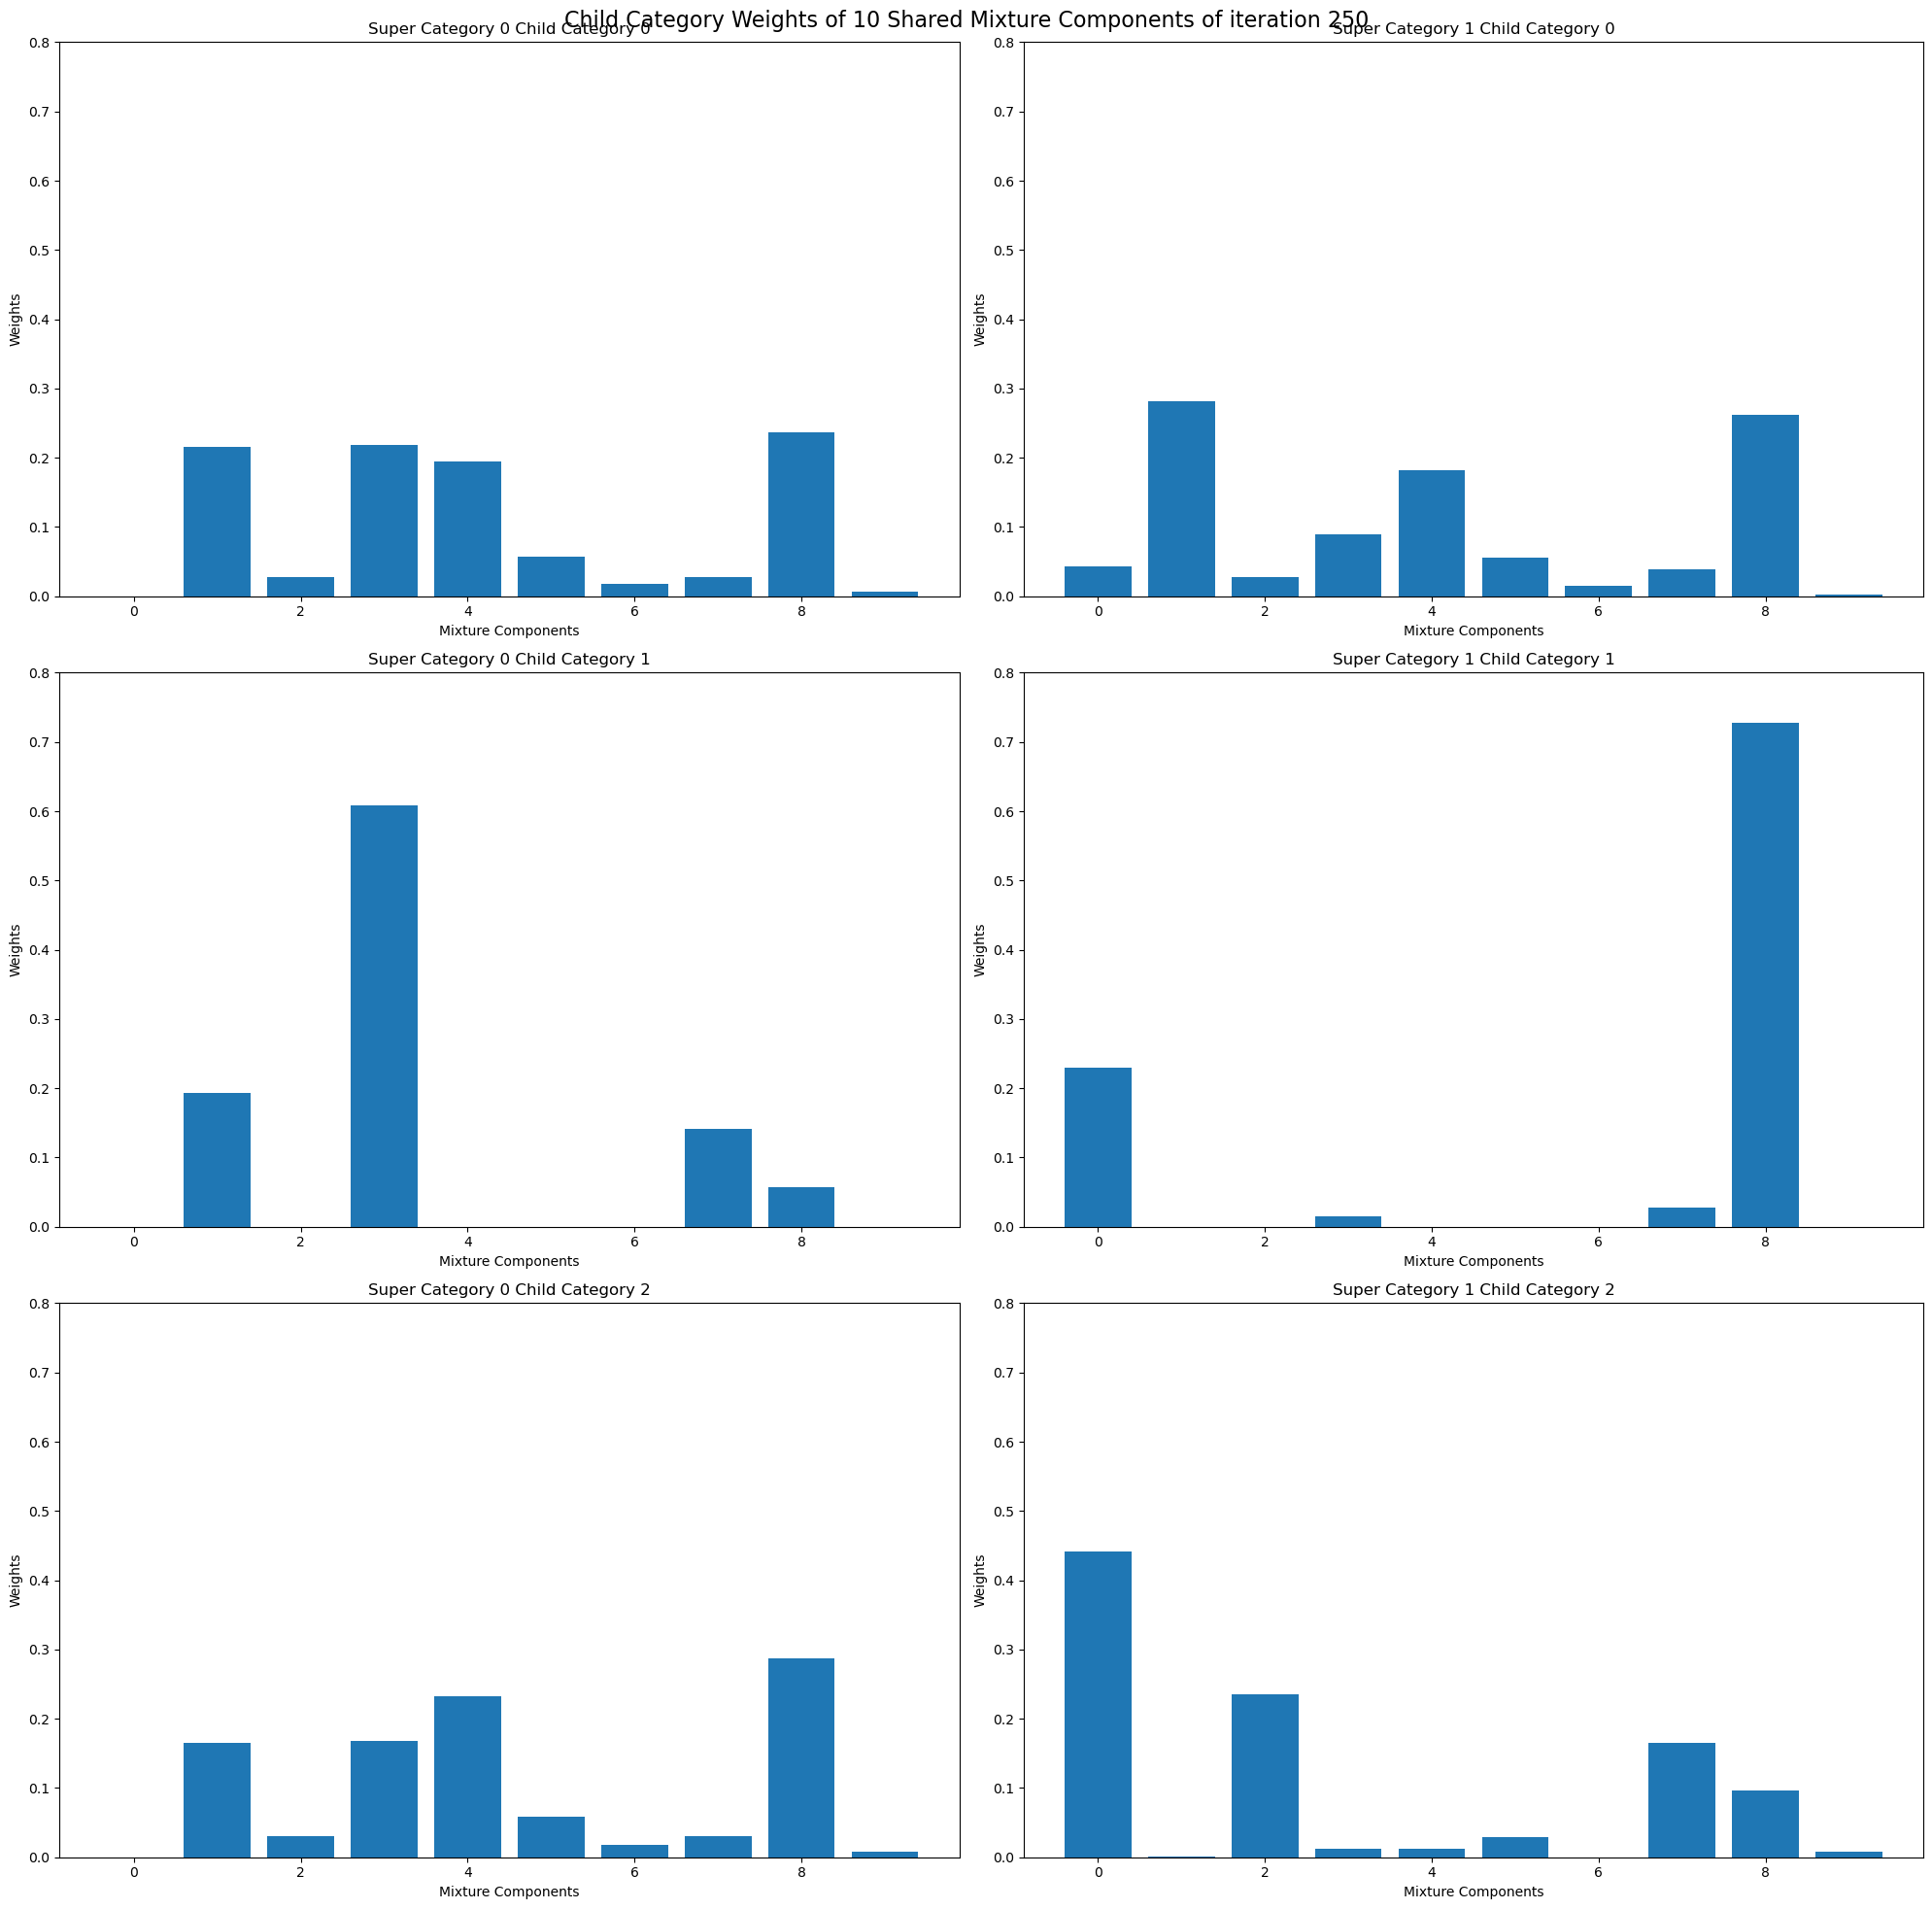

Gibbs Sampling:  60%|██████    | 300/500 [4:46:36<3:02:42, 54.81s/it]

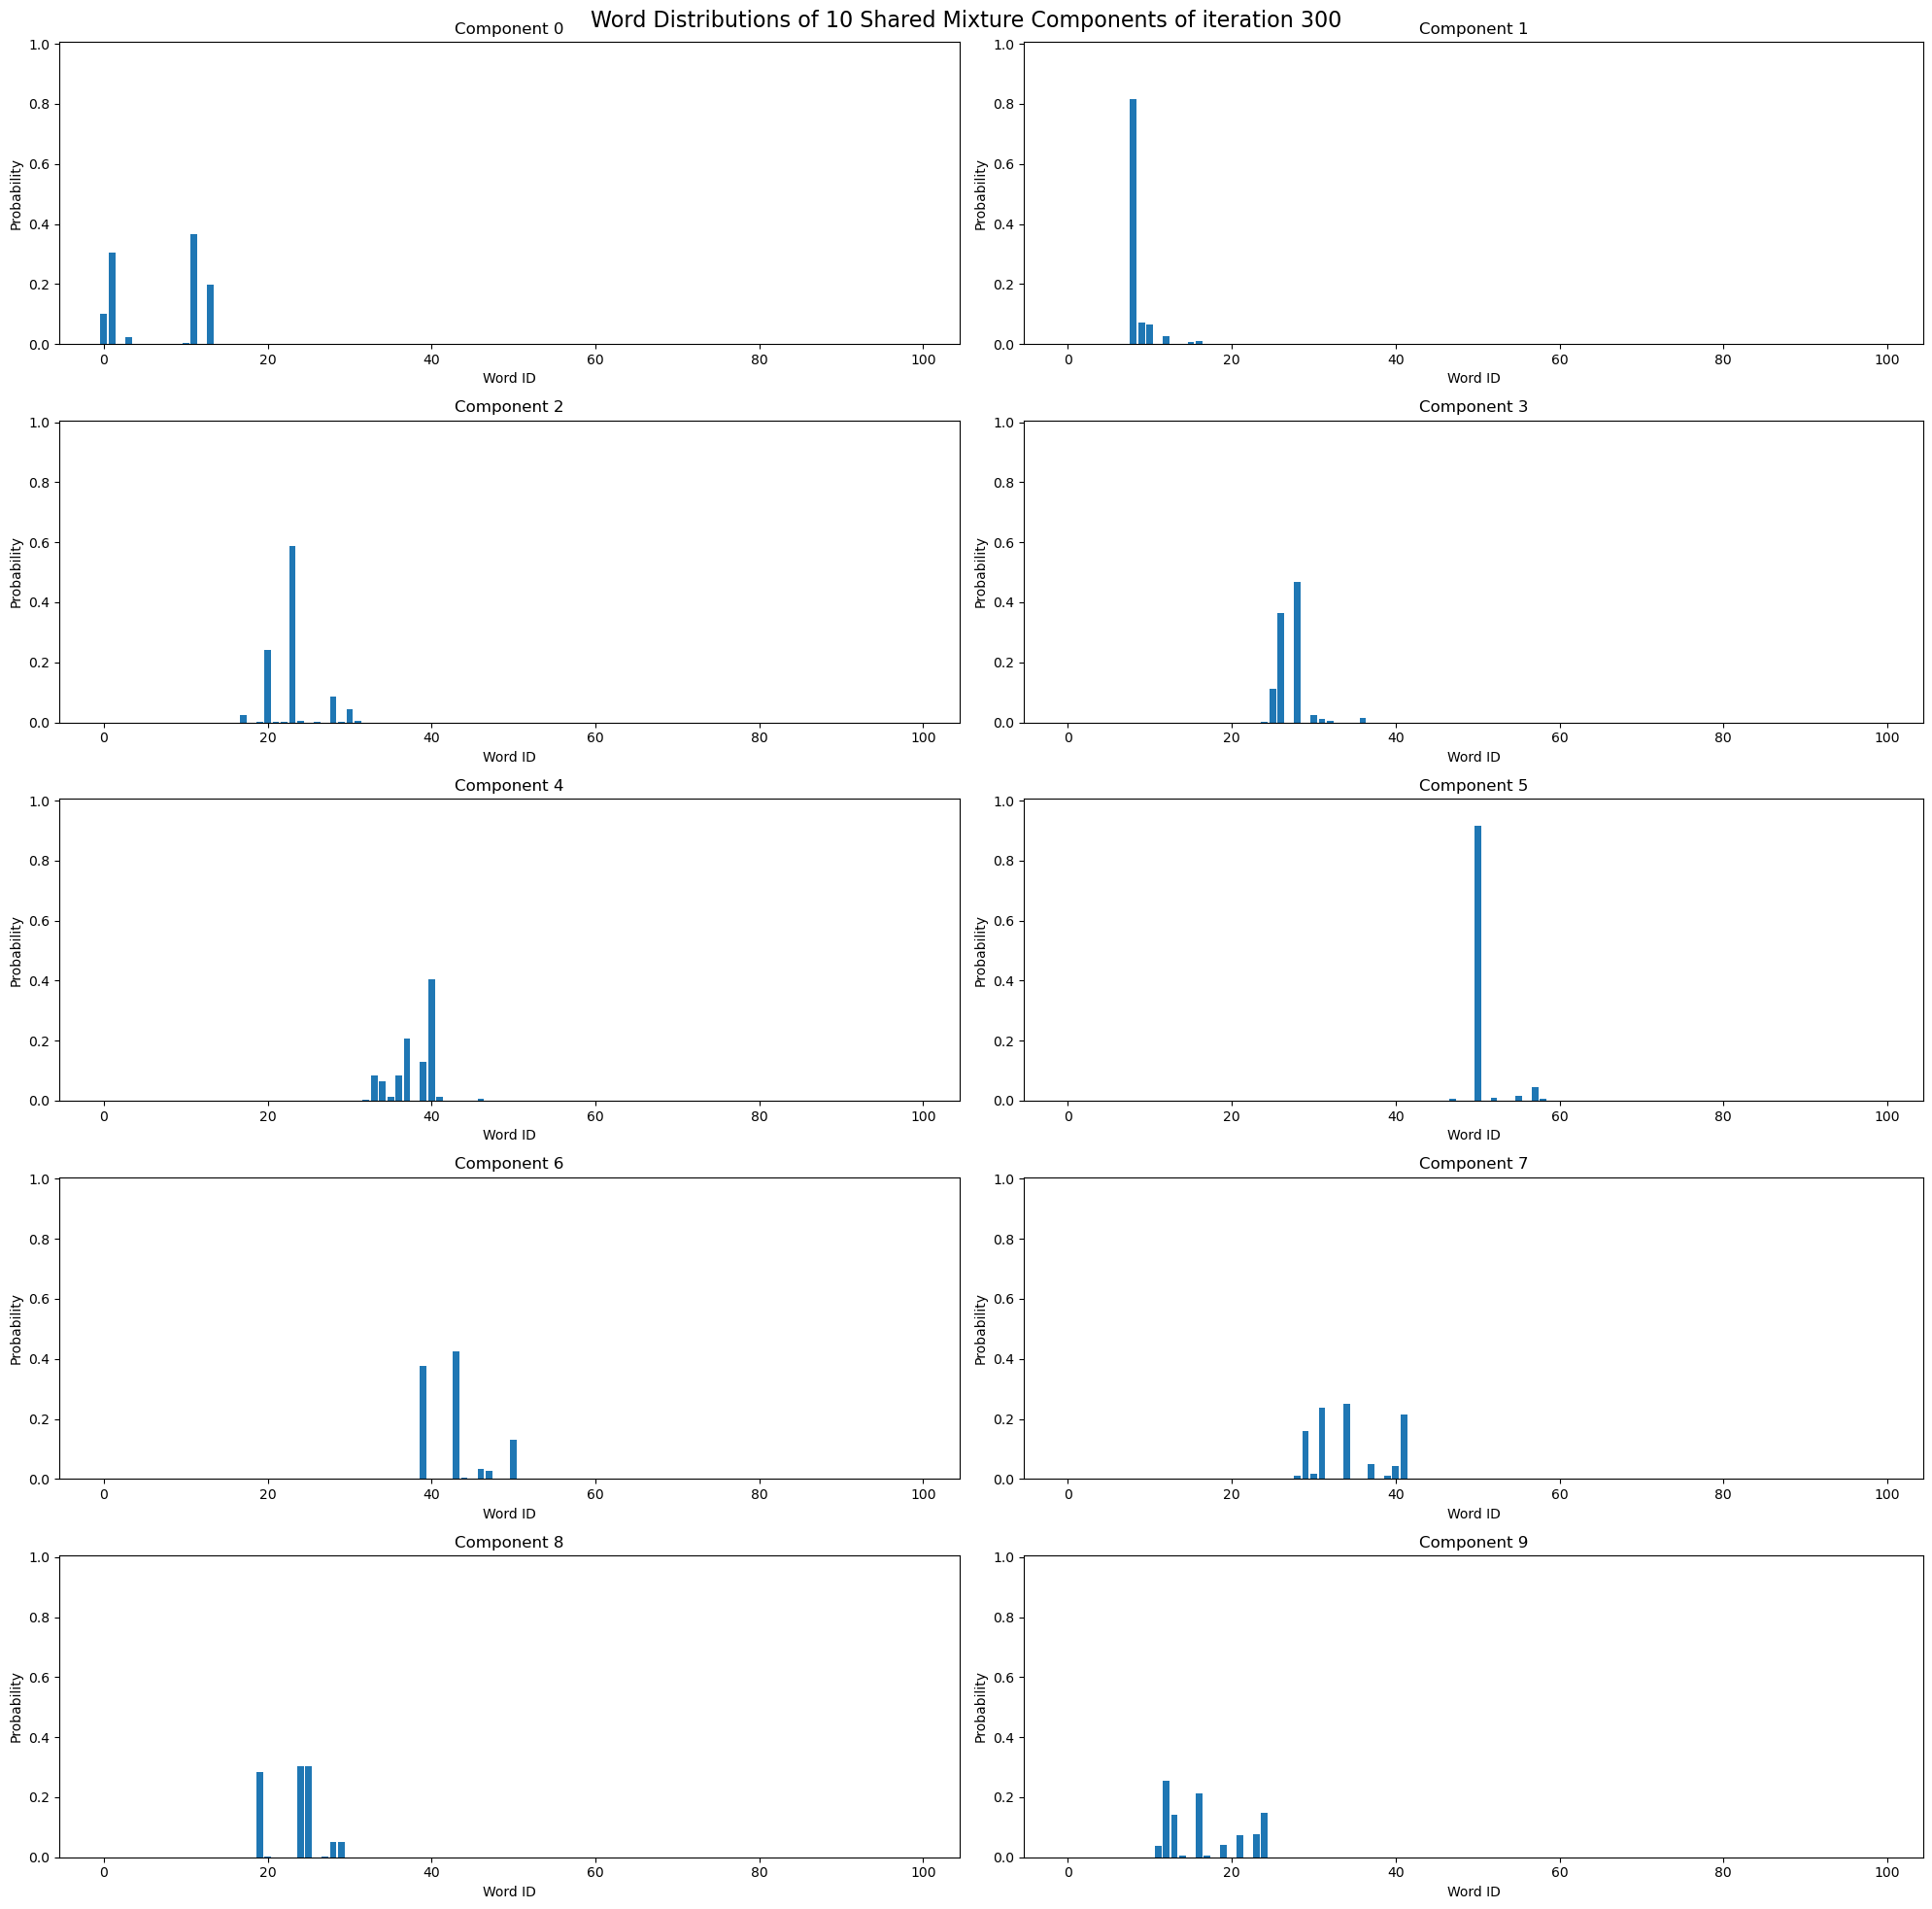

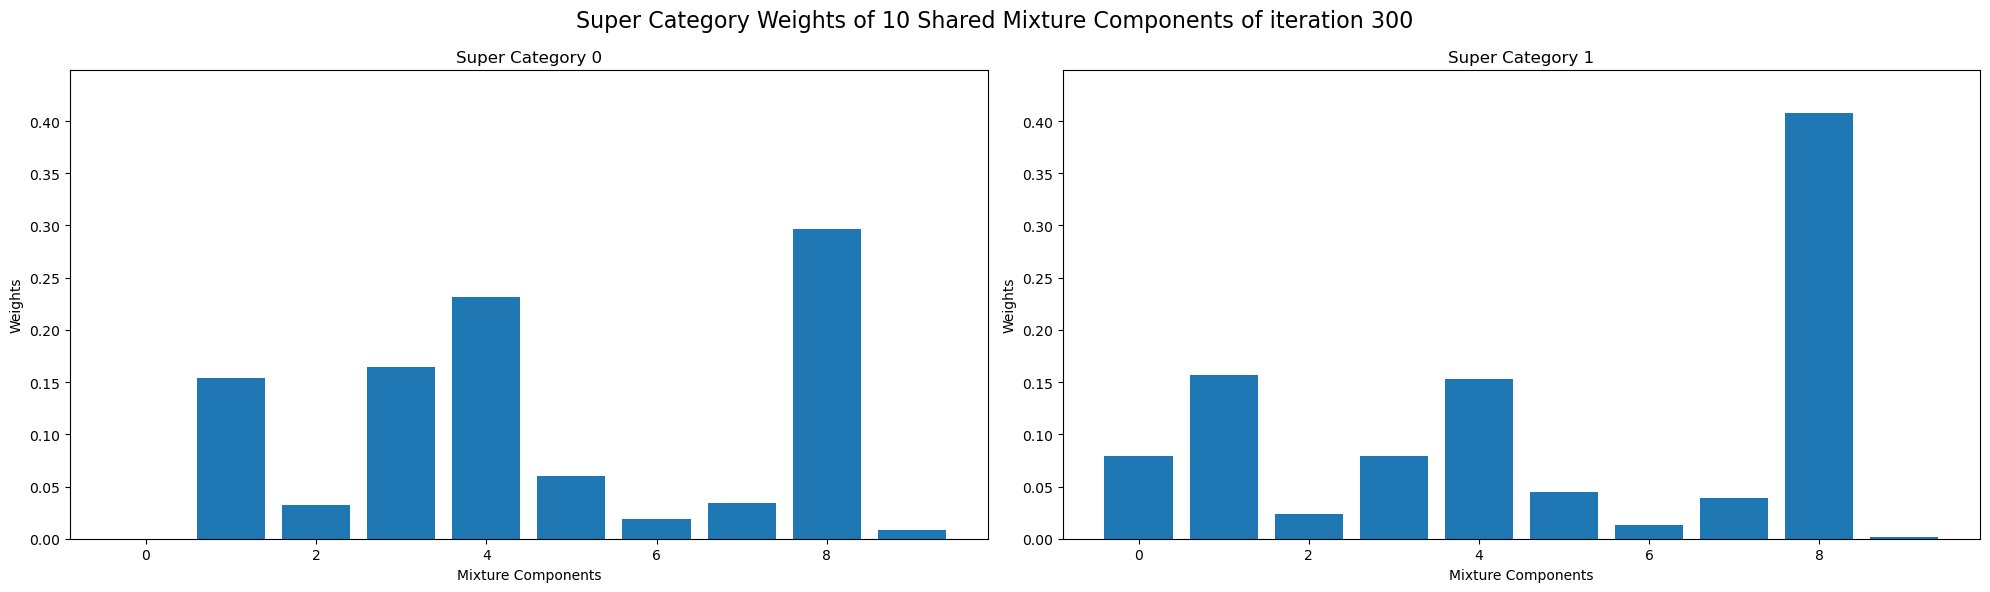

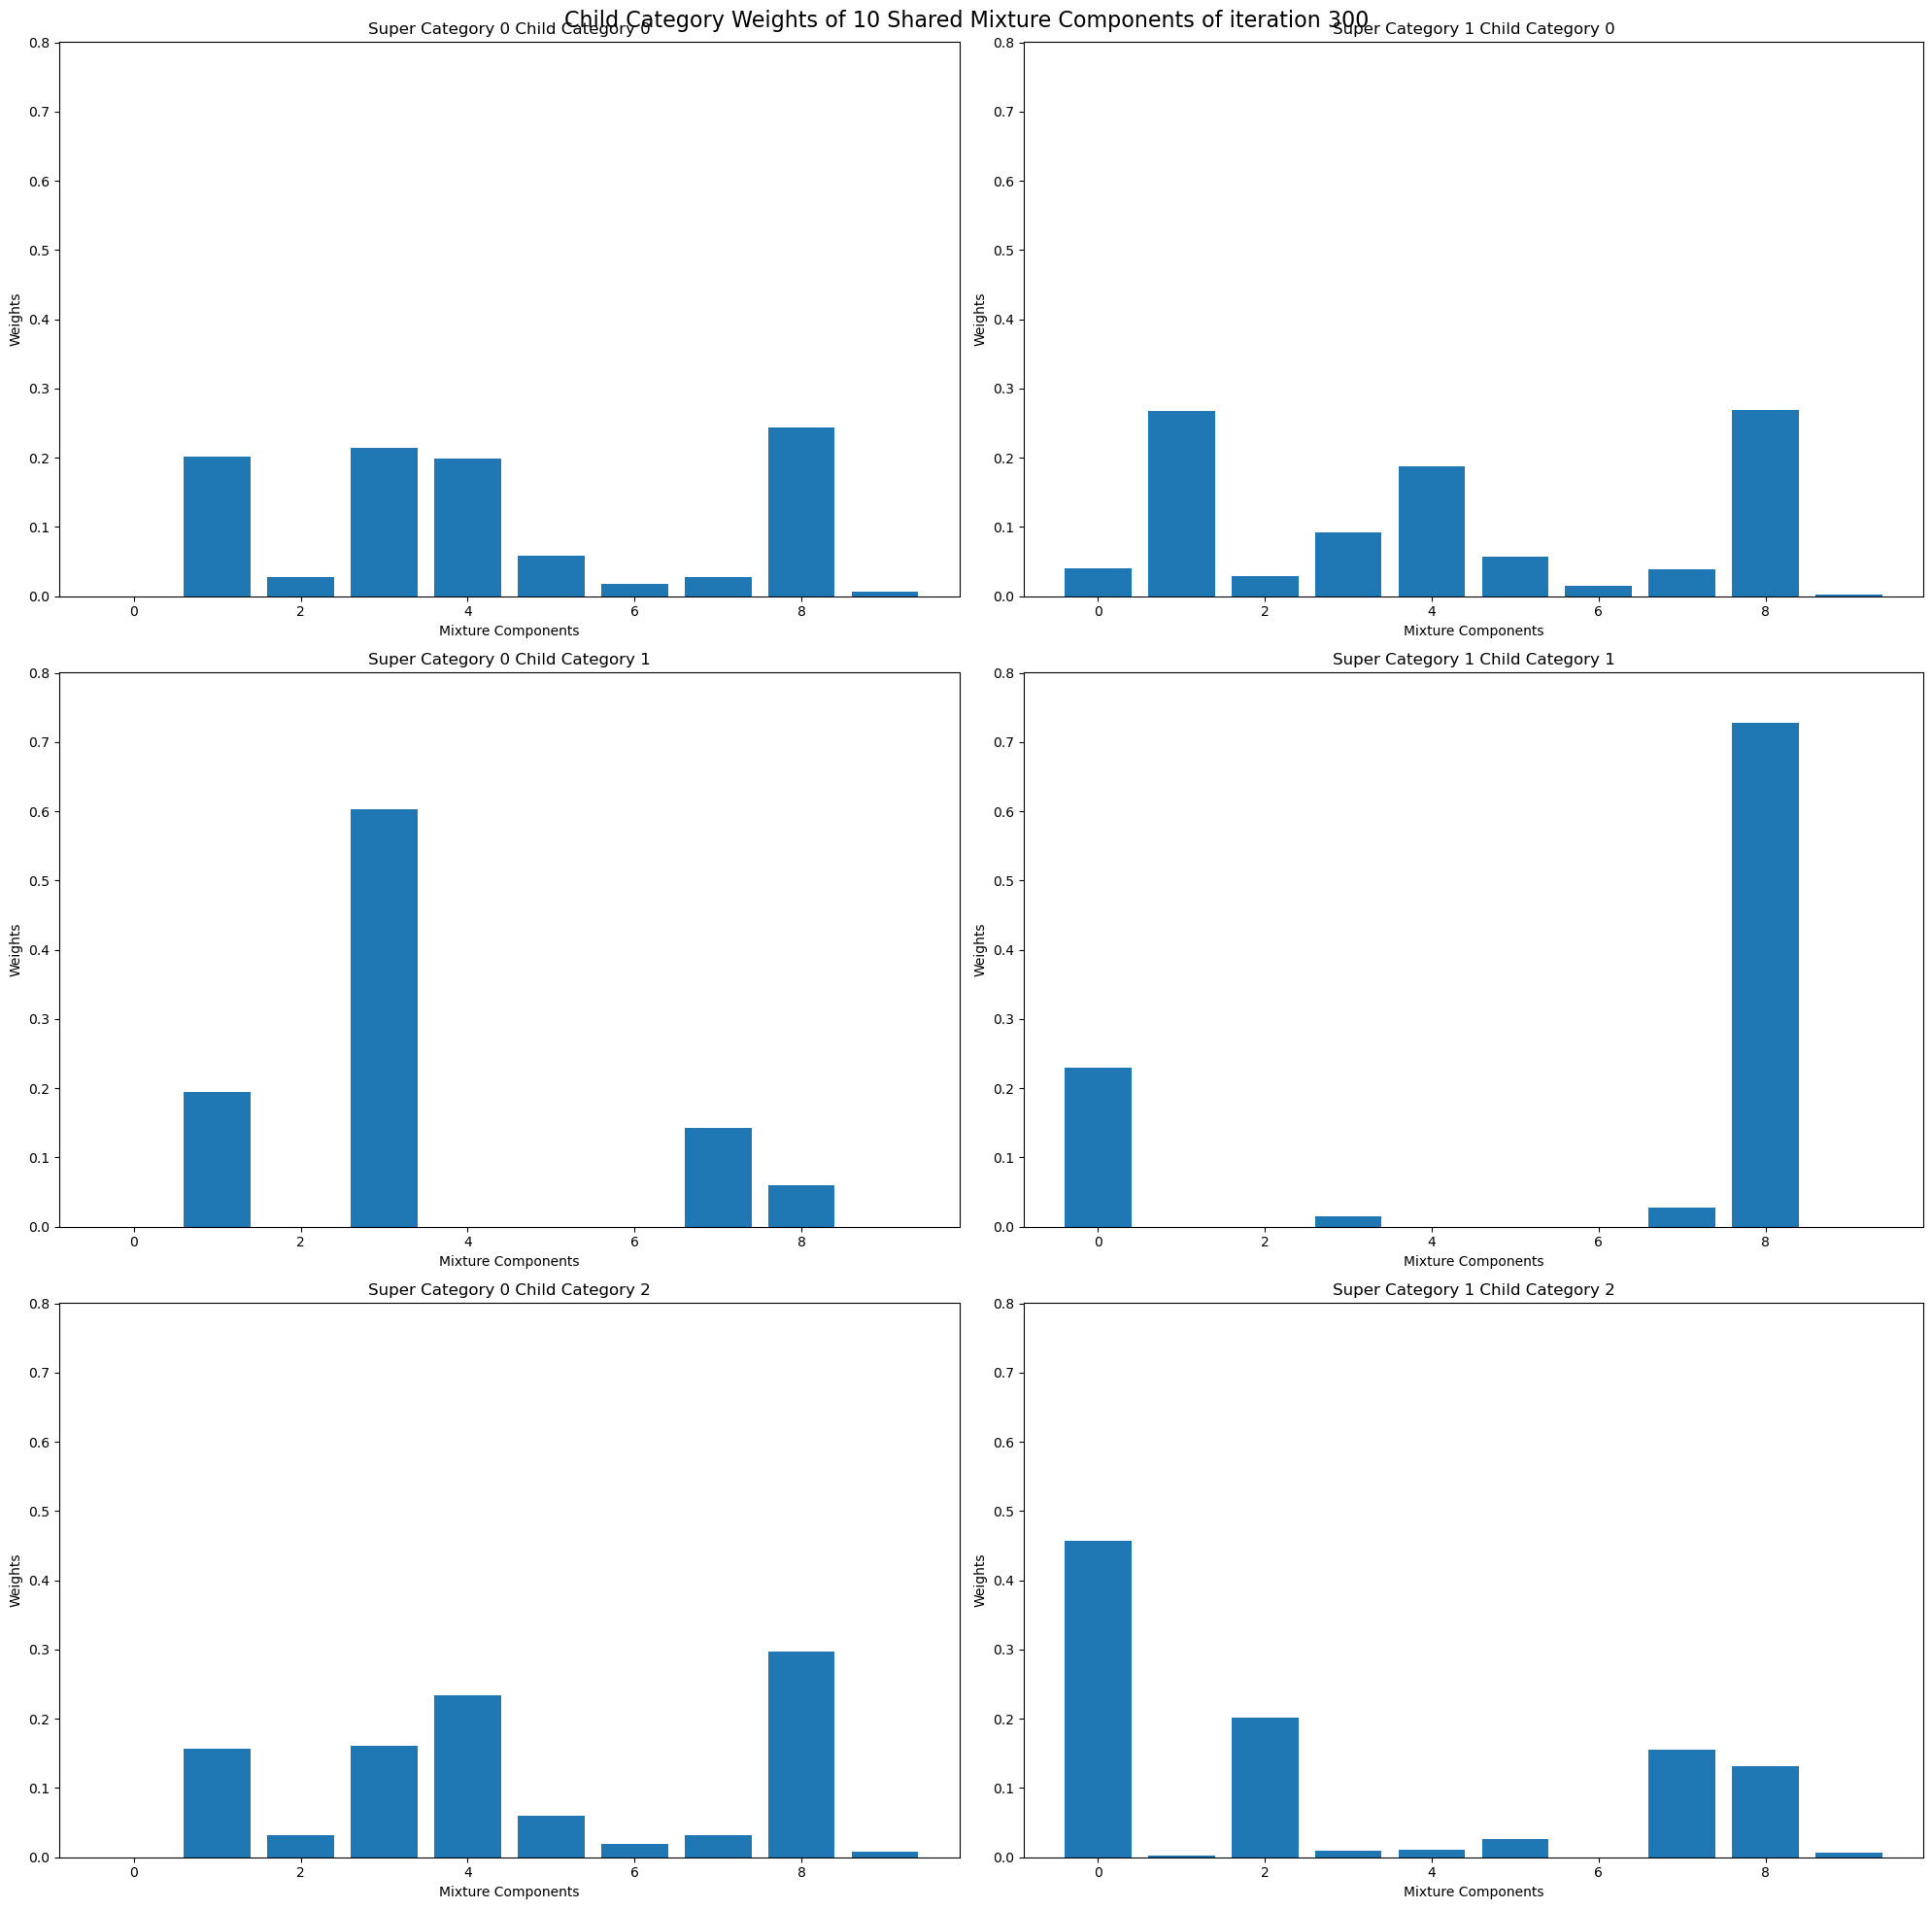

Gibbs Sampling:  70%|███████   | 350/500 [5:32:10<2:16:12, 54.48s/it]

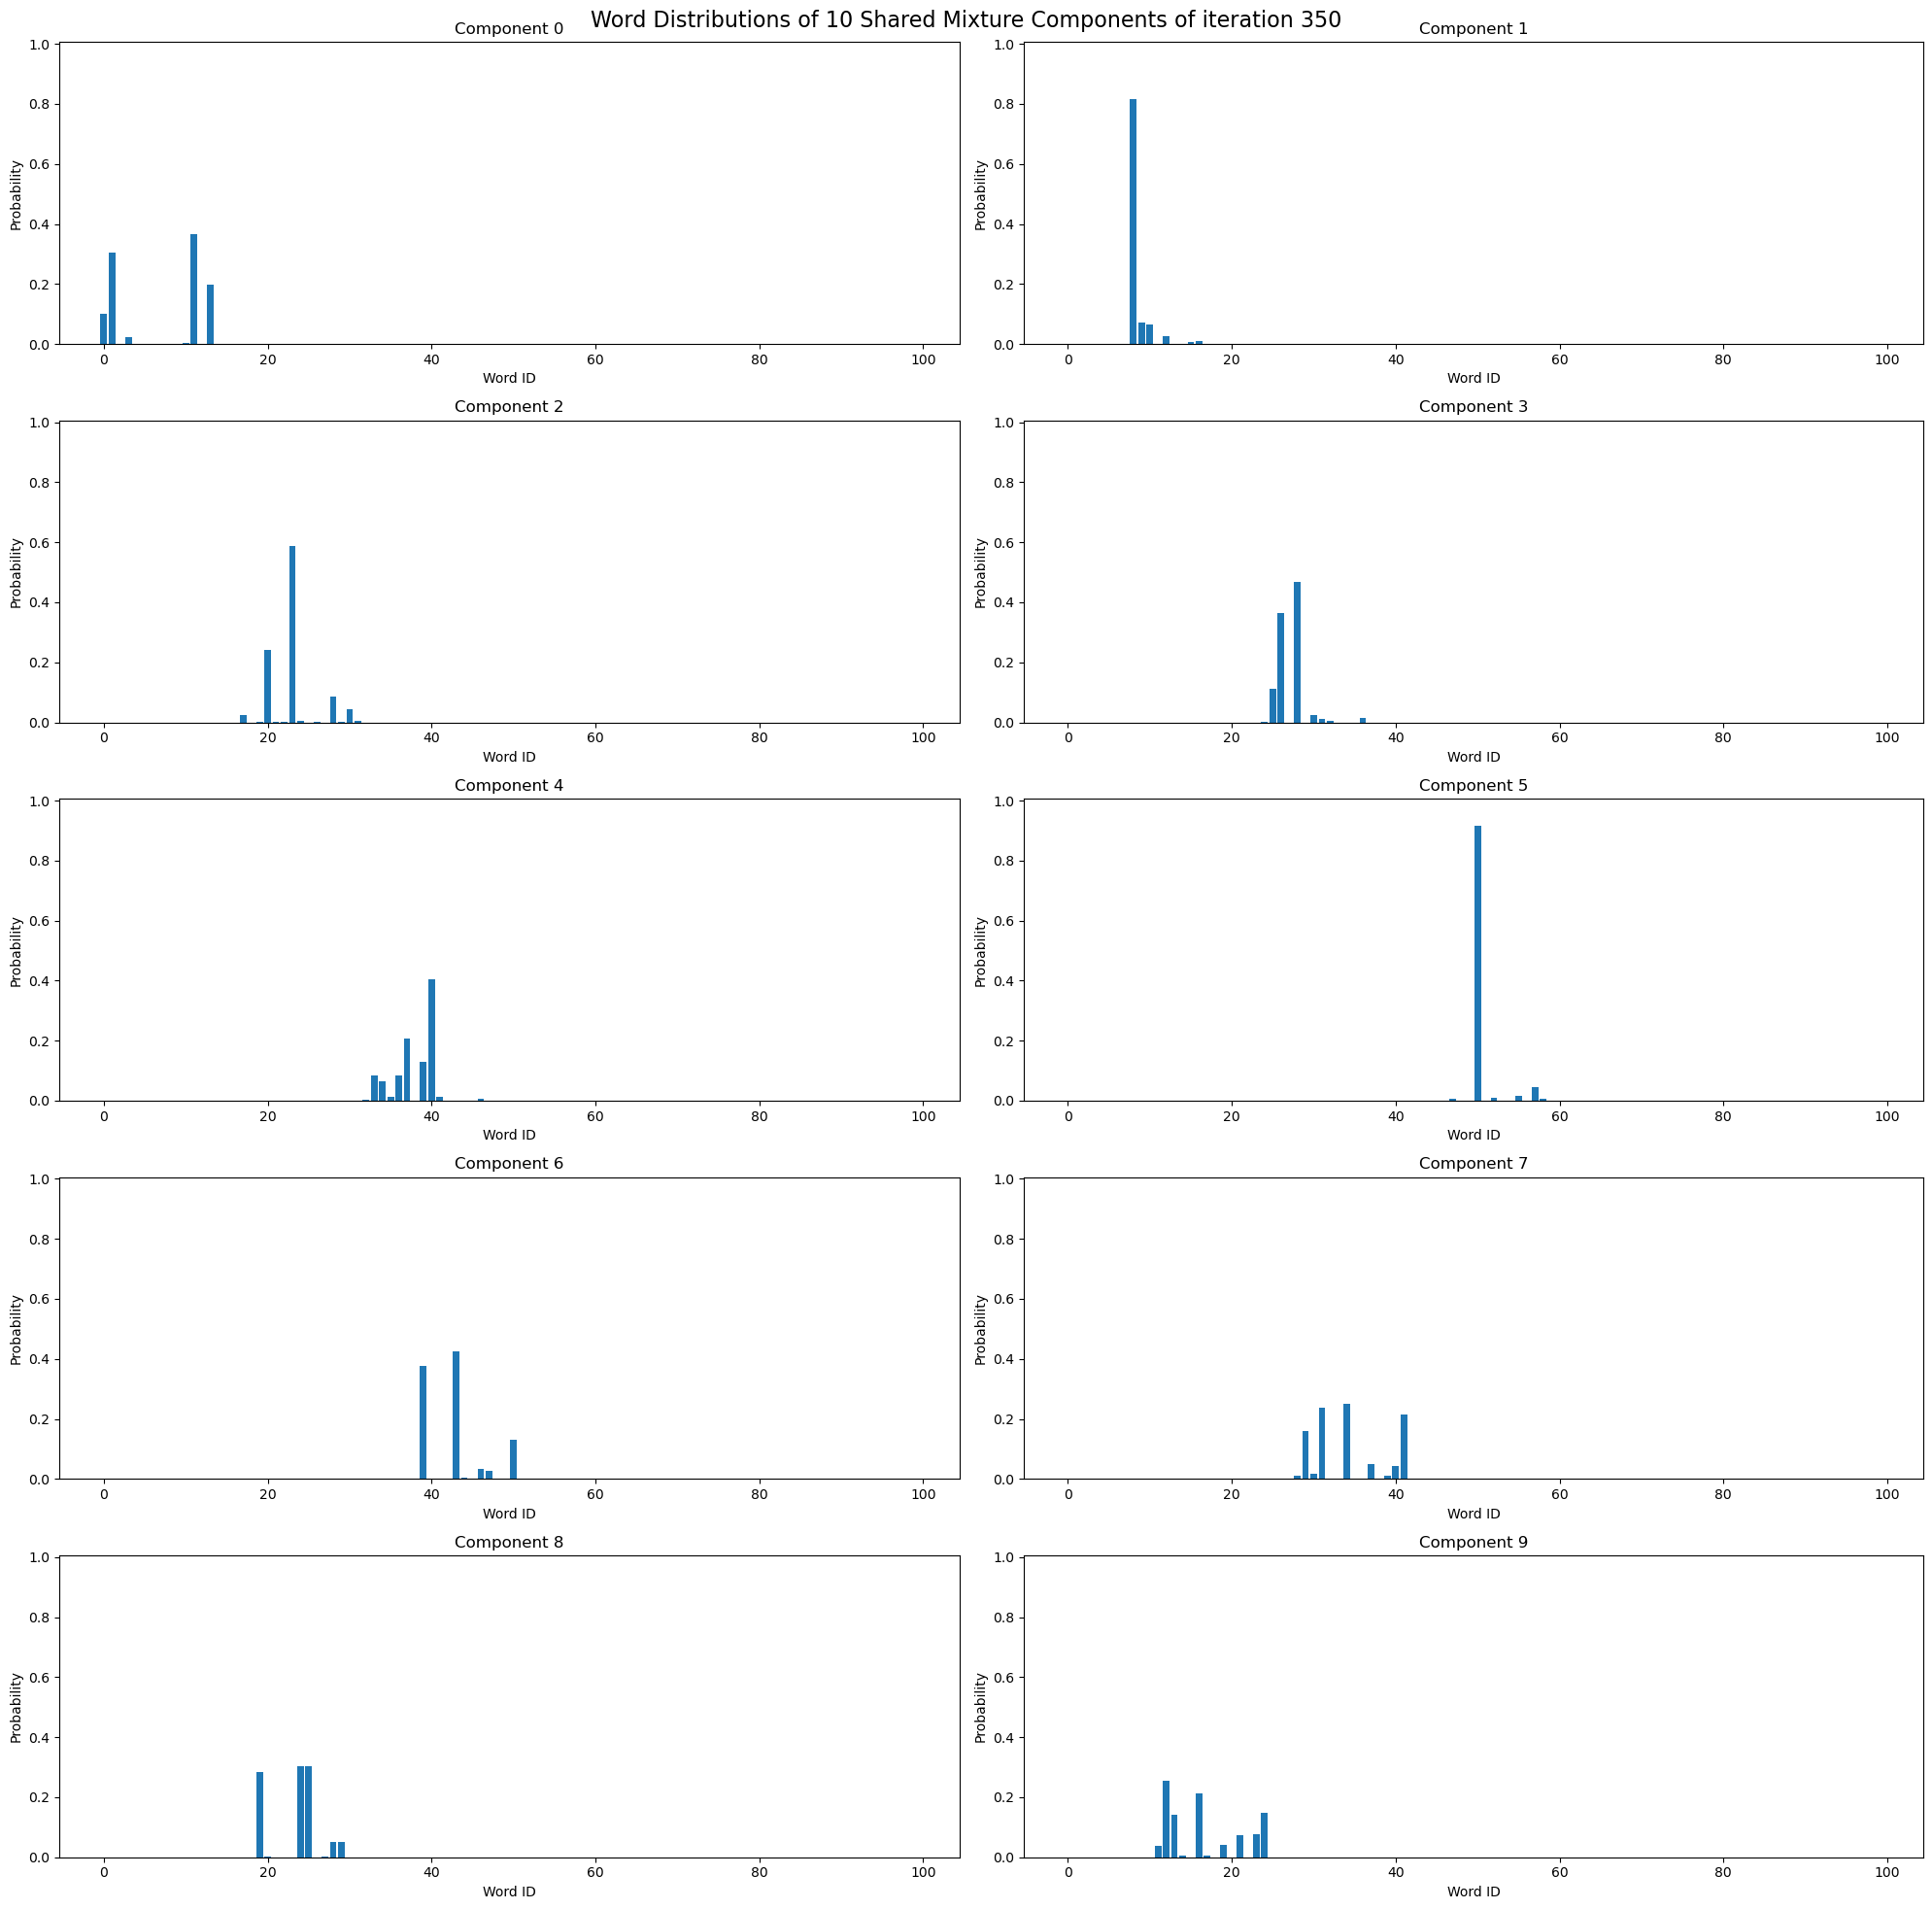

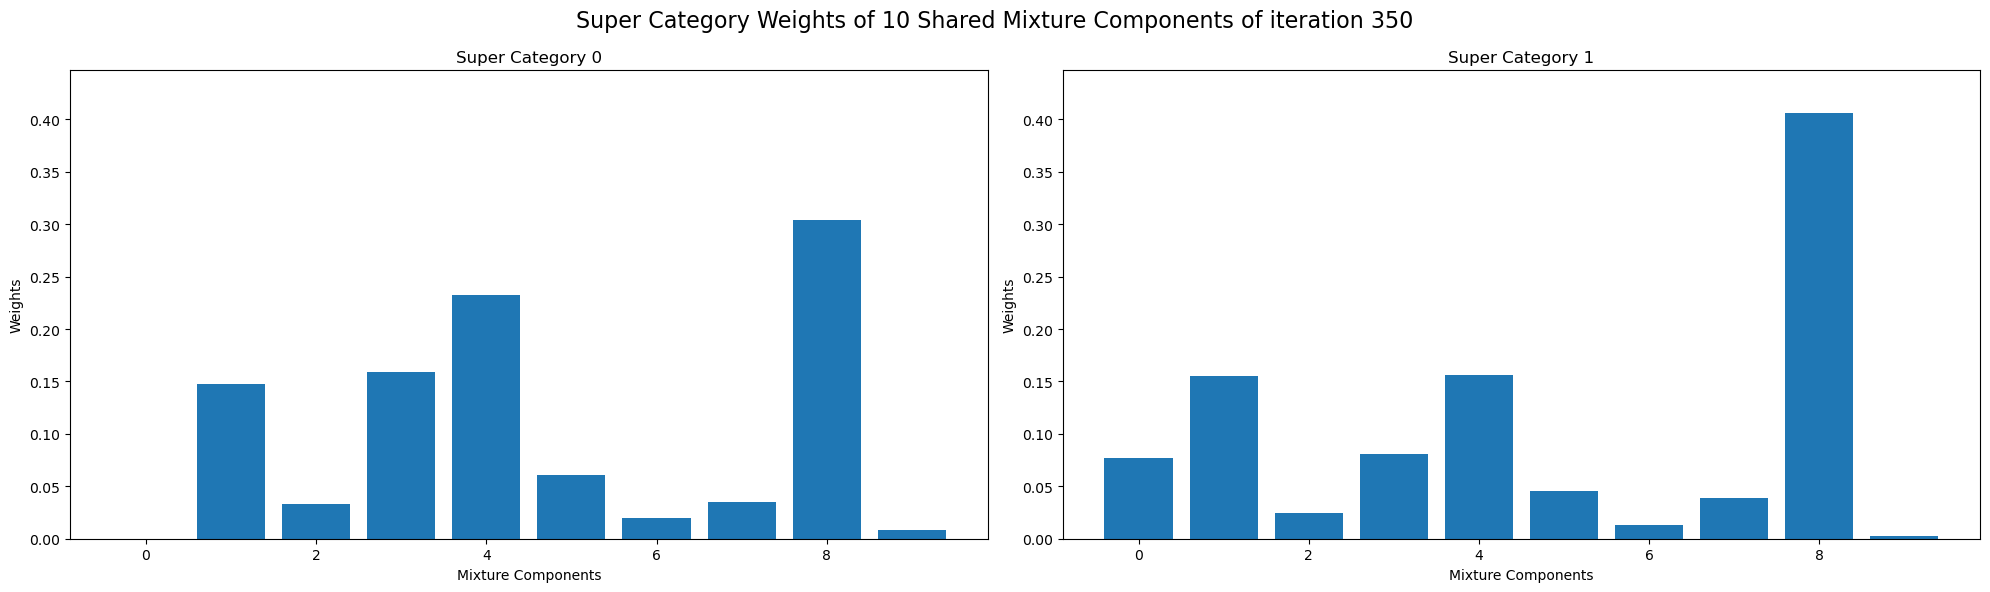

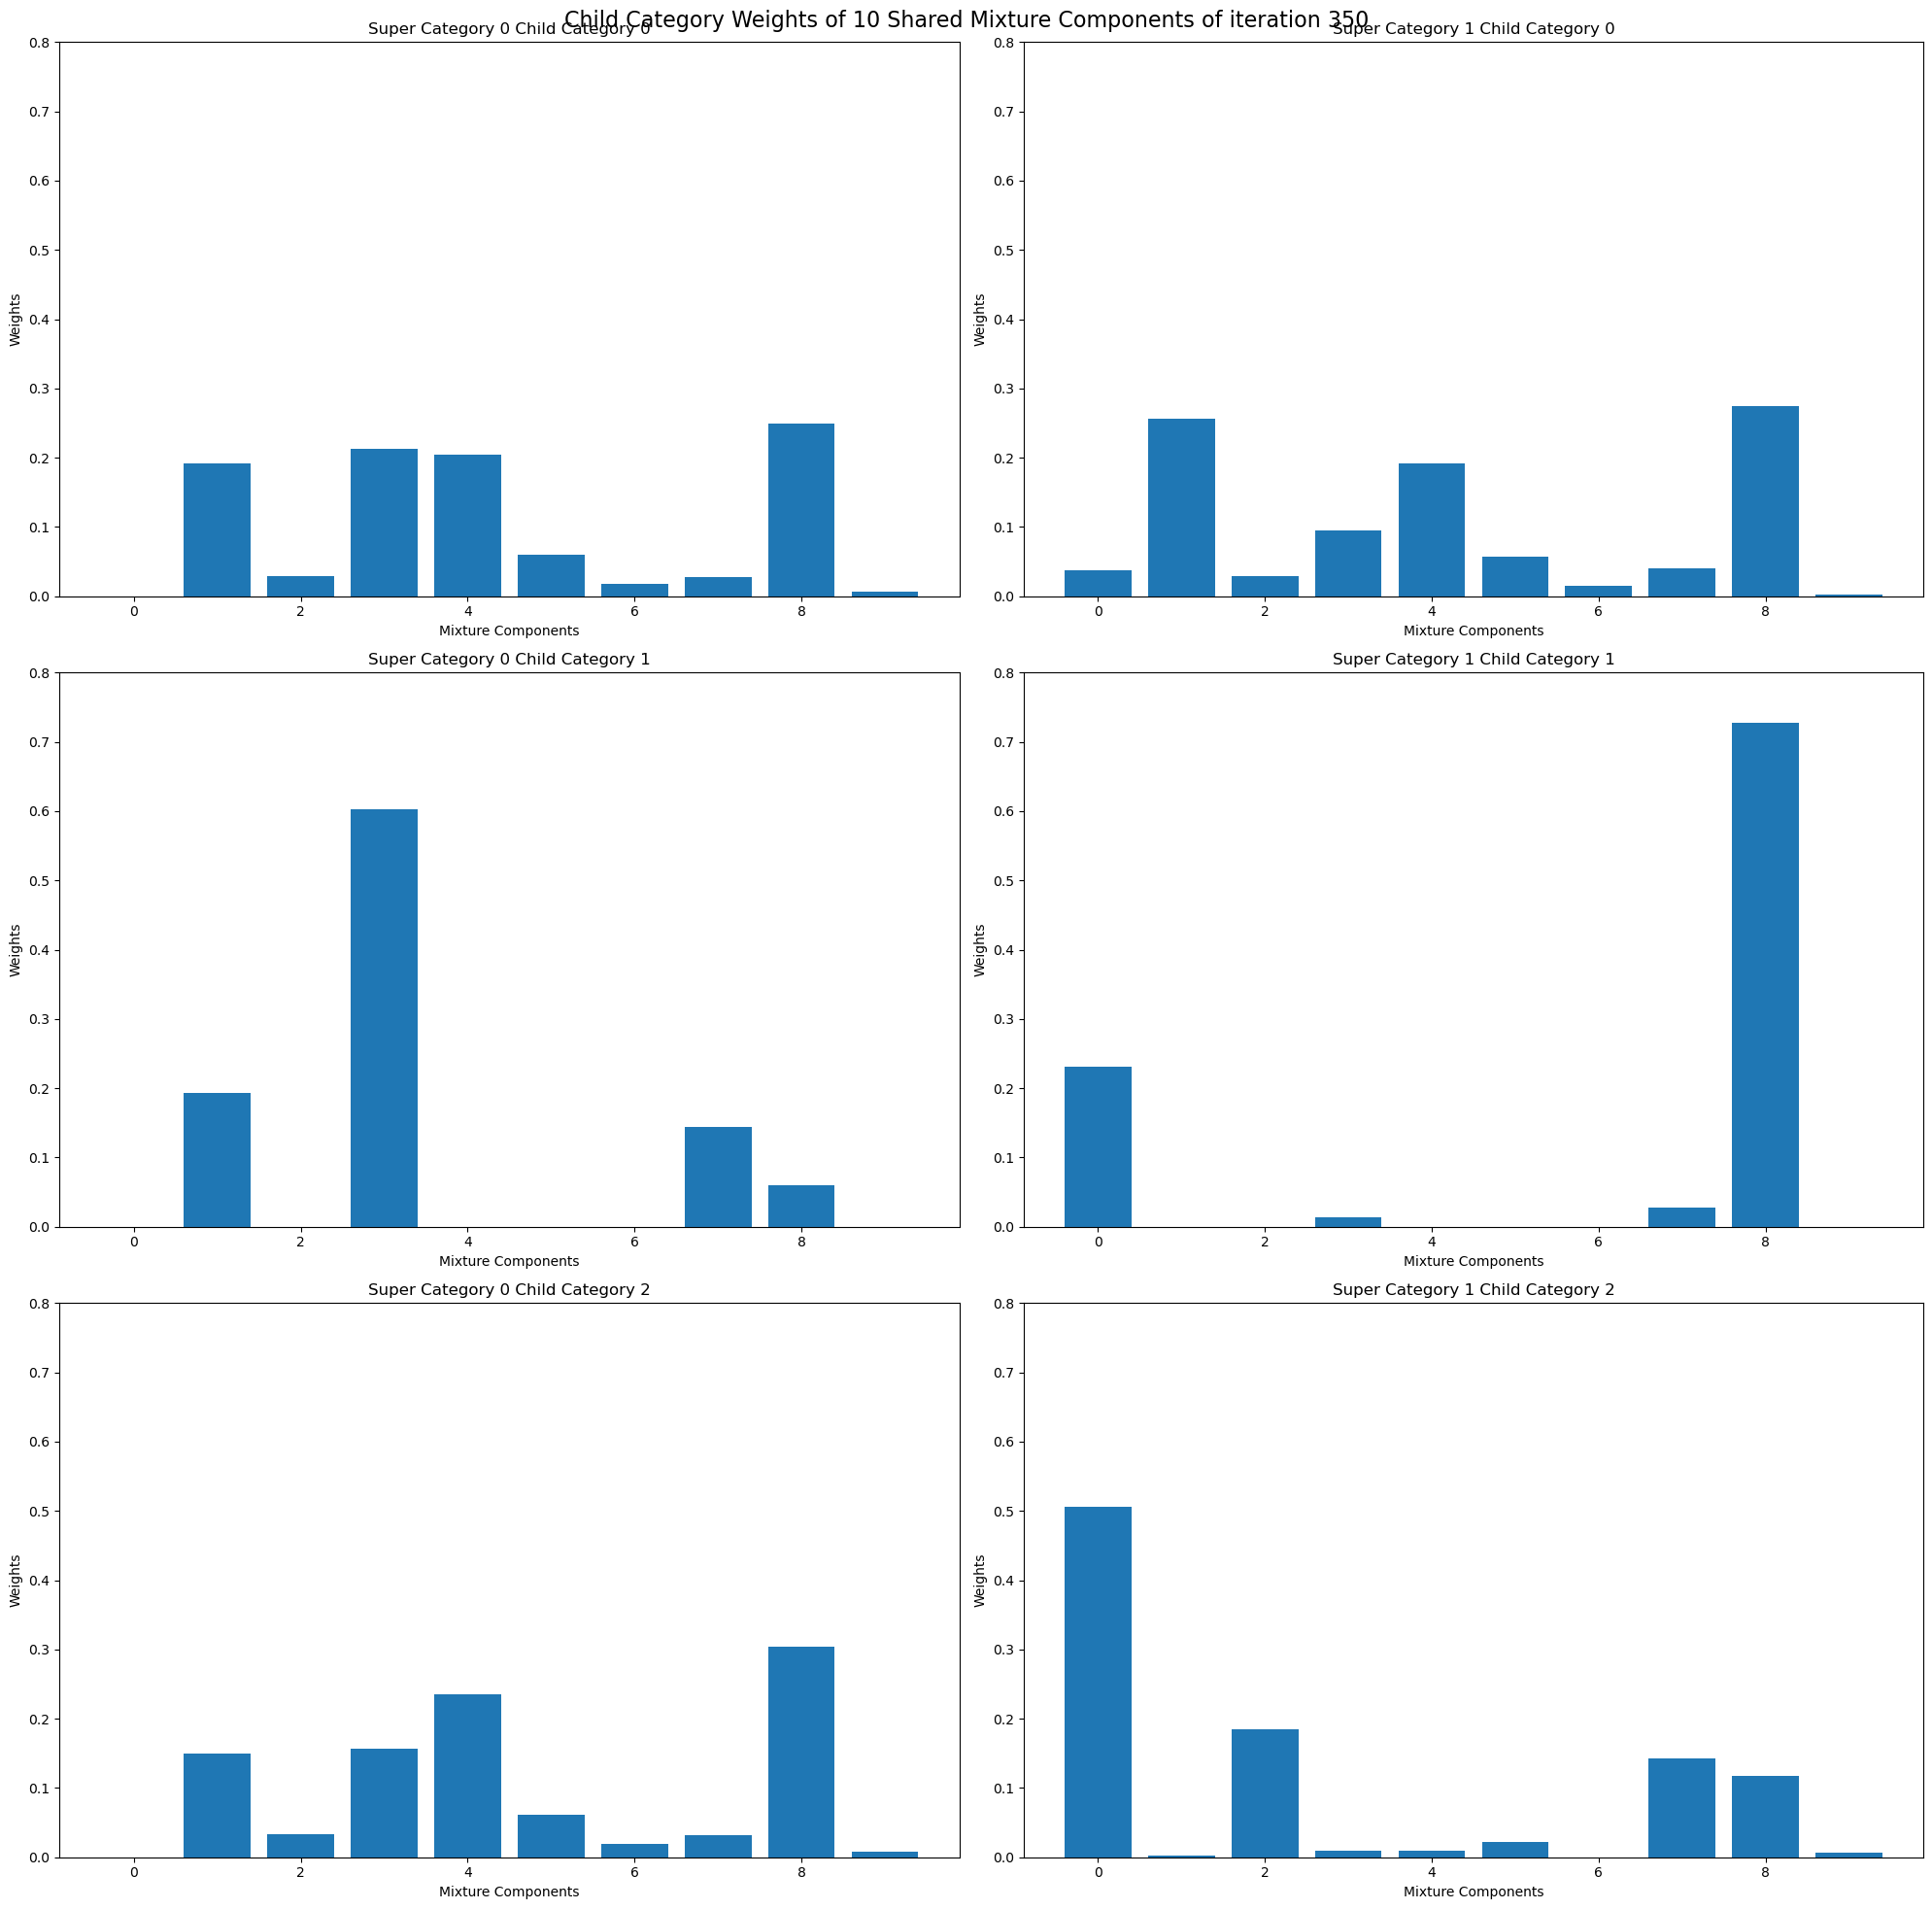

Gibbs Sampling:  80%|████████  | 400/500 [6:17:59<1:31:29, 54.90s/it]

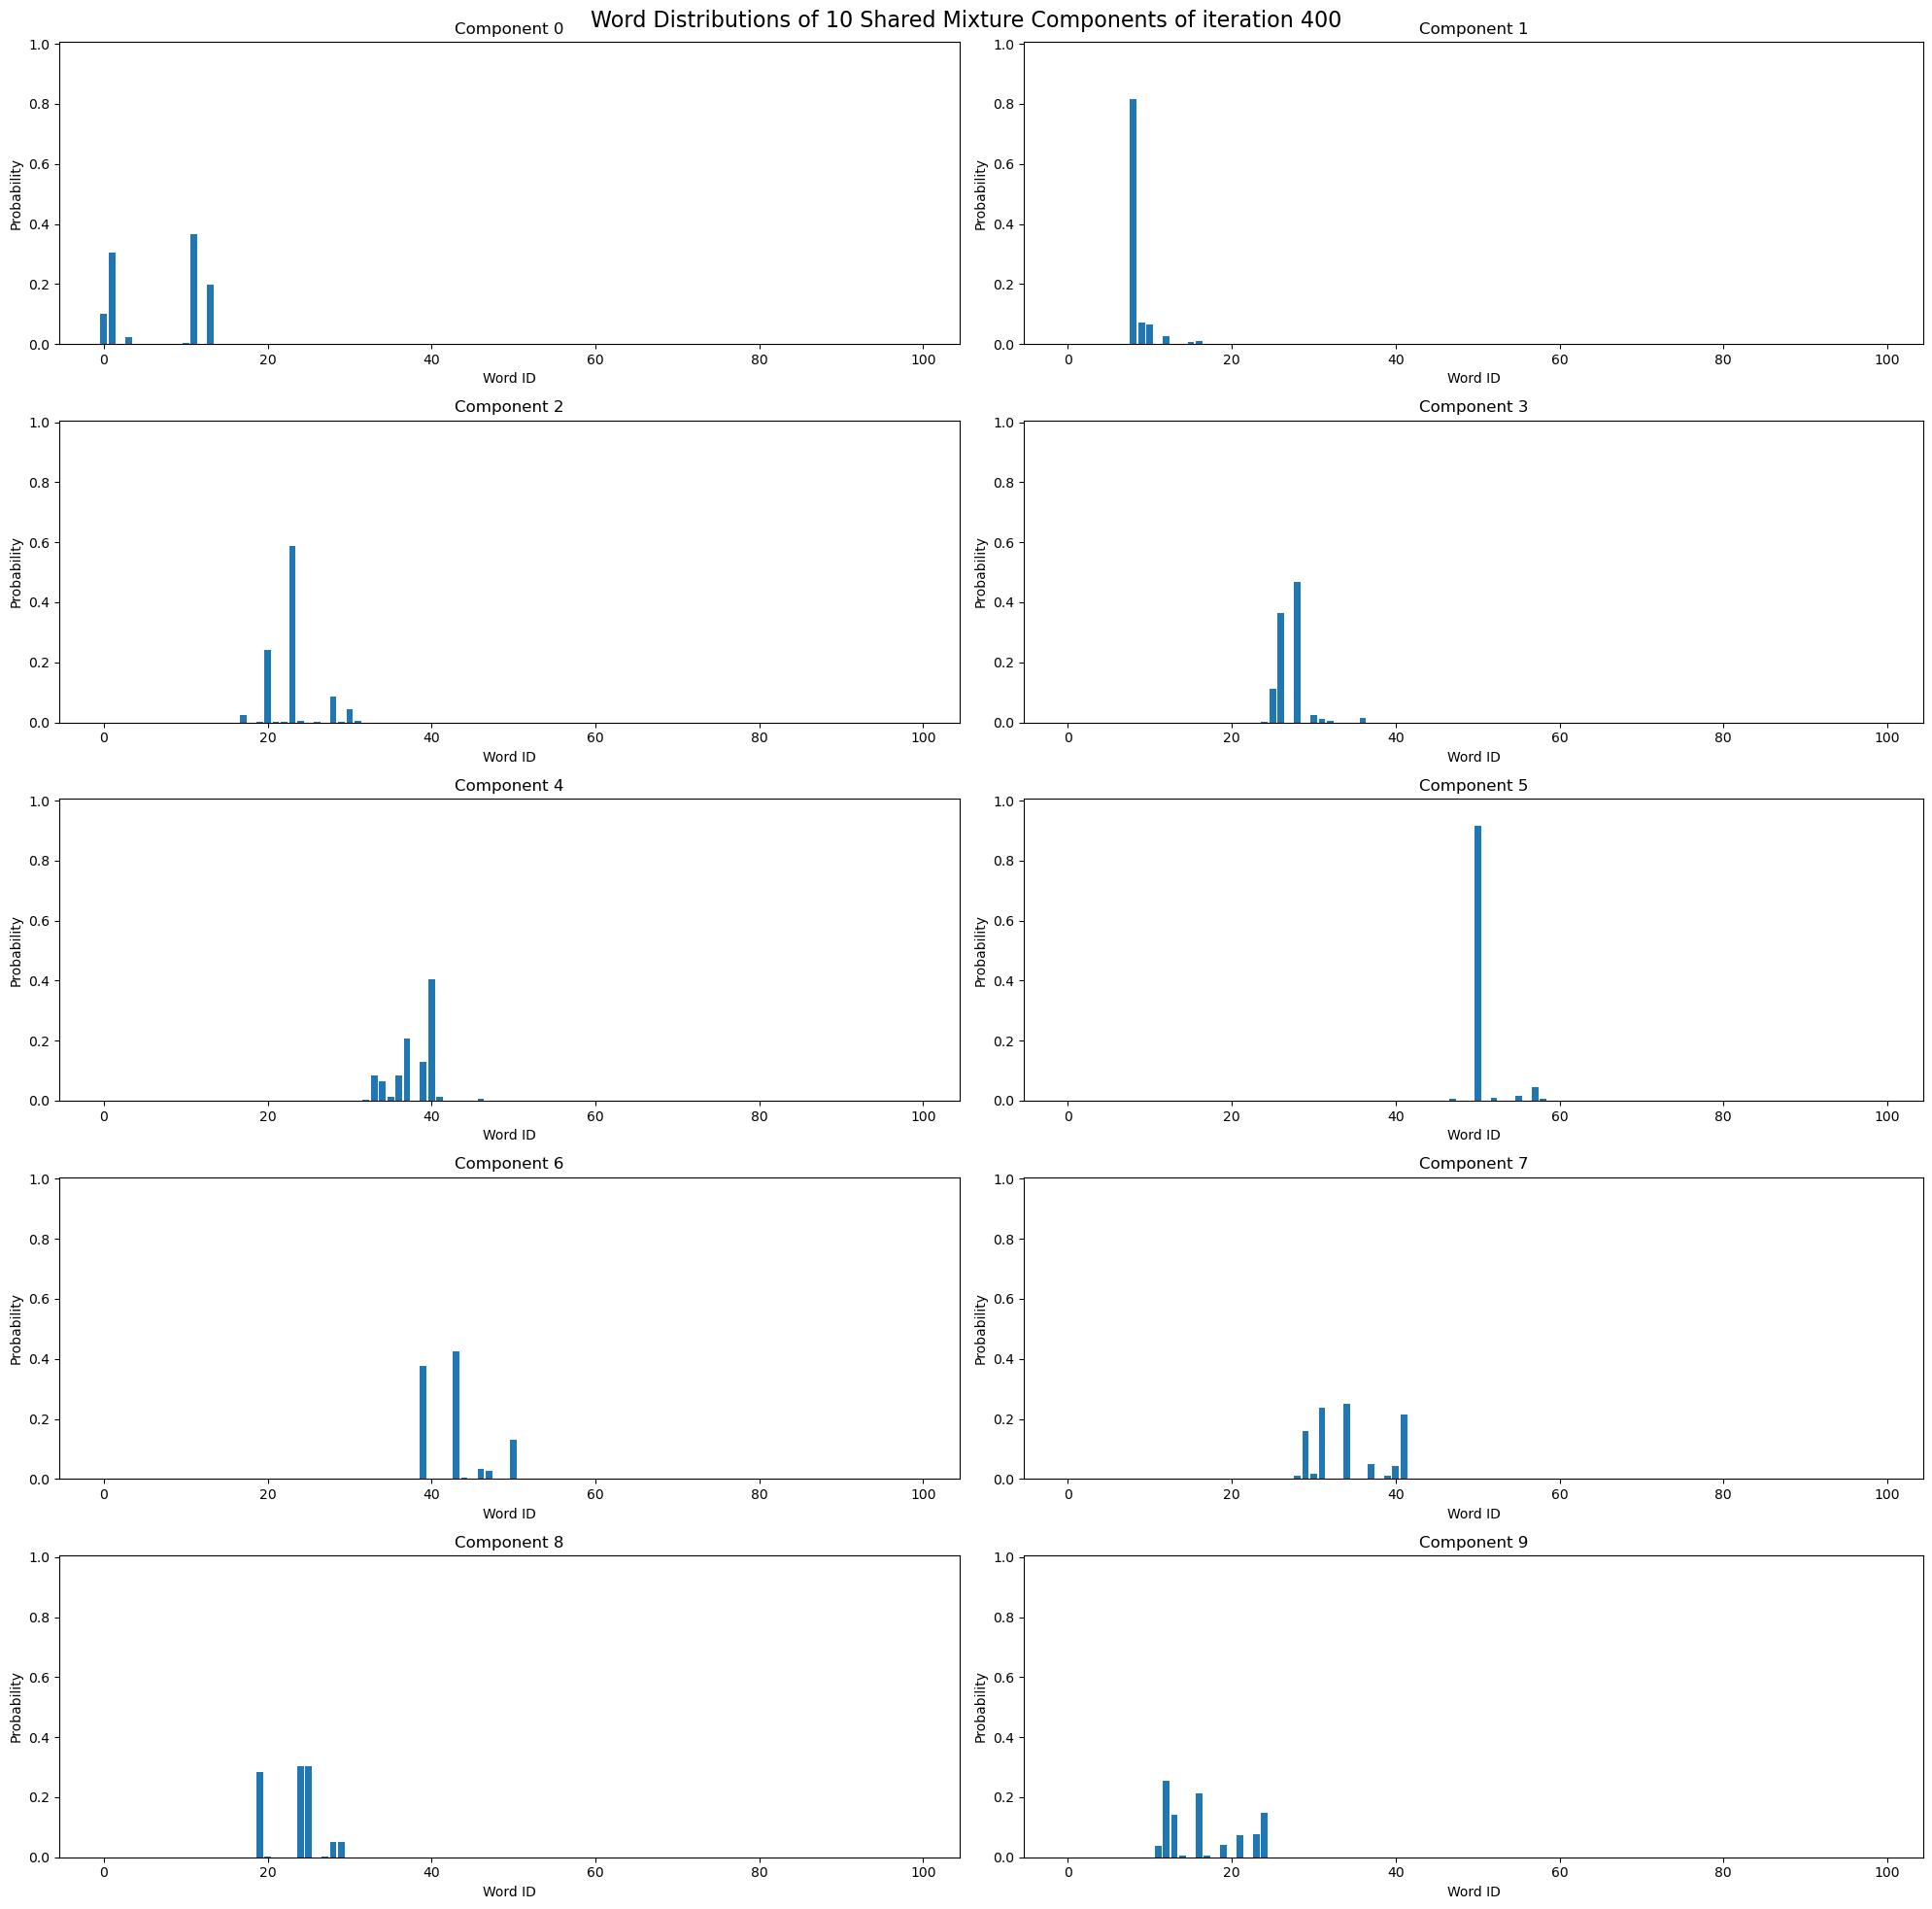

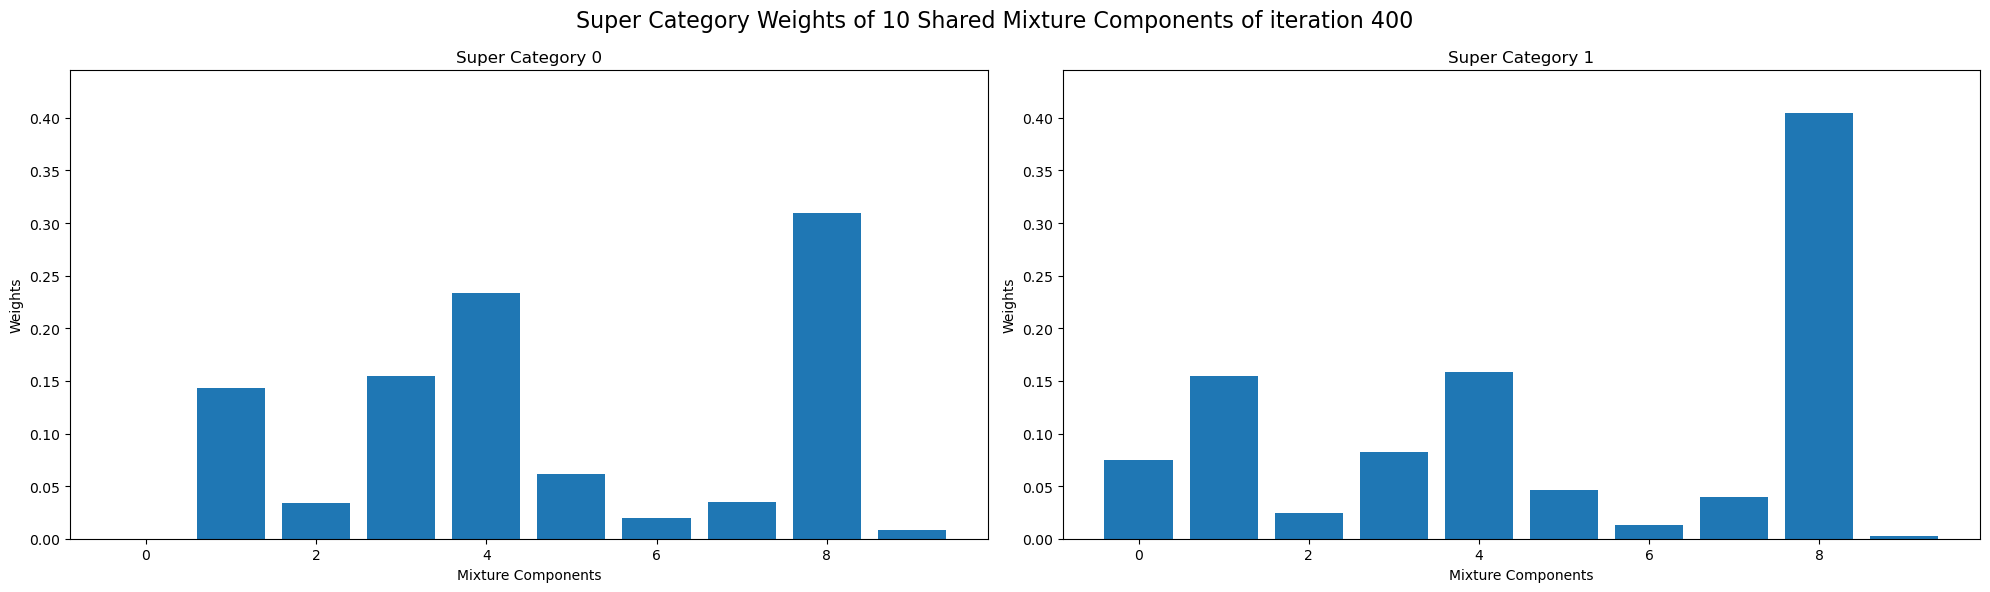

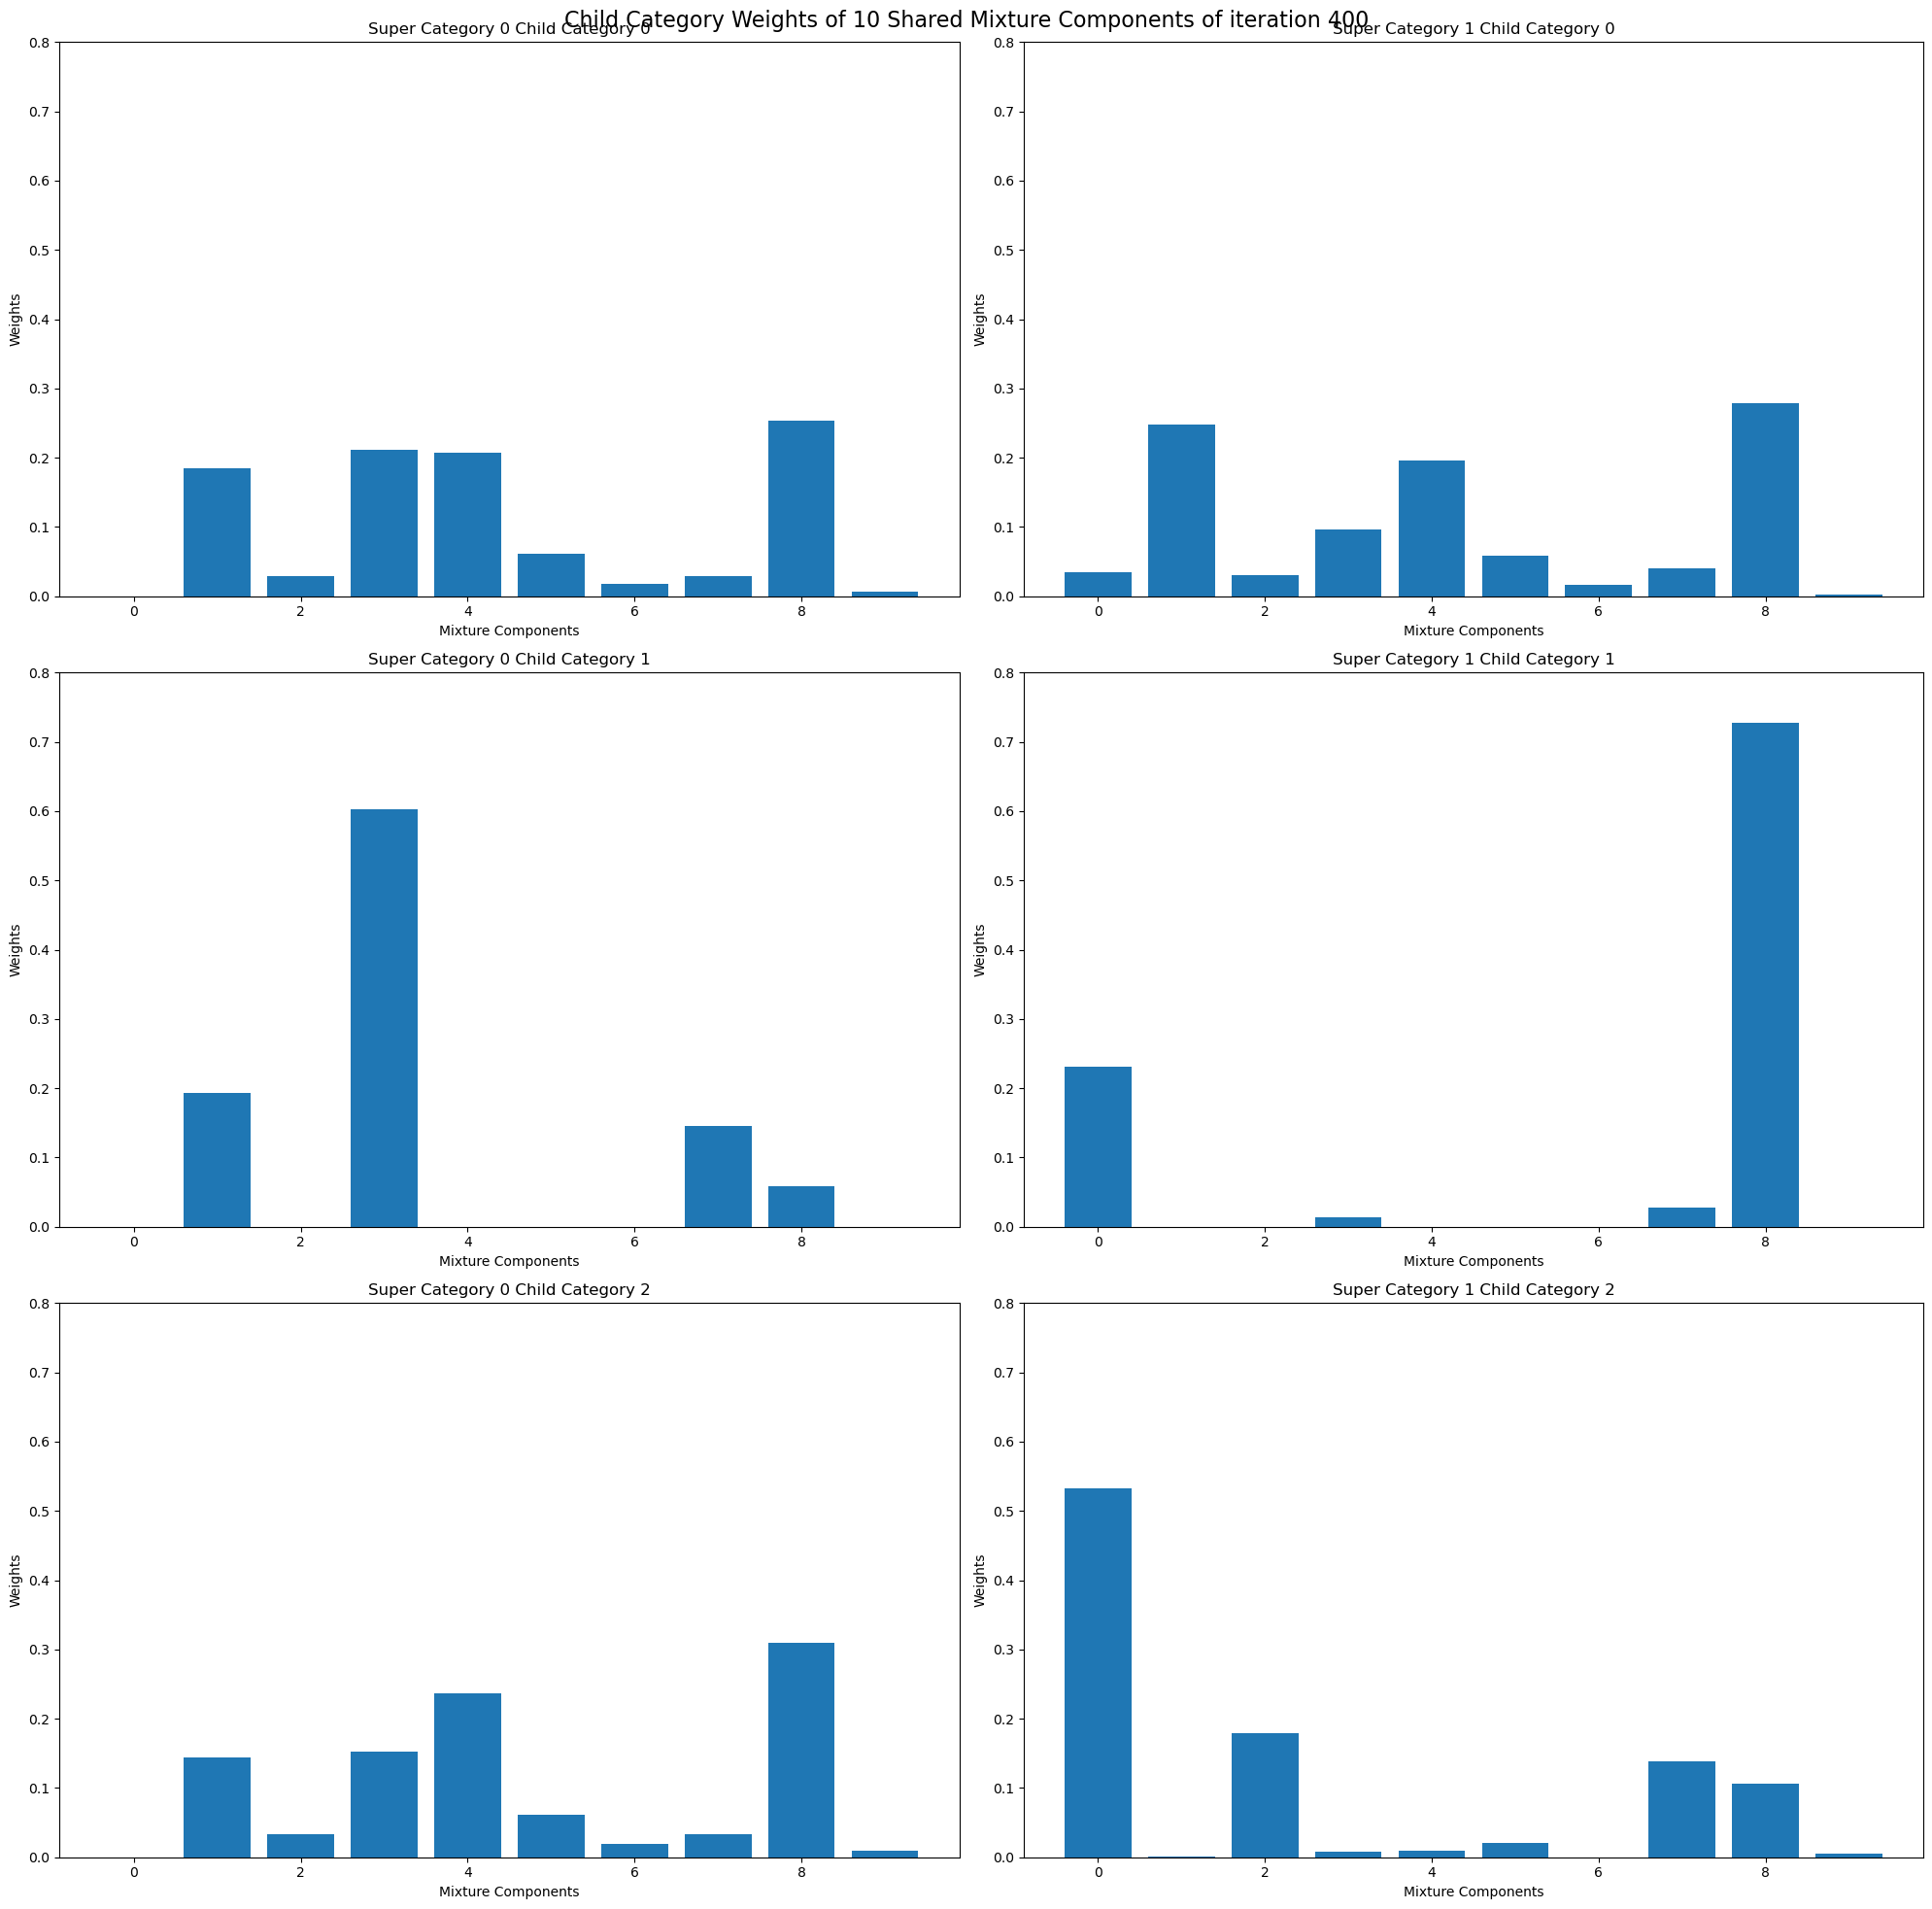

Gibbs Sampling:  90%|█████████ | 450/500 [6:58:26<39:18, 47.17s/it]  

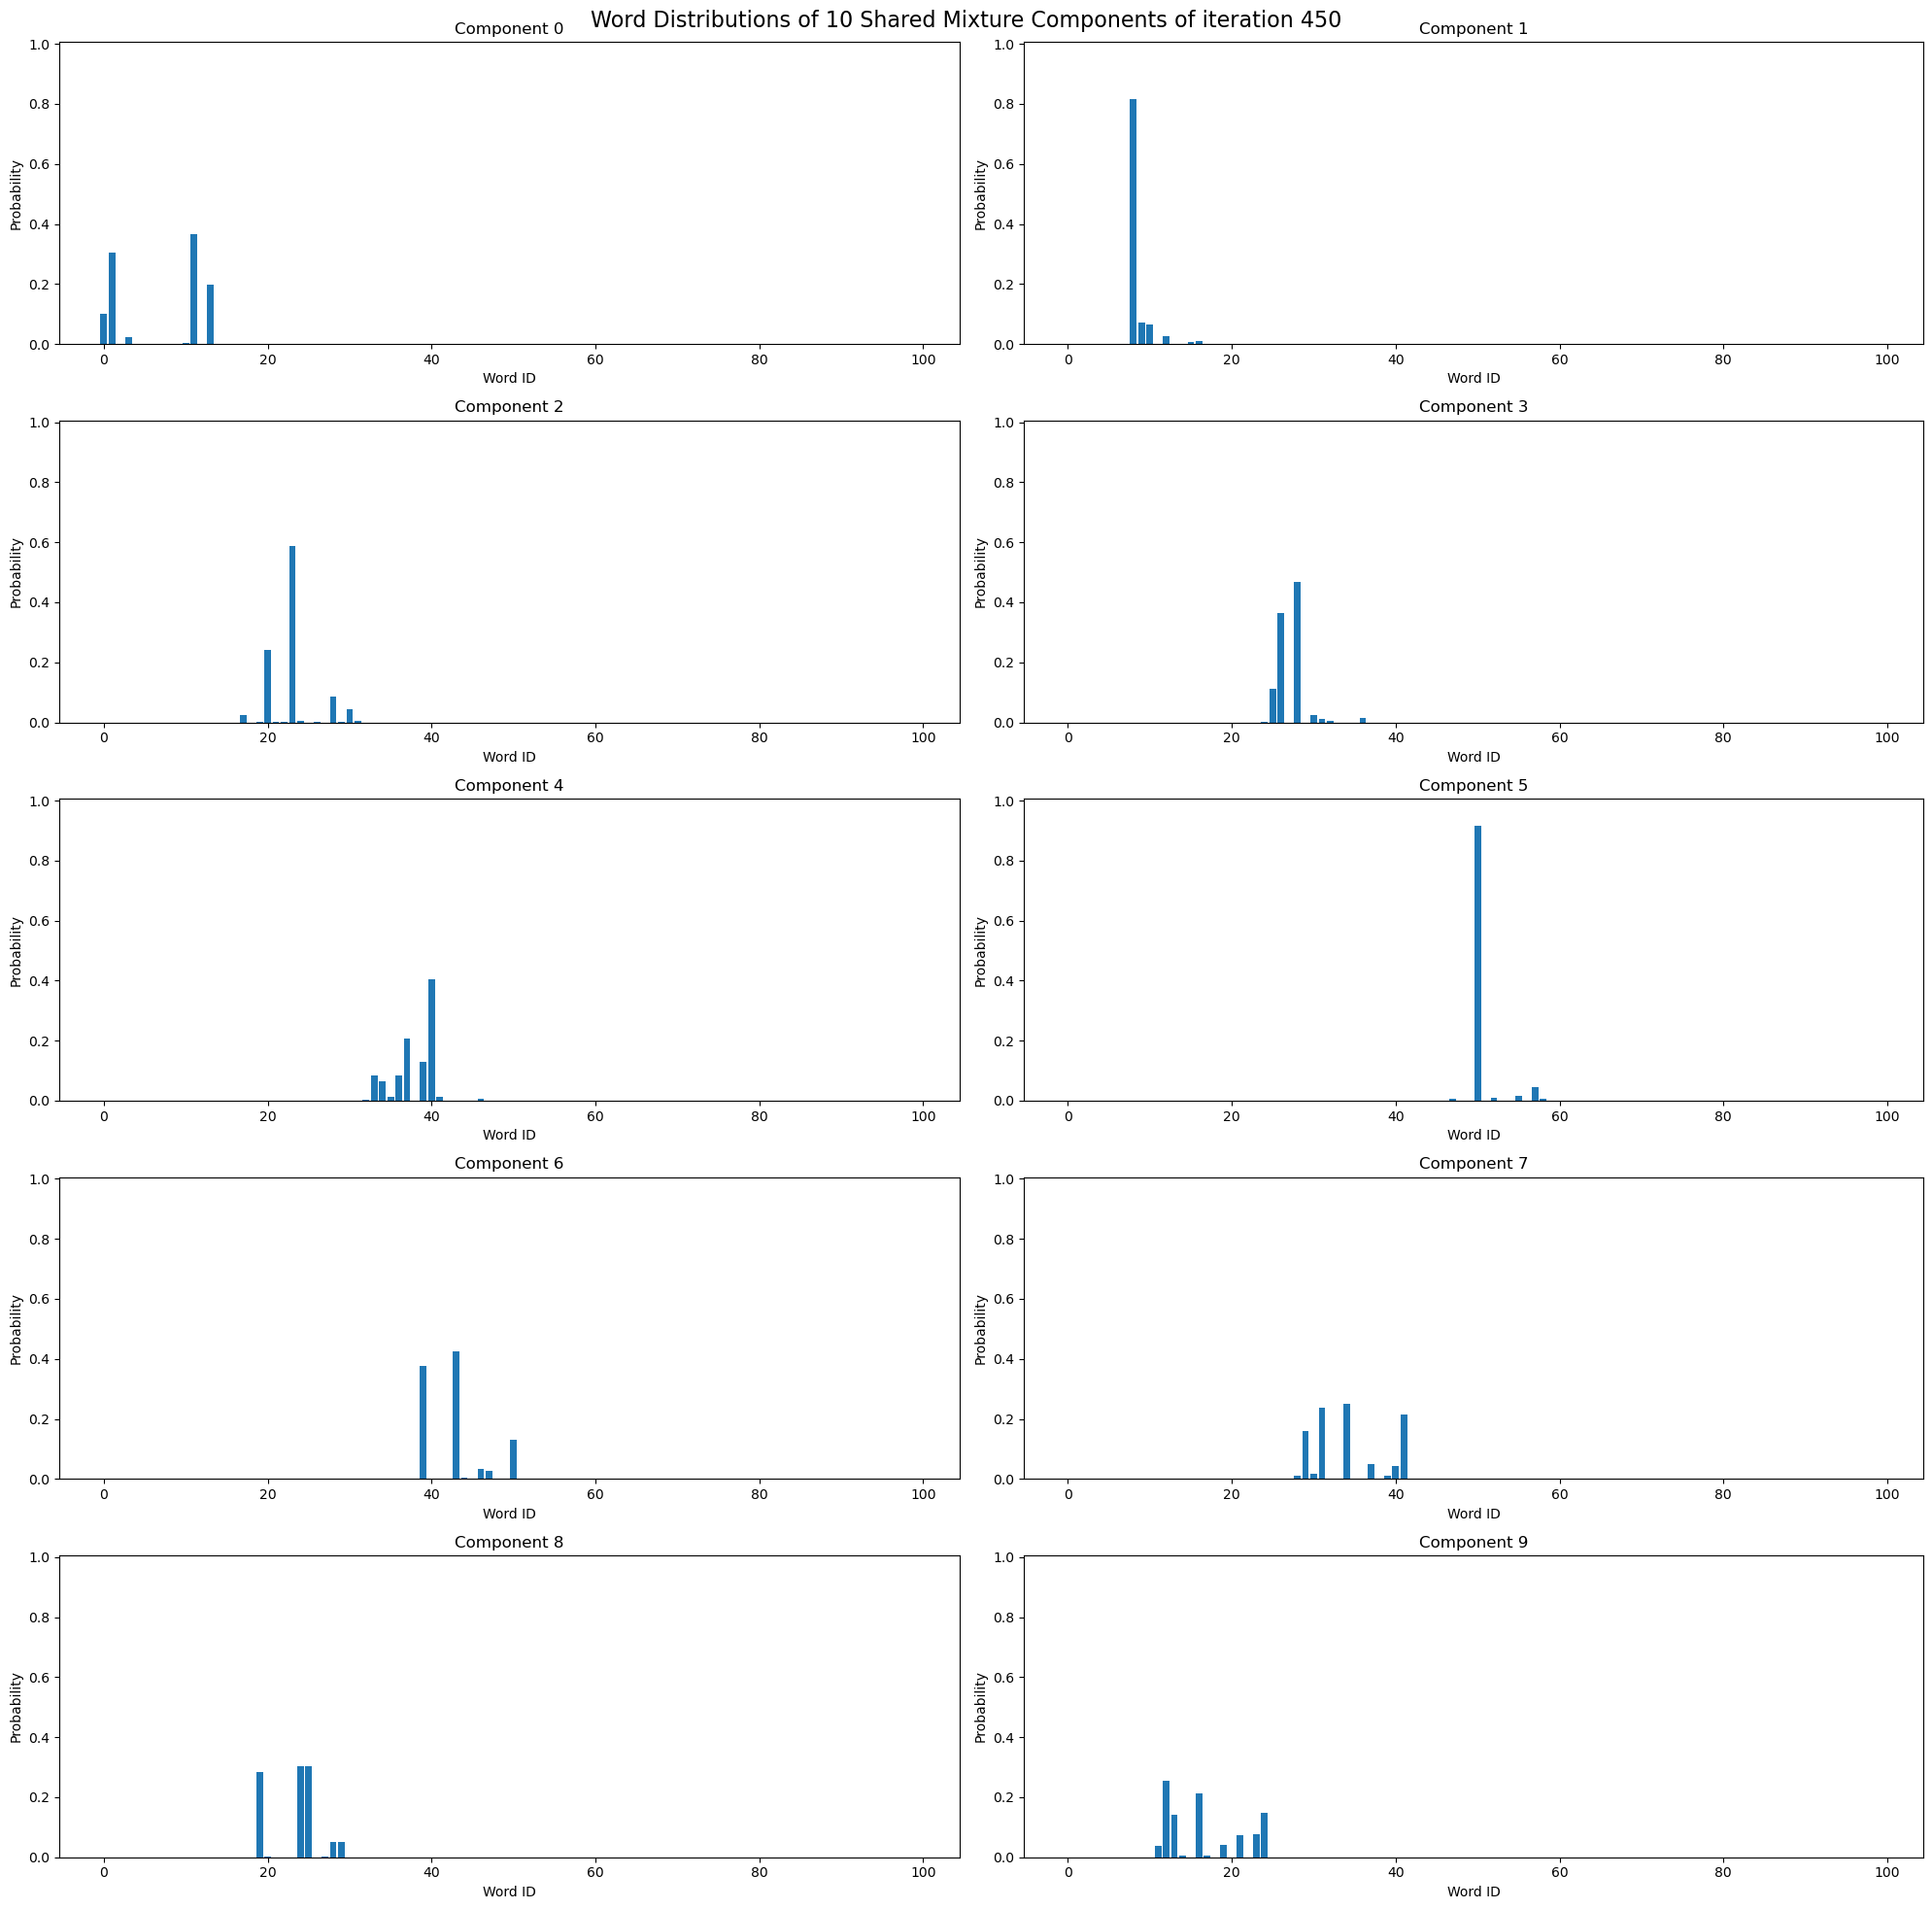

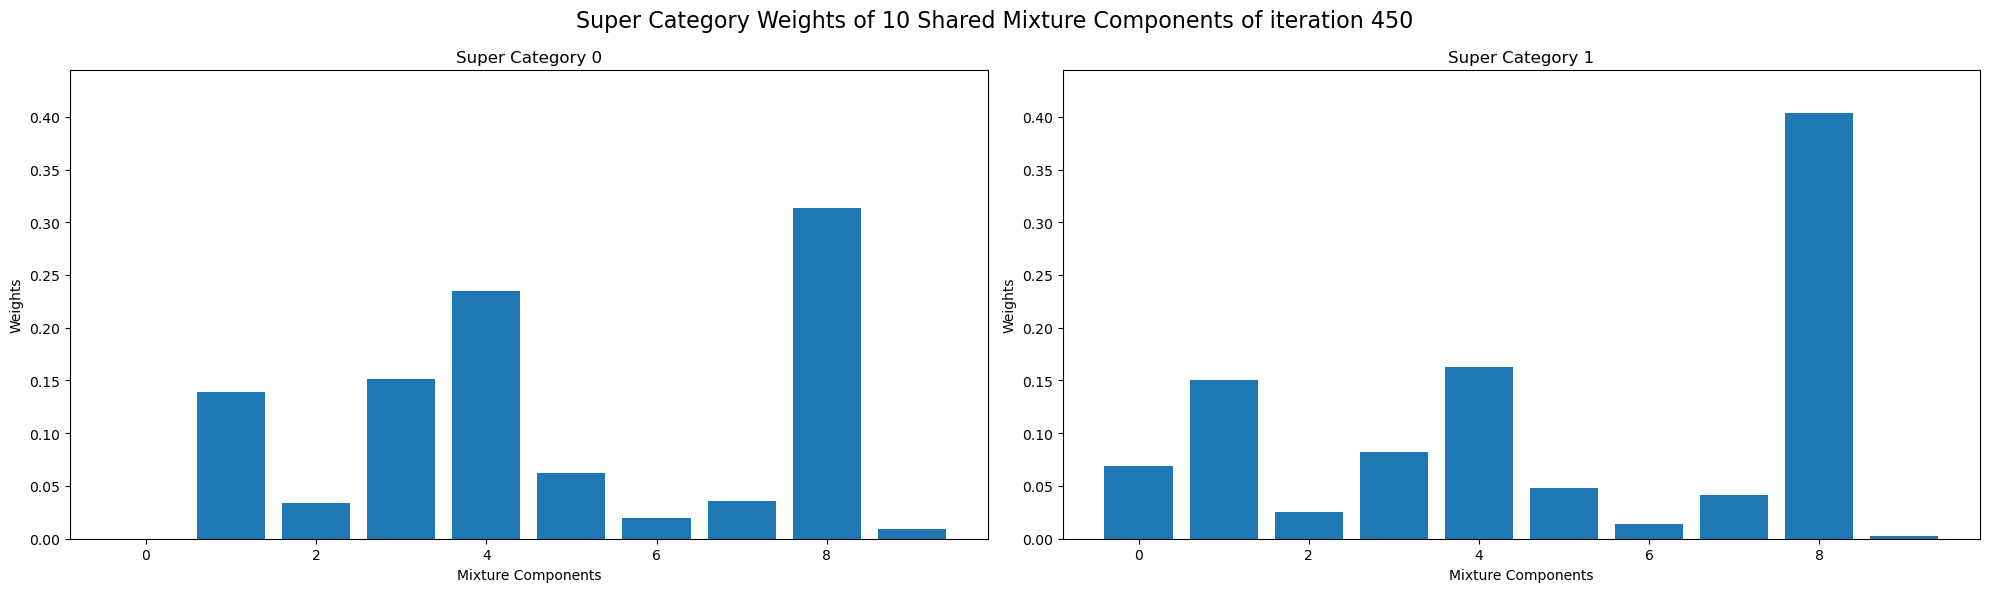

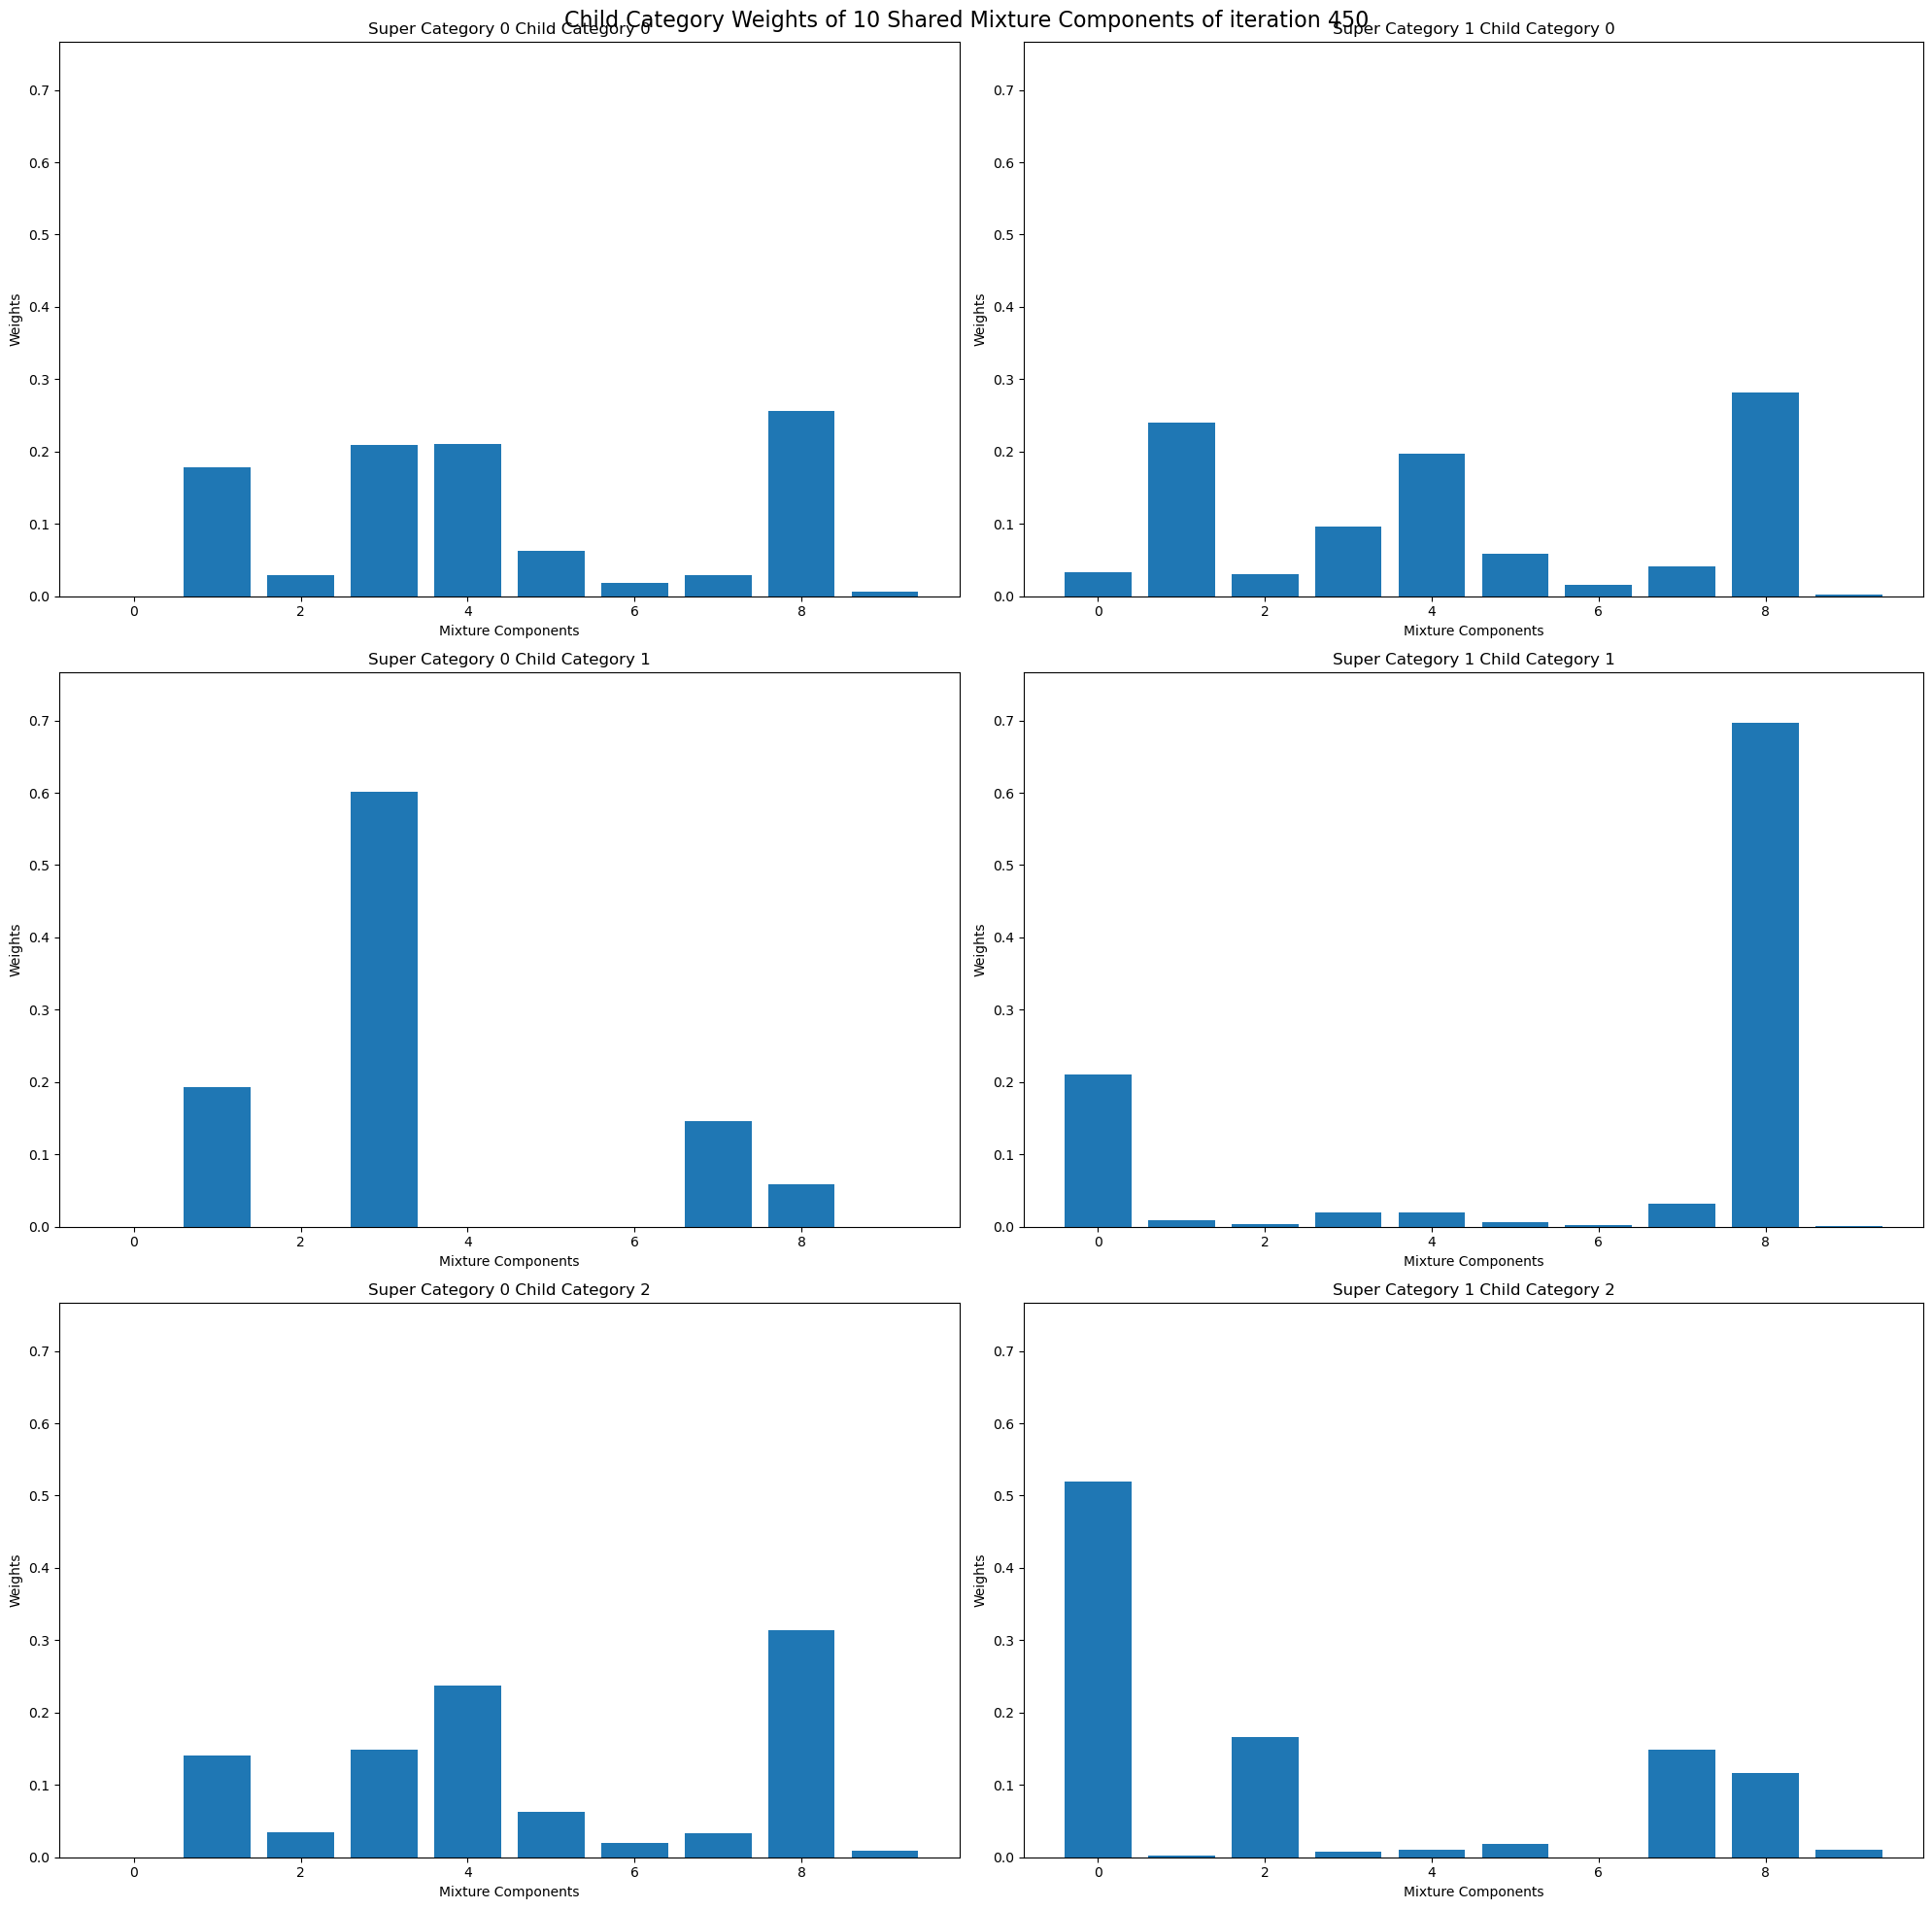

Gibbs Sampling: 100%|██████████| 500/500 [7:39:36<00:00, 55.15s/it]


In [ ]:
dataset = (data["x"], data["y"])
vocab_size = data["x"].shape[-1]
hdmm = model(dataset, struct_upbd=struct_upbd, vocab_size=vocab_size, seed=60, gen_mixture=data["word_dists"], device="cpu")
model_return = gibbs_sampler(jax.random.PRNGKey(0), hdmm, struct_upbd, vocab_size, num_iters=500, gen_ground_truth=True)